# 03 — Clustering

**Method:** K-Means + PCA visualisation on Tehran real estate listings

---

## Overview

This notebook is split into two sub-stages:

| Sub-stage | Source notebook | What it does |
|---|---|---|
| 3a — Clustering pre-processing | `2-CLUSTERING/1- CLEANING.ipynb` | Feature selection, scaling, encoding — 84-cell pipeline feeding into K-Means |
| 3b — K-Means clustering | `2-CLUSTERING/2- CLUSTERING.ipynb` | Elbow method, Silhouette analysis, K-Means (k=3 best), PCA 2D/3D visualisation |

### Input
`../data/divar_tehran_nonnum_filled_final.pkl`

### Key Results
- Three meaningful clusters identified, broadly corresponding to:
  - **Cluster 0:** Affordable / small apartments (studio–2BR, south/central Tehran)
  - **Cluster 1:** Mid-range family apartments (3BR, mid-range districts)
  - **Cluster 2:** Premium / luxury properties (large area, northern Tehran)
- PCA explains ~68% of variance in 2 components.

---


## Sub-stage 3a — Clustering Pre-processing

---
▶️ **وارد کردن ابزارها**
---

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import io




In [6]:
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler

In [7]:
import warnings
warnings.filterwarnings("ignore")

<hr style="border: 2px solid #FF9800; border-radius: 2px;">


▶️ **بارگذاری دیتاست**
---

In [13]:
df_path = "D:/pydsai/DivarProject/real_estate_ads.csv"
df= pd.read_csv(df_path)


<hr style="border: 2px solid #FF9800; border-radius: 2px;">

▶️ **کنکاش در دیتاست**
---

In [13]:
df.shape

(1000000, 60)

In [5]:
df.head()

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 60 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   cat2_slug                   1000000 non-null  object 
 1   cat3_slug                   999999 non-null   object 
 2   city_slug                   999998 non-null   object 
 3   neighborhood_slug           437139 non-null   object 
 4   created_at_month            1000000 non-null  object 
 5   user_type                   288882 non-null   object 
 6   description                 1000000 non-null  object 
 7   title                       999946 non-null   object 
 8   rent_mode                   352994 non-null   object 
 9   rent_value                  351322 non-null   float64
 10  rent_to_single              19 non-null       object 
 11  rent_type                   103961 non-null   object 
 12  price_mode                  573606 non-null   object 
 13

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rent_value,351322.0,4.102299e+10,3.807534e+12,0.000000,1.111110e+05,5.000000e+06,1.200000e+07,1.000000e+15
price_value,568346.0,1.736537e+10,5.878739e+11,0.000000,1.400000e+09,2.840000e+09,5.900000e+09,1.000000e+14
credit_value,352095.0,4.872084e+10,4.341346e+12,0.000000,1.000000e+08,2.500000e+08,5.000000e+08,1.000000e+15
transformable_credit,352085.0,4.872222e+10,4.341407e+12,0.000000,1.000000e+08,2.500000e+08,5.000000e+08,1.000000e+15
transformed_credit,72409.0,8.557025e+09,2.064576e+12,0.000000,2.000000e+08,4.000000e+08,8.500000e+08,5.555556e+14
transformable_rent,351248.0,4.103164e+10,3.807935e+12,0.000000,1.111110e+05,5.000000e+06,1.200000e+07,1.000000e+15
transformed_rent,72409.0,1.619934e+07,5.217890e+07,0.000000,1.000000e+06,6.000000e+06,1.500000e+07,3.000000e+09
land_size,186396.0,4.165480e+03,1.218927e+05,1.000000,1.100000e+02,1.950000e+02,2.800000e+02,1.000000e+07
building_size,980394.0,4.440648e+03,1.367118e+05,1.000000,7.500000e+01,1.030000e+02,1.650000e+02,1.000000e+07
regular_person_capacity,29870.0,6.557650e+00,7.698655e+00,1.000000,3.000000e+00,4.000000e+00,7.000000e+00,5.000000e+01


In [22]:
df.describe(include='object').T

,count,unique,top,freq
cat2_slug,1000000,6,residential-sell,558708
cat3_slug,999999,16,apartment-sell,303385
city_slug,999998,421,tehran,190904
neighborhood_slug,437139,1188,elahiyehblvd,7076
created_at_month,1000000,46,2024-07-01 00:00:00,133219
user_type,288882,2,مشاور املاک,256006
description,1000000,989449,❌فروش ویلا و زمین زیرقیمت منطقه و بدون واسطه ب...,220
title,999946,904092,خانه ویلایی,1867
rent_mode,352994,3,مقطوع,292081
rent_to_single,19,2,True,18


In [21]:
df.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type', 'price_mode',
       'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform',
       'transformable_price', 'transformable_credit', 'transformed_credit',
       'transformable_rent', 'transformed_rent', 'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person

In [5]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Unique value in column '{column}':")
    print(unique_values)
    print('-' * 40)

Unique value in column 'cat2_slug':
['temporary-rent' 'residential-sell' 'residential-rent' 'commercial-rent'
 'commercial-sell' 'real-estate-services']
----------------------------------------
Unique value in column 'cat3_slug':
['villa' 'apartment-sell' 'apartment-rent' 'office-rent' 'shop-sell'
 'plot-old' 'house-villa-sell' 'house-villa-rent' 'shop-rent'
 'industry-agriculture-business-rent' 'office-sell'
 'industry-agriculture-business-sell' 'presell' 'suite-apartment'
 'partnership' 'workspace' nan]
----------------------------------------
Unique value in column 'city_slug':
['karaj' 'tehran' 'mashhad' 'ahvaz' 'kermanshah' 'mahdasht-city'
 'pardis-city' 'foolad-shahr' 'rasht' 'mahabad' 'shiraz' 'gonabad' 'azna'
 'andisheh-new-town' 'chamestan' 'babol' 'arak' 'pishva' 'tabriz' 'urmia'
 'nur' 'kish' 'nasimshahr' 'amol' 'yasuj' 'isfahan' 'ilam' 'najafabad'
 'yazd' 'pakdasht-city' 'bandar-ganaveh' 'chalus' 'sabzevar' 'eslamshahr'
 'dezful' 'mohammadieh' 'lavasan-city' 'sirjan' 'Kordk

<hr style="border: 2px solid #FF9800; border-radius: 2px;">


▶️ **مشاهده درصد مقادیر غیرتهی**
---

In [7]:
total_rows=len(df)

null_count = df.isnull().sum().sort_values(ascending=True)
null_df = null_count.to_frame('Null Count')                   #convert series to data frame

null_df['Filled Count'] = total_rows - null_df['Null Count']


#percent of filled features
null_df['% Filled'] = (null_df['Filled Count'] / total_rows * 100).round(2)

#styling and Use a comma as a thousand separator  
null_df = null_df.style.format({'Null Count' : '{:,}' , 'Filled Count' : '{:,}' , '% Filled' : '{:.2f}%'})

null_df

,Null Count,Filled Count,% Filled
cat2_slug,0,"1,000,000",100.00%
created_at_month,0,"1,000,000",100.00%
description,0,"1,000,000",100.00%
cat3_slug,1,"999,999",100.00%
city_slug,2,"999,998",100.00%
title,54,"999,946",99.99%
building_size,"19,606","980,394",98.04%
rooms_count,"154,101","845,899",84.59%
construction_year,"184,172","815,828",81.58%
has_parking,"271,844","728,156",72.82%


<hr style="border: 2px solid #FF9800; border-radius: 2px;">


▶️ **شروع: مدیریت داده‌های تکراری**
---

In [33]:
# شناسایی رکوردهای تکراری بر اساس ستون‌های منتخب ( نادیده گرفتن ستونهای متنی)
columns_to_ignore = ['title', 'description', 'created_at_month']
all_columns = df.columns.tolist()
columns_to_check = [col for col in all_columns if col not in columns_to_ignore]
#print(f"تعداد ستون‌های مورد بررسی برای تکرار: {len(columns_to_check)}")
duplicated_rows_mask = df.duplicated(subset=columns_to_check, keep=False)
num_duplicated_rows = duplicated_rows_mask.sum()
num_duplicated_rows
duplicated_df = df[duplicated_rows_mask]
display(duplicated_df.sort_values(by=['city_slug','building_size', 'price_value' ]).tail(10))


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
357367,residential-sell,plot-old,zibakenar,NaN,2024-08-01 00:00:00,مشاور املاک,متعلق به شرکت انبوه سازان ویلا آرمانی\nزمین 50...,زمین 500 متری بریک ساحل /مسکونی سنددار,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
702468,residential-sell,plot-old,zibakenar,NaN,2024-06-01 00:00:00,مشاور املاک,⚜️شرکت ساختمانی وگروه مشاورین املاک آمون نیا⚜️...,500متر زمین کاملا مسکونی سندتک برگ.جفرود,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
296024,residential-sell,plot-old,zibakenar,NaN,2024-05-01 00:00:00,مشاور املاک,کد:M693\n\n⚜️شرکت ساختمانی و گروه مشاورین املا...,زمین هفتصدمتر .سندتک برگ.فخراباد,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
980604,residential-sell,plot-old,zibakenar,NaN,2024-07-01 00:00:00,مشاور املاک,یکی از تاپ لوکیشن های خطه ساحلی \n\nشهرکی با ا...,شهرک معروف دریاسرا/ویلاباغ ساحلی سنددار چپرپرد...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
36098,residential-sell,plot-old,zibakenar,NaN,2024-06-01 00:00:00,مشاور املاک,حکد ۱۷۱۸\n\nباسلام\n\n✅حس خرید خوب را با املاک...,خانه کلنگی۹۰۰متری محدوده کوچصفهان,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
885911,residential-sell,plot-old,zibakenar,NaN,2024-09-01 00:00:00,مشاور املاک,⚜️گروه ساختمانی انبوه سازان آژند زیباکنار ⚜️\n...,گلنگی قابل سکونت/سنددار/با انشعابات/منطقه آزاد,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
144530,residential-sell,plot-old,ziraab,NaN,2024-12-01 00:00:00,NaN,زمین فروشی \nبه متراژ ۲۰۰ متر\nبا کاربری مسکون...,زمین ۲۰۰ متری مسکونی زیراب,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
315832,residential-sell,plot-old,ziraab,NaN,2024-06-01 00:00:00,NaN,۲۰۰متر \nروستای بهمنان \nویو درجه یک \nالحاق ب...,۲۰۰ متر بهمنان,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150474,residential-sell,plot-old,ziraab,NaN,2024-12-01 00:00:00,NaN,مشاورین املاک جهان سوادکوه زیراب دور میدان روب...,زمین بافت مسکونی وصل جنگل رودخانه با پروانه,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171556,residential-sell,plot-old,ziraab,NaN,2024-12-01 00:00:00,NaN,فروش زمین در سوادکوه زیرآب روستای درویش ماهرو ...,زمین ۳۰۰ متری در روستای درویش ماهرو زیرآب,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# میخواهیم جدیدترین آگهی تکراری را نگه داریم و مابقی را حذف کنیم.
columns_to_ignore = ['title', 'description', 'created_at_month']
all_columns = df.columns.tolist()
columns_to_check = [col for col in all_columns if col not in columns_to_ignore]
duplicated_rows_mask = df.duplicated(subset=columns_to_check, keep=False)
num_duplicated_rows = duplicated_rows_mask.sum()
df_duplicates = df[df.duplicated(subset=columns_to_check, keep='last')]



#  مرتب‌سازی دیتافریم بر اساس تاریخ 
df_sorted = df.sort_values('created_at_month' , ascending=True)
df_unique_properties = df_sorted.drop_duplicates(subset=columns_to_check, keep='last').copy()



print(f"تعداد ردیف‌ها قبل از حذف تکرار مفهومی: {len(df)}")
print(f"تعداد ردیف‌ها بعد از حذف تکرار مفهومی: {len(df_unique_properties)}")
print(f"تعداد آگهی‌های تکراری حذف شده: {len(df) - len(df_unique_properties)}")
print(f"تعداد کل ردیف‌های تکراری: {num_duplicated_rows}")

display(df_duplicates.sort_values(by=['title','city_slug', 'price_value']).tail(10))




تعداد ردیف‌ها قبل از حذف تکرار مفهومی: 1000000
تعداد ردیف‌ها بعد از حذف تکرار مفهومی: 988710
تعداد آگهی‌های تکراری حذف شده: 11290
تعداد کل ردیف‌های تکراری: 16039


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
285771,real-estate-services,presell,tehran,andisheh,2024-07-01 00:00:00,مشاور املاک,طبقه۲سندی\nپنجره ها کاملا روبه لاله\nبهترین نق...,۹۷مترپروژه حکیم برلاله,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
394732,residential-sell,apartment-sell,tehran,ostad-moein,2024-10-01 00:00:00,NaN,⚜️املاک بزرگ شاران⚜️\n\n\n✅ لوکیشن : استاد معی...,۹۸ متر /خوش نقشه/سالن مربع/فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.695030,51.341290,NaN
25280,real-estate-services,presell,tehran,chitgar-lake,2024-08-01 00:00:00,مشاور املاک,با توجه به رشد بالای ملک در منطقه ۲۲ در سال ها...,۹۹متر طبقه قطعی خوش نقشه تهاتر,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
604739,residential-sell,apartment-sell,parand-city,NaN,2024-09-01 00:00:00,NaN,☑️تیک آبی خونه هاش اصالت نامه داره☑️\n\nموقعیت...,۹۹متر فاز ۲ جعفریه سند تک برگ پارکینگ مسقف,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.472126,50.967712,500.0
403837,real-estate-services,presell,mohammad-shahr,NaN,2024-04-01 00:00:00,شخصی,سند دار \n\nسازنده بزند منطقه همایون ویلا\n\nا...,‌پیش فروش آپارتمان همایون ویلا,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
570181,real-estate-services,presell,tehran,chitgar,2024-05-01 00:00:00,مشاور املاک,❌❌خرید و فروش بدون پرداخت کمسیون❌❌\n\n❌خرید فر...,‌پیش فروش امتیاز مسکونی شمیم رحمت ۳(نخل),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
770004,real-estate-services,presell,kermanshah,NaN,2024-10-01 00:00:00,NaN,بنام خدا پیش فروش واحد در متراژ ۹۰ متر به شرا...,‌یش فروش واحد اپارتمان,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17143,residential-rent,apartment-rent,mashhad,hashemieh,2024-11-01 00:00:00,NaN,بهترین موارد خود را از ما بخواهید\nکامل ترین ف...,NaN,مقطوع,24900000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
157839,residential-rent,apartment-rent,mashhad,kuy-e-kowsar,2024-11-01 00:00:00,NaN,بهترین موارد خود را از ما بخواهید\nکامل ترین ف...,NaN,مقطوع,12900000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
330846,residential-rent,apartment-rent,mashhad,sayyadshirazi,2024-11-01 00:00:00,NaN,بهترین موارد خود را از ما بخواهید\nکامل ترین ف...,NaN,مقطوع,1000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div style="
    background-color: var(--jp-layout-color1);
    border: 2px solid #FF9800;
    box-shadow: 0 0 10px rgba(255,152,0,0.2);
    padding: 20px;
    margin: 25px 0;
    border-radius: 8px;
    color: var(--jp-content-font-color1);
">
    <h3 style="margin-top: 0; color: var(--jp-content-font-color0);"> ( مدیریت اولیه مقادیر گمشده)توضیح عملیات پیش رو : جداسازی و حذف رکوردهای بی کیفیت</h3>
    <p> متوجه شدیم که بخاطر مقادیر گمشده داریم به اشتباه میفتیم. و همه ردیف ها رو شبیه هم میگره حالا میایم ردیف هایی که مقادیر اصلی مثل قیمت رو ندارند رو حذف می کنیم تا داده های با کیفیت را از داده های بی کیفیت جدا نماییم. </p>
</div>




In [37]:


# --- گام ۱: تعریف ستون‌های کلیدی ---
# ستون‌هایی که برای همه آگهی‌ها باید وجود داشته باشند
universal_core_features = ['cat2_slug', 'city_slug','cat3_slug']
# ستون‌های قیمت که حداقل یکی باید پر باشد
price_features = ['price_value', 'rent_value','building_size'
              ,'credit_value','rent_price_on_regular_days', 'land_size'	 ]


# --- گام ۲: ساخت ماسک بولین برای شناسایی رکوردهای باکیفیت ---
print("در حال شناسایی رکوردهای باکیفیت...")
# شرط ۱: ستون‌های جهانی نباید NaN باشند
mask_universal_features_ok = df[universal_core_features].notna().all(axis=1)

# شرط ۲: حداقل یکی از ستون‌های قیمت نباید NaN باشد
mask_price_ok = df[price_features].notna().any(axis=1) # .any(axis=1) معادل A | B | C است

# شرط نهایی: ترکیب دو شرط بالا
high_quality_mask = mask_universal_features_ok & mask_price_ok


# --- گام ۳: جداسازی دیتافریم ---
df_high_quality = df[high_quality_mask].copy()
df_low_quality = df[~high_quality_mask].copy()

print(f"تعداد کل ردیف‌ها: {len(df)}")
print("-" * 30)
print(f"تعداد ردیف‌های باکیفیت: {len(df_high_quality)}")
print(f"تعداد ردیف‌های کم‌کیفیت: {len(df_low_quality)}")
print(f"بررسی صحت: {len(df_high_quality) + len(df_low_quality) == len(df)}")


# حالا از داده های باگیفیت جدیدترین آگهی تکراری را نگه داریم و مابقی را حذف کنیم.
columns_to_ignore = ['title', 'description', 'created_at_month']
all_columns = df_high_quality.columns.tolist()
columns_to_check = [col for col in all_columns if col not in columns_to_ignore]
duplicated_rows_mask = df_high_quality.duplicated(subset=columns_to_check, keep=False)
num_duplicated_rows = duplicated_rows_mask.sum()
df_duplicates = df_high_quality[df_high_quality.duplicated(subset=columns_to_check, keep='last')]



#  مرتب‌سازی دیتافریم بر اساس تاریخ (بسیار مهم!)
df_sorted = df_high_quality.sort_values('created_at_month' , ascending=True)
df_unique_properties = df_sorted.drop_duplicates(subset=columns_to_check, keep='last').copy()



print(f"تعداد ردیف‌های داده های باکیفیت قبل از حذف تکرار مفهومی: {len(df_high_quality)}")
print(f"تعداد ردیف‌های داده های با کیفیت بعد از حذف تکرار مفهومی: {len(df_unique_properties)}")
print(f"تعداد آگهی‌های تکراری حذف شده: {len(df_high_quality) - len(df_unique_properties)}")
print(f"تعداد کل ردیف‌های تکراری: {num_duplicated_rows}")






در حال شناسایی رکوردهای باکیفیت...
تعداد کل ردیف‌ها: 1000000
------------------------------
تعداد ردیف‌های باکیفیت: 981675
تعداد ردیف‌های کم‌کیفیت: 18325
بررسی صحت: True
تعداد ردیف‌های داده های باکیفیت قبل از حذف تکرار مفهومی: 981675
تعداد ردیف‌های داده های با کیفیت بعد از حذف تکرار مفهومی: 976677
تعداد آگهی‌های تکراری حذف شده: 4998
تعداد کل ردیف‌های تکراری: 8790


In [39]:
# نمایش داده های تکراری که حذف شدند
#از بین داده های باکیفیت مرتب شده، ردیف هایی که تکراری هستند رو جدا کردیم.
duplicate_mask = df_sorted.duplicated(subset=columns_to_check, keep=False)

# مرحله ۲: دیتافریم را فیلتر کن تا فقط ردیف‌های علامت‌خورده نمایش داده شوند
df_all_duplicates = df_sorted[duplicate_mask]

# مرحله ۳: نتیجه را بر اساس ستون‌های کلیدی مرتب کن تا گروه‌های تکراری کنار هم بیفتند
display(df_all_duplicates.sort_values(by=columns_to_check).tail(50))

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
961257,temporary-rent,villa,semirom,NaN,2024-11-01 00:00:00,NaN,اقامتگاه ویلایی مهر مادر با ویوی عالی رو به شه...,اقامتگاه سنتی مهر مادر در شهر سمیرم,NaN,NaN,...,NaN,6.0,6,200000.0,1000000.0,1500000.0,1500000.0,31.420359,51.567051,0.0
753689,temporary-rent,villa,shahrekord,NaN,2024-11-01 00:00:00,NaN,اجاره ویلا و سوییت و سکو لب اب و نیز قایق. سوا...,اجاره ویلا و قایق رفتینگ در پل زمانخان شهر سامان,NaN,NaN,...,NaN,10.0,5,NaN,NaN,NaN,NaN,32.487846,50.898468,NaN
512220,temporary-rent,villa,shahrekord,NaN,2024-12-01 00:00:00,NaN,اجاره ویلا و سوییت و سکو لب اب و نیز قایق. سوا...,اجاره ویلا و قایق رفتینگ در پل زمانخان شهر سامان,NaN,NaN,...,NaN,10.0,5,NaN,NaN,NaN,NaN,32.487846,50.898468,NaN
860893,temporary-rent,villa,shahriar-city,NaN,2024-04-01 00:00:00,مشاور املاک,با سلام ۱۰۰۰متر باغ محوطه سازی شده نور پردازی ...,اجاره روزانه باغ ویلا شهریار,NaN,NaN,...,NaN,4.0,1,NaN,600000.0,NaN,NaN,NaN,NaN,500.0
94464,temporary-rent,villa,shahriar-city,NaN,2024-06-01 00:00:00,مشاور املاک,باسلام ۱۰۰۰ متر باغ ۷۰متر بنا یک خواب بسیار تم...,اجاره روزانه باغ ویلا شهریار,NaN,NaN,...,NaN,4.0,1,NaN,600000.0,NaN,NaN,NaN,NaN,500.0
561168,temporary-rent,villa,shahriar-city,NaN,2024-07-01 00:00:00,NaN,اجاره باغ ویلا استخر سرپوشیده آب گرم\nسونا جکو...,اجاره باغ ویلا استخر سرپوشیده آب گرم,NaN,NaN,...,NaN,10.0,1,30000.0,1300000.0,1500000.0,1500000.0,NaN,NaN,NaN
649980,temporary-rent,villa,shahriar-city,NaN,2024-07-01 00:00:00,NaN,اجاره باغ ویلا استخر سر پوشیده اب گرم\nسونا جک...,اجاره باغ ویلا با سونا جکوزی,NaN,NaN,...,NaN,10.0,1,30000.0,1300000.0,1500000.0,1500000.0,NaN,NaN,NaN
146962,temporary-rent,villa,shahriar-city,NaN,2024-07-01 00:00:00,NaN,اجاره باغ ویلا استخر اب گرم \nورودی استخر از د...,اجاره باغ ویلا دوبلکس با استخر سرپوشیده,NaN,NaN,...,NaN,10.0,1,30000.0,1300000.0,1500000.0,1500000.0,NaN,NaN,NaN
222141,temporary-rent,villa,shahriar-city,NaN,2024-07-01 00:00:00,NaN,متن \nاجاره باغ ویلا استخر سر پوشیده اب گرم\nس...,عنوان اجاره باغ ویلا با سونا جکوزی,NaN,NaN,...,NaN,10.0,1,30000.0,1300000.0,1500000.0,1500000.0,NaN,NaN,NaN
314806,temporary-rent,villa,shahriar-city,NaN,2024-08-01 00:00:00,NaN,اجاره باغ ویلا استخر سر پوشیده اب گرم\nسونا جک...,اجاره باغ ویلا با سونا جکوزی,NaN,NaN,...,NaN,10.0,1,30000.0,1300000.0,1500000.0,1500000.0,NaN,NaN,NaN


In [43]:
# نمایش تعداد رکورد حذف شده از هر نوع آگهی


# 1. تعریف تابع برای نمایش تعداد رکورد حذف شده از هر فیچر
def missing_by_group(df, group_col):
    """
    برای هر ستون، تعداد مقادیر غیرخالی (non-null) را به تفکیک گروه محاسبه می‌کند.
    """
    result = {}
    for group_name, group_df in df.groupby(group_col, observed=True):
        result[group_name] = group_df.count()
    return pd.DataFrame(result)

# 2. شمارش را برای دیتافریم اصلی (قبل از پاکسازی) انجام میدیم
original_counts = missing_by_group(df, 'cat2_slug')

# 3. شمارش را برای دیتافریم پاک‌شده انجام میدهیم
cleaned_counts = missing_by_group(df_unique_properties, 'cat2_slug')

# 4. تفاضل را محاسبه کرده (تعداد رکوردهای حذف شده)
# از متد .subtract با fill_value=0 استفاده می‌کنیم تا اگر دسته‌ای در یکی از دیتافریم‌ها نبود، به مشکل نخوریم.
removed_counts = original_counts.subtract(cleaned_counts, fill_value=0).astype(int)

# 5. نتیجه را بر اساس ستونی که فک میکنیم مهم‌تر است (مثلاً فروش مسکونی) مرتب و نمایش میدهیم
removed_counts_sorted = removed_counts.sort_values(by='residential-sell', ascending=False)

print("--- تعداد رکوردهای حذف شده به تفکیک هر ستون و هر دسته ---")
display(removed_counts_sorted)

--- تعداد رکوردهای حذف شده به تفکیک هر ستون و هر دسته ---


,commercial-rent,commercial-sell,real-estate-services,residential-rent,residential-sell,temporary-rent
cat2_slug,205,124,18199,291,4244,260
cat3_slug,204,124,18199,291,4244,260
created_at_month,205,124,18199,291,4244,260
description,205,124,18199,291,4244,260
title,205,124,18198,289,4244,259
city_slug,204,124,18199,291,4243,260
building_size,124,108,0,273,4232,256
price_mode,0,79,18,0,2795,0
price_value,0,77,8,0,2514,0
location_radius,26,25,1763,63,958,44


In [47]:
# دیتافریم نهایی شامل رکوردهای باکیفیت و غیرتکراری است

df_dup_cleaned = df_unique_properties

<div style="
    background-color: var(--jp-layout-color1);
    border: 2px solid #FF9800;
    box-shadow: 0 0 10px rgba(255,152,0,0.2);
    padding: 20px;
    margin: 25px 0;
    border-radius: 8px;
    color: var(--jp-content-font-color1);
">
    <h3 style="margin-top: 0; color: var(--jp-content-font-color0);">خلاصه عملیات: حذف رکوردهای تکراری</h3>
    <p>در این بخش، فرآیند حذف داده‌های تکراری با دقت بالایی صورت پذیرفت. به منظور پیشگیری از حذف نادرست رکوردهای دارای مقادیر گمشده در ستون‌های اصلی (مانند قیمت و متراژ)، ابتدا این ردیف‌ها از مجموعه داده اصلی تفکیک شدند. متعاقباً، الگوریتم حذف تکراری صرفاً بر روی زیرمجموعه باقی‌مانده که حاوی داده‌های معتبر بود، اعمال گردید. این متدولوژی، صحت و یکپارچگی داده‌های نهایی را تضمین می‌کند.</p>
</div>




<hr style="border: 2px solid #FF9800; border-radius: 2px;">


▶️ **پاکسازی و استانداردسازی محتوای داده ها**
---

In [49]:

# اطمینان از اینکه روی یک کپی از دیتافریم کار می‌کنیم
df_smart_cleaned = df_dup_cleaned.copy()

# --- فاز ۱: تعریف نگاشت‌های هوشمند و هدفمند ---

persian_to_english_digits = {'۰': '0', '۱': '1', '۲': '2', '۳': '3', '۴': '4', '۵': '5', '۶': '6', '۷': '7', '۸': '8', '۹': '9'}
rooms_mapping = {'بدون اتاق': '0', 'صفر': '0', 'یک': '1', 'دو': '2', 'سه': '3', 'چهار': '4', 'پنج': '5', 'شش': '6', 'پنج یا بیشتر': '6' }
year_mapping = {'قبل از ۱۳۷۰': '1369'}
category_mapping = {'مقطوع': 'fixed', 'توافقی': 'negotiable', 'مجانی': 'free', 'مشاور املاک': 'agent', 'شخصی': 'personal'}
values_to_nan_in_numeric = ['توافقی', 'نامشخص']
symbols_mapping = {'30+': '31', '+30': '31', 'more_than_8': '9', 'unselect': np.nan,}

print("--- فاز ۱: نگاشت‌های هوشمند تعریف شدند. ---")

# --- فاز ۲: اجرای پاکسازی محتوایی هدفمند ---

print("\n--- فاز ۲: شروع پاکسازی محتوای ستون‌ها ---")

# 2.1 پاکسازی و تبدیل ستون‌های بدون ممیز یا اسلش (فقط حذف کاراکترهای غیر عددی)
for col in ['extra_person_capacity', 'unit_per_floor', 'total_floors_count']:
    # حذف هر چیزی که عدد یا نقطه نیست
    df_smart_cleaned[col] = df_smart_cleaned[col].replace(symbols_mapping)




# 2.2: اعمال نگاشت‌های خاص برای هر ستون
df_smart_cleaned['rooms_count'] = df_smart_cleaned['rooms_count'].replace(rooms_mapping)
print("-> نگاشت هوشمند برای 'rooms_count' اعمال شد.")

df_smart_cleaned['construction_year'] = df_smart_cleaned['construction_year'].replace(year_mapping)
print("-> نگاشت هوشمند برای 'construction_year' اعمال شد.")

# 2.3: پاکسازی عمومی ارقام فارسی و کاراکترهای اضافه
target_cols = ['price_value', 'construction_year', 'rooms_count']
for col in target_cols:
    if col in df_smart_cleaned.columns:
        s = df_smart_cleaned[col].astype(str).str.strip()
        for p, e in persian_to_english_digits.items():
            s = s.str.replace(p, e, regex=False)
        df_smart_cleaned[col] = s
print("-> ارقام فارسی در ستون‌های هدف به انگلیسی تبدیل شدند.")

cols_to_fix = ['floor', 'total_floors_count', 'unit_per_floor','construction_year', 'rooms_count','regular_person_capacity', 'extra_person_capacity']
df_smart_cleaned[cols_to_fix] = df_smart_cleaned[cols_to_fix].apply(pd.to_numeric, errors='coerce').astype('Int64')

# 2.4: پاکسازی نهایی ستون‌های عددی
numeric_like_cols = ['price_value','rent_value', 'credit_value']
for col in numeric_like_cols:
    if col in df_smart_cleaned.columns:
        # === تغییر در این بخش برای رفع هشدار ===
        # به جای inplace=True، نتیجه را مجدداً به ستون تخصیص می‌دهیم
        df_smart_cleaned[col] = df_smart_cleaned[col].replace(values_to_nan_in_numeric, np.nan)
        
        # این خط هم به صورت تخصیص صریح نوشته شده و مشکلی ندارد
        df_smart_cleaned[col] = pd.to_numeric(df_smart_cleaned[col], errors='coerce')

print("-> پاکسازی نهایی و تبدیل مقادیر نامعتبر به NaN در ستون‌های عددی انجام شد.")

# 2.5: پاکسازی ستون‌های دسته‌بندی
category_cols = ['user_type', 'rent_mode', 'price_mode', 'credit_mode']
for col in category_cols:
    if col in df_smart_cleaned.columns:
        # اینجا هم از تخصیص صریح استفاده می‌کنیم که بهترین روش است
        df_smart_cleaned[col] = df_smart_cleaned[col].replace(category_mapping)
print("-> نگاشت برای ستون‌های دسته‌بندی اعمال شد.")

print("\n" + "="*70)
print("عملیات پاکسازی هوشمند با موفقیت و بدون هشدار انجام شد.")
print("="*70)

# نمایش نتایج برای بررسی
print("\n--- بررسی محتوای 'rooms_count' پس از پاکسازی هوشمند ---")
print(df_smart_cleaned['rooms_count'].value_counts(dropna=False).head(10).sort_index())

print("\n--- بررسی محتوای 'construction_year' پس از پاکسازی هوشمند ---")
print(df_smart_cleaned['construction_year'].value_counts(dropna=False).head(10).sort_index())

print("\n--- بررسی نوع داده‌های نهایی (قبل از مدیریت NaN) ---")
print(df_smart_cleaned[['price_value', 'rooms_count', 'construction_year']].dtypes)

--- فاز ۱: نگاشت‌های هوشمند تعریف شدند. ---

--- فاز ۲: شروع پاکسازی محتوای ستون‌ها ---
-> نگاشت هوشمند برای 'rooms_count' اعمال شد.
-> نگاشت هوشمند برای 'construction_year' اعمال شد.
-> ارقام فارسی در ستون‌های هدف به انگلیسی تبدیل شدند.
-> پاکسازی نهایی و تبدیل مقادیر نامعتبر به NaN در ستون‌های عددی انجام شد.
-> نگاشت برای ستون‌های دسته‌بندی اعمال شد.

عملیات پاکسازی هوشمند با موفقیت و بدون هشدار انجام شد.

--- بررسی محتوای 'rooms_count' پس از پاکسازی هوشمند ---
rooms_count
0        75731
1       191724
2       403329
3       138371
4        21329
6        13837
<NA>    132356
Name: count, dtype: Int64

--- بررسی محتوای 'construction_year' پس از پاکسازی هوشمند ---
construction_year
1390     59057
1395     52951
1396     35422
1397     36279
1398     38146
1400     53604
1401     35271
1402     58269
1403    115949
<NA>    162171
Name: count, dtype: Int64

--- بررسی نوع داده‌های نهایی (قبل از مدیریت NaN) ---
price_value          float64
rooms_count            Int64
construction_year   

In [51]:
df_type_clean = df_smart_cleaned.copy()

# --- بخش 1: تبدیل ستون‌های اسلاگ و نوع به category ---
# این ستون‌ها شامل رشته‌ها هستند و باید به category تبدیل شوند
slug_cols = [
    'cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug', 'user_type',
    'deed_type', 'building_direction', 'floor_material', 'property_type',
    'rent_mode', 'credit_mode','price_mode', 'rent_type', 'has_warm_water_provider', 
    'has_heating_system', 'has_cooling_system', 'has_restroom'
]

for col in slug_cols:
    if col in df_type_clean.columns and df_type_clean[col].dtype == 'object':
        # تبدیل رشته 'nan' به np.nan و سپس به category
        df_type_clean[col] = df_type_clean[col].astype(str).str.lower().replace('nan', np.nan)
        df_type_clean[col] = df_type_clean[col].astype('category')
    elif col in df_type_clean.columns and df_type_clean[col].dtype == 'category':
        # اطمینان از تبدیل 'nan' رشته‌ای به np.nan در صورت وجود
        df_type_clean[col] = df_type_clean[col].astype(str).str.lower().replace('nan', np.nan).astype('category')


# --- بخش 2: پاکسازی و تبدیل ستون‌های Boolean (فقط True/False/NaN) ---

boolean_cols = [ 'rent_to_single',
    'has_business_deed', 'has_elevator', 'has_warehouse', 'has_parking', 'has_balcony' ,
    'is_rebuilt', 'has_water', 'has_electricity', 
    'has_gas',  'has_security_guard', 'has_barbecue', 'has_pool', 'has_jacuzzi', 'has_sauna'
]

def strict_bool_convert(value):
    if pd.isna(value):
        return np.nan
    
    # اطمینان از اینکه ورودی یک رشته است و تبدیل به حروف کوچک
    str_val = str(value).lower().strip()
    
    if str_val == 'true':
        return True
    elif str_val == 'false':
        return False
    else:
        # هر مقدار دیگری (که نباید باشد) به NaN تبدیل شود
        return np.nan

for col in boolean_cols:
    if col in df_type_clean.columns:
        # اعمال تابع تبدیل و سپس تبدیل نهایی به 'boolean' برای پشتیبانی از NaN
        df_type_clean[col] = df_type_clean[col].apply(strict_bool_convert).astype('boolean')

# --- بخش 3: پاکسازی ستون‌های ترنسفرمیبل (تبدیل به بولی) ---
# اگر این ستون‌ها فقط حاوی مقادیری برای نشان دادن وجود یا عدم وجود باشند، آنها را به بولی تبدیل می‌کنیم
transform_cols = ['rent_credit_transform', 'transformable_price']

for col in transform_cols:
    if col in df_type_clean.columns and df_type_clean[col].dtype != 'boolean':
        # اگر مقدار غیر NaN وجود دارد، آن را True در نظر می‌گیریم
        df_type_clean[col] = df_type_clean[col].apply(lambda x: True if pd.notna(x) and str(x).lower() not in ['nan', ''] else False).astype('boolean')


In [53]:
df_type_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 976677 entries, 359490 to 439853
Data columns (total 60 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   cat2_slug                   976677 non-null  category
 1   cat3_slug                   976677 non-null  category
 2   city_slug                   976677 non-null  category
 3   neighborhood_slug           428060 non-null  category
 4   created_at_month            976677 non-null  object  
 5   user_type                   282651 non-null  category
 6   description                 976677 non-null  object  
 7   title                       976627 non-null  object  
 8   rent_mode                   352596 non-null  category
 9   rent_value                  350928 non-null  float64 
 10  rent_to_single              19 non-null      boolean 
 11  rent_type                   103931 non-null  category
 12  price_mode                  570714 non-null  category
 13 

In [55]:
df_type_clean.describe(include='object').T

,count,unique,top,freq
created_at_month,976677,46,2024-07-01 00:00:00,130337
description,976677,967315,❌فروش ویلا و زمین زیرقیمت منطقه و بدون واسطه ب...,220
title,976627,884565,خانه ویلایی,1861


In [63]:
# --- دیتافریم با ستون‌های مرتب‌شده بر اساس نوع داده
df_type_sorted = df_type_clean.copy()

# بازآرایی ستون‌ها بر اساس نوع داده مرتب‌شده
df_sorted_by_type = df_type_sorted[df_type_sorted.dtypes.astype(str).sort_values().index]

# نمایش 5 سطر اول با ترتیب ستون‌های جدید
print("--- دیتافریم با ستون‌های مرتب‌شده بر اساس نوع داده ---")
display(df_sorted_by_type.head())



--- دیتافریم با ستون‌های مرتب‌شده بر اساس نوع داده ---


,unit_per_floor,extra_person_capacity,regular_person_capacity,total_floors_count,rooms_count,floor,construction_year,has_business_deed,has_warehouse,has_parking,...,transformed_rent,transformable_rent,location_longitude,rent_value,transformed_credit,transformable_credit,location_radius,description,title,created_at_month
359490,<NA>,<NA>,<NA>,<NA>,0,<NA>,1398,<NA>,<NA>,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,تنها مرجع خرید پروژه مرجان \nخانم ثابتی,۸۰متر برج مرجان,2020-02-01 00:00:00
151134,<NA>,2,30,<NA>,6,<NA>,<NA>,<NA>,<NA>,<NA>,...,NaN,NaN,52.528912,NaN,NaN,NaN,NaN,خوابگاه دانشجویی و کارمندی پسرانه توحید\n مهما...,اجاره خوابگاه توحید,2020-12-01 00:00:00
580785,<NA>,<NA>,<NA>,<NA>,2,1,1395,<NA>,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,500.0,سیتا *** Cita ***\n\nدر بهترین لوکیشن من...,شمشک برج ١٢۵ متر,2021-02-01 00:00:00
36722,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,NaN,NaN,49.584873,NaN,NaN,NaN,NaN,( فروش فوری باحداکثر تخفیف یا۵۰درصدمعاوضه با م...,فروش،معاضه وتهاتر۳۰۳مترسند تکبرگ شهرک زعفرانیه...,2021-05-01 00:00:00
335401,<NA>,<NA>,<NA>,<NA>,0,<NA>,1400,<NA>,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,300.0,✨✨آرامش به معنای واقعی✨✨\n\nبنده مالک هستم \n\...,باغچه شهرکی/با امکانات بافت/سنددار/مجوزدار,2021-06-01 00:00:00


In [65]:
df_clean_content = df_type_clean

<hr style="border: 2px solid #FF9800; border-radius: 2px;">


▶️ **مدیریت مقادیر گمشده**
---

In [67]:
# محاسبه تعداد مقادیر گمشده در هر ستون
missing_values = df_clean_content.isnull().sum()

# محاسبه درصد مقادیر گمشده در هر ستون
missing_percent = (missing_values / len(df_clean_content)) * 100

# ساخت یک دیتافریم برای نمایش بهتر
missing_info = pd.DataFrame({
    'Count': missing_values,
    'Percent': missing_percent
})

# نمایش ستون‌هایی که حداقل یک مقدار گمشده دارند، مرتب‌شده بر اساس درصد
print("--- آمار مقادیر گمشده در هر ستون ---")
display(missing_info[missing_info['Count'] > 0].sort_values(by='Percent', ascending=False))


--- آمار مقادیر گمشده در هر ستون ---


,Count,Percent
rent_to_single,976658,99.998055
cost_per_extra_person,966476,98.955540
rent_price_on_special_days,966246,98.931991
rent_price_at_weekends,963188,98.618888
rent_price_on_regular_days,958706,98.159985
extra_person_capacity,952850,97.560401
property_type,949703,97.238186
has_sauna,948272,97.091669
has_jacuzzi,948023,97.066174
has_pool,947361,96.998394


In [52]:
!pip install missingno

In [54]:
import missingno as msno


--- ماتریس الگوی مقادیر گمشده ---


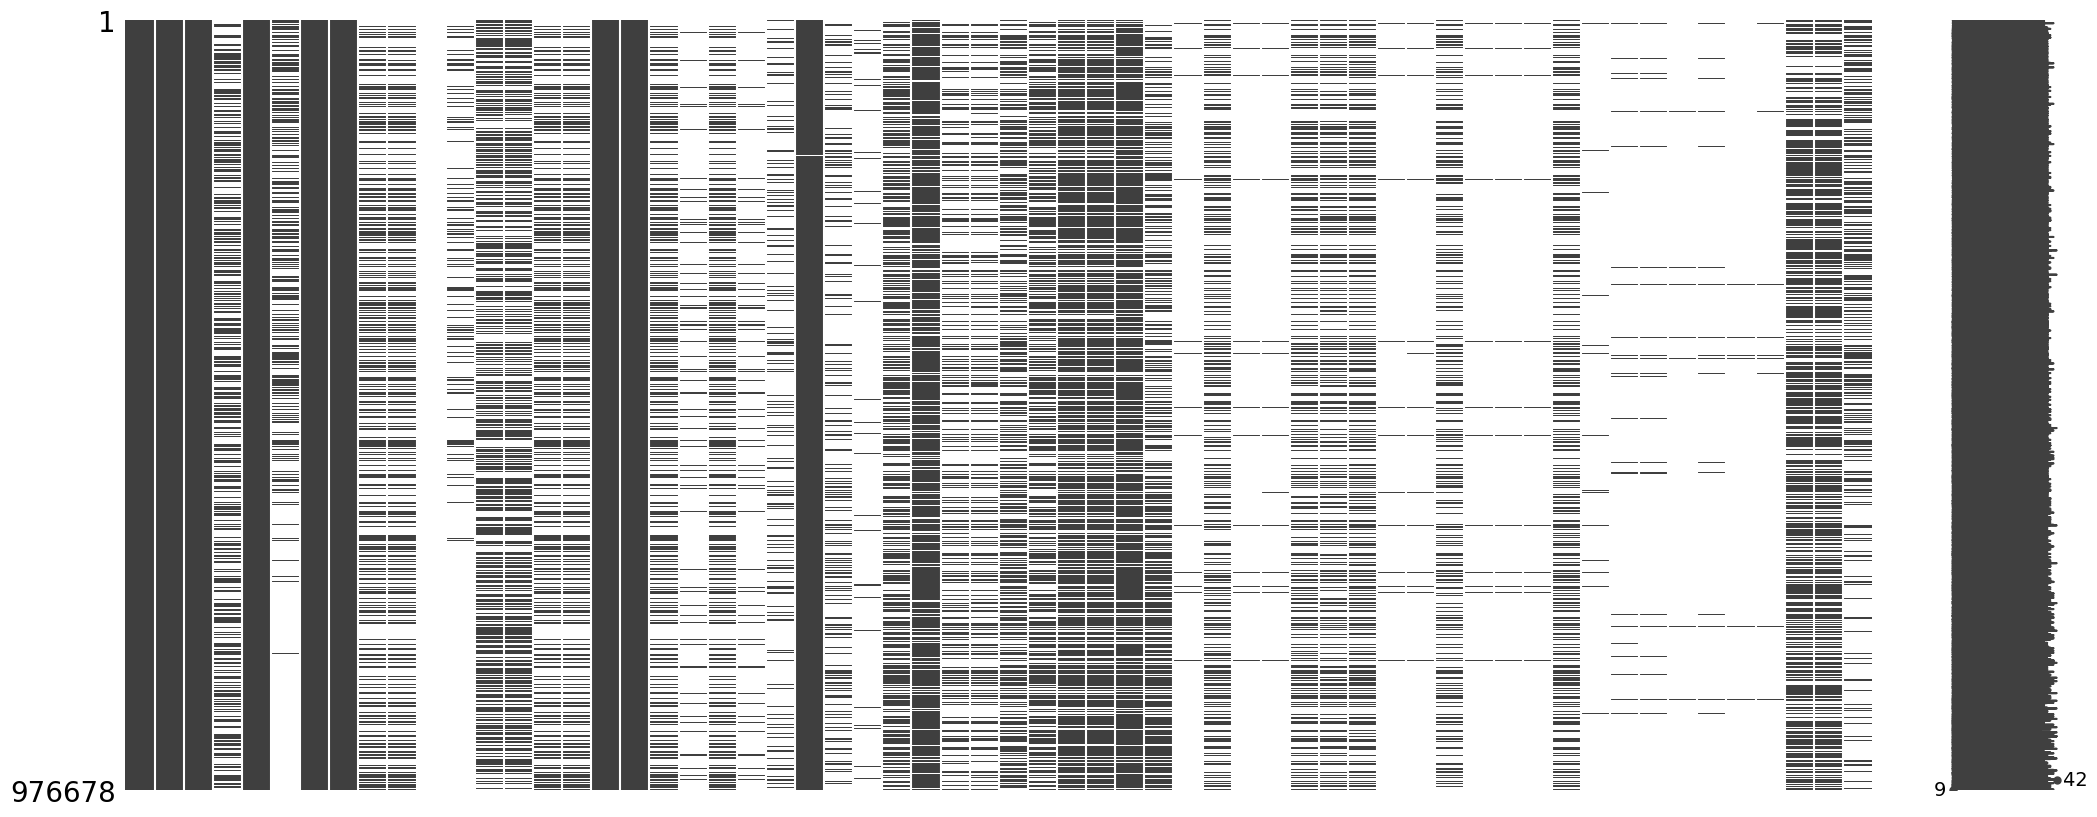


--- هیت‌مپ همبستگی مقادیر گمشده ---


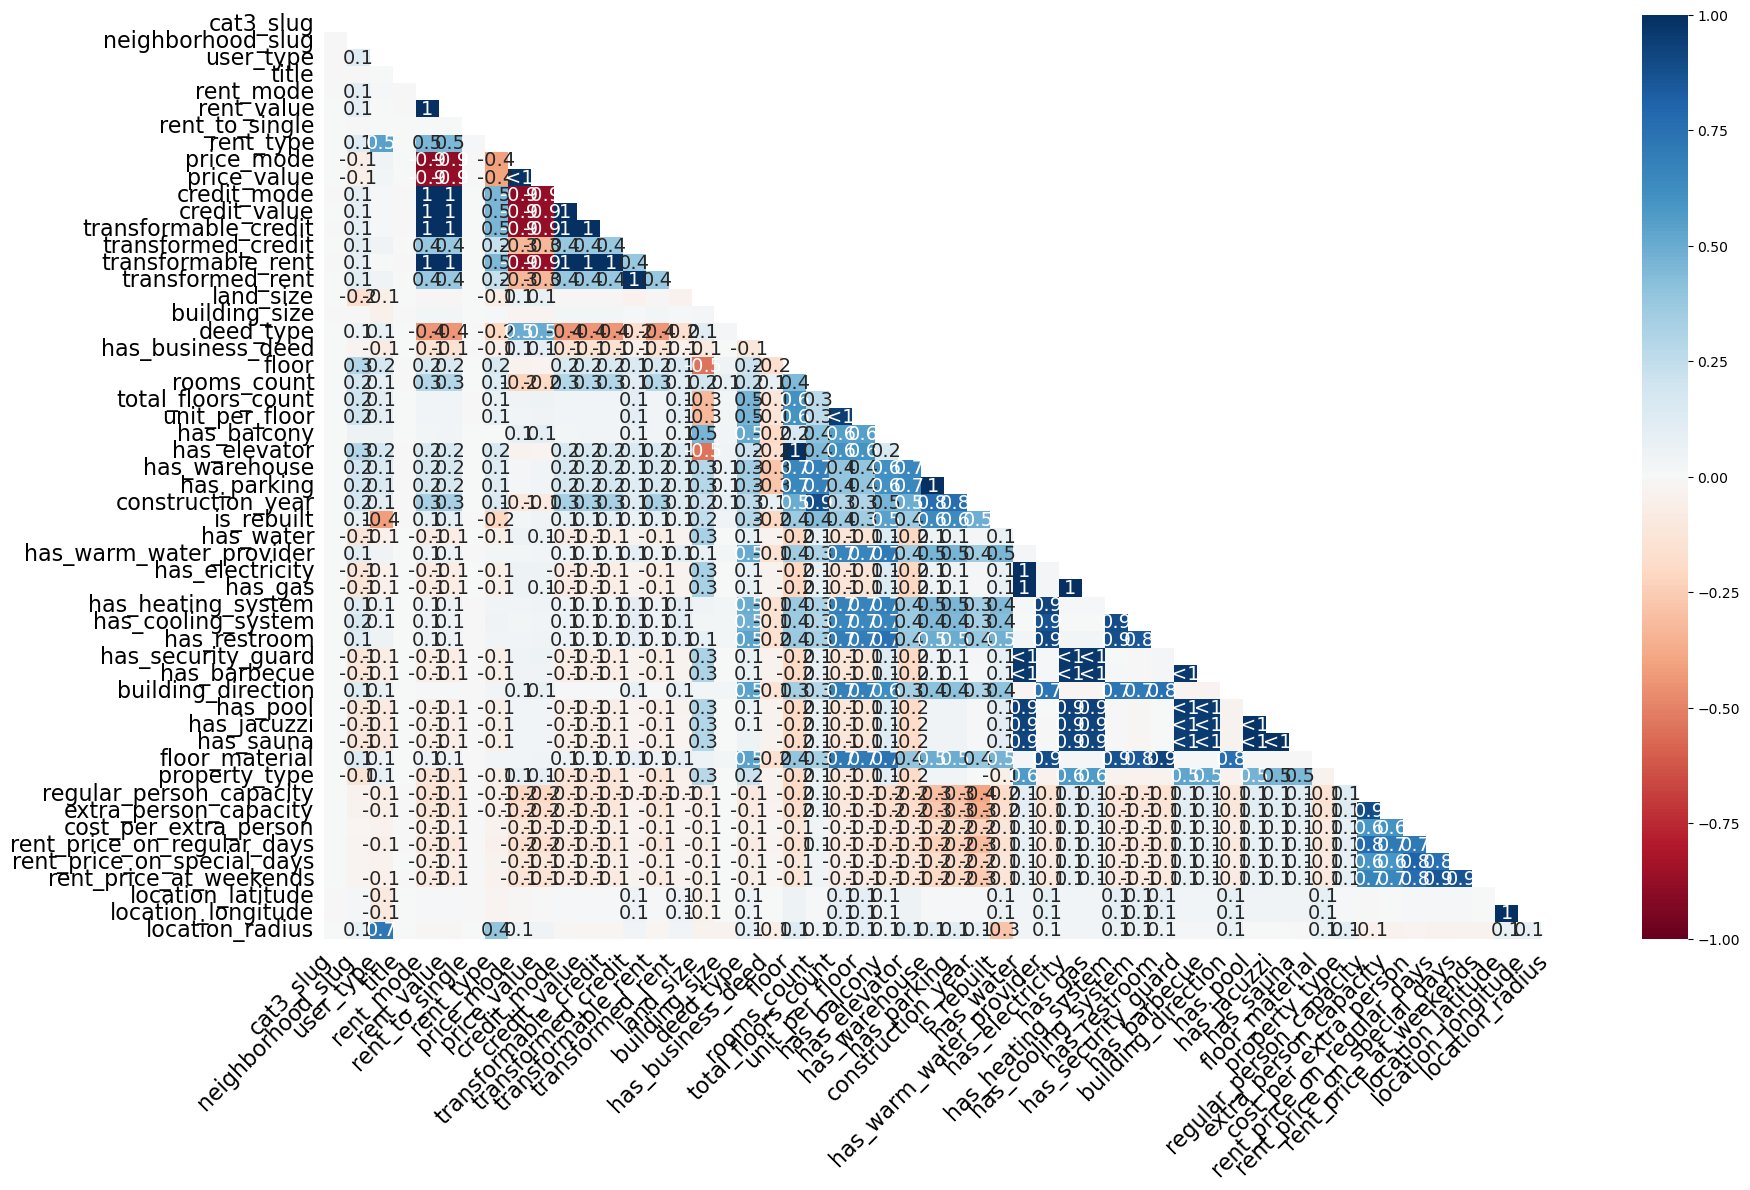

In [56]:
# رسم ماتریس گمشدگی
# این ماتریس به شما نشان می‌دهد که مقادیر گمشده در کجای دیتافریم قرار دارند
print("\n--- ماتریس الگوی مقادیر گمشده ---")
msno.matrix(df_type_clean)
plt.show()

# رسم هیت‌مپ همبستگی مقادیر گمشده
# نقاط روشن نشان‌دهنده همبستگی بالا در گم‌شدن داده‌ها هستند
# مثلاً اگر مقدار یک ستون NaN باشد، مقدار ستون دیگر هم به احتمال زیاد NaN است
print("\n--- هیت‌مپ همبستگی مقادیر گمشده ---")
msno.heatmap(df_type_clean)
plt.show()

In [69]:
# 1. یک دیتافریم بولی بسازید که True یعنی مقدار گمشده است
missing_df = df_clean_content.isnull()

# 2. ماتریس همبستگی را روی این دیتافریم بولی محاسبه کنید
missing_corr = missing_df.corr()

# 3. ماتریس را به یک لیست ستونی تبدیل کنید تا راحت‌تر فیلتر شود
# و مقادیر تکراری و همبستگی یک ستون با خودش را حذف کنید
corr_unstacked = missing_corr.unstack()
corr_filtered = corr_unstacked[corr_unstacked.abs() > 0.7] # یک آستانه بالا انتخاب کنید (مثلا 0.7)
corr_filtered = corr_filtered[corr_filtered != 1.0] # همبستگی یک ستون با خودش را حذف کن

# 4. نمایش زوج ستون‌هایی که گمشدگی آن‌ها به شدت همبسته است
print("--- زوج ستون‌ها با همبستگی بالای گمشدگی (آستانه > 0.7) ---")
if corr_filtered.empty:
    print("هیچ همبستگی قدرتمندی در گمشدگی داده‌ها یافت نشد.")
else:
    display(corr_filtered.sort_values(ascending=False))

--- زوج ستون‌ها با همبستگی بالای گمشدگی (آستانه > 0.7) ---


has_parking           has_warehouse           0.999997
has_warehouse         has_parking             0.999997
transformable_credit  credit_value            0.999976
credit_value          transformable_credit    0.999976
rent_value            transformable_rent      0.999833
                                                ...   
credit_value          price_mode             -0.889451
credit_mode           price_mode             -0.891219
price_mode            credit_mode            -0.891219
                      rent_mode              -0.891219
rent_mode             price_mode             -0.891219
Length: 182, dtype: float64

--- نمایش ماتریس گمشدگی بر روی نمونه‌ای با اندازه 10000 ---


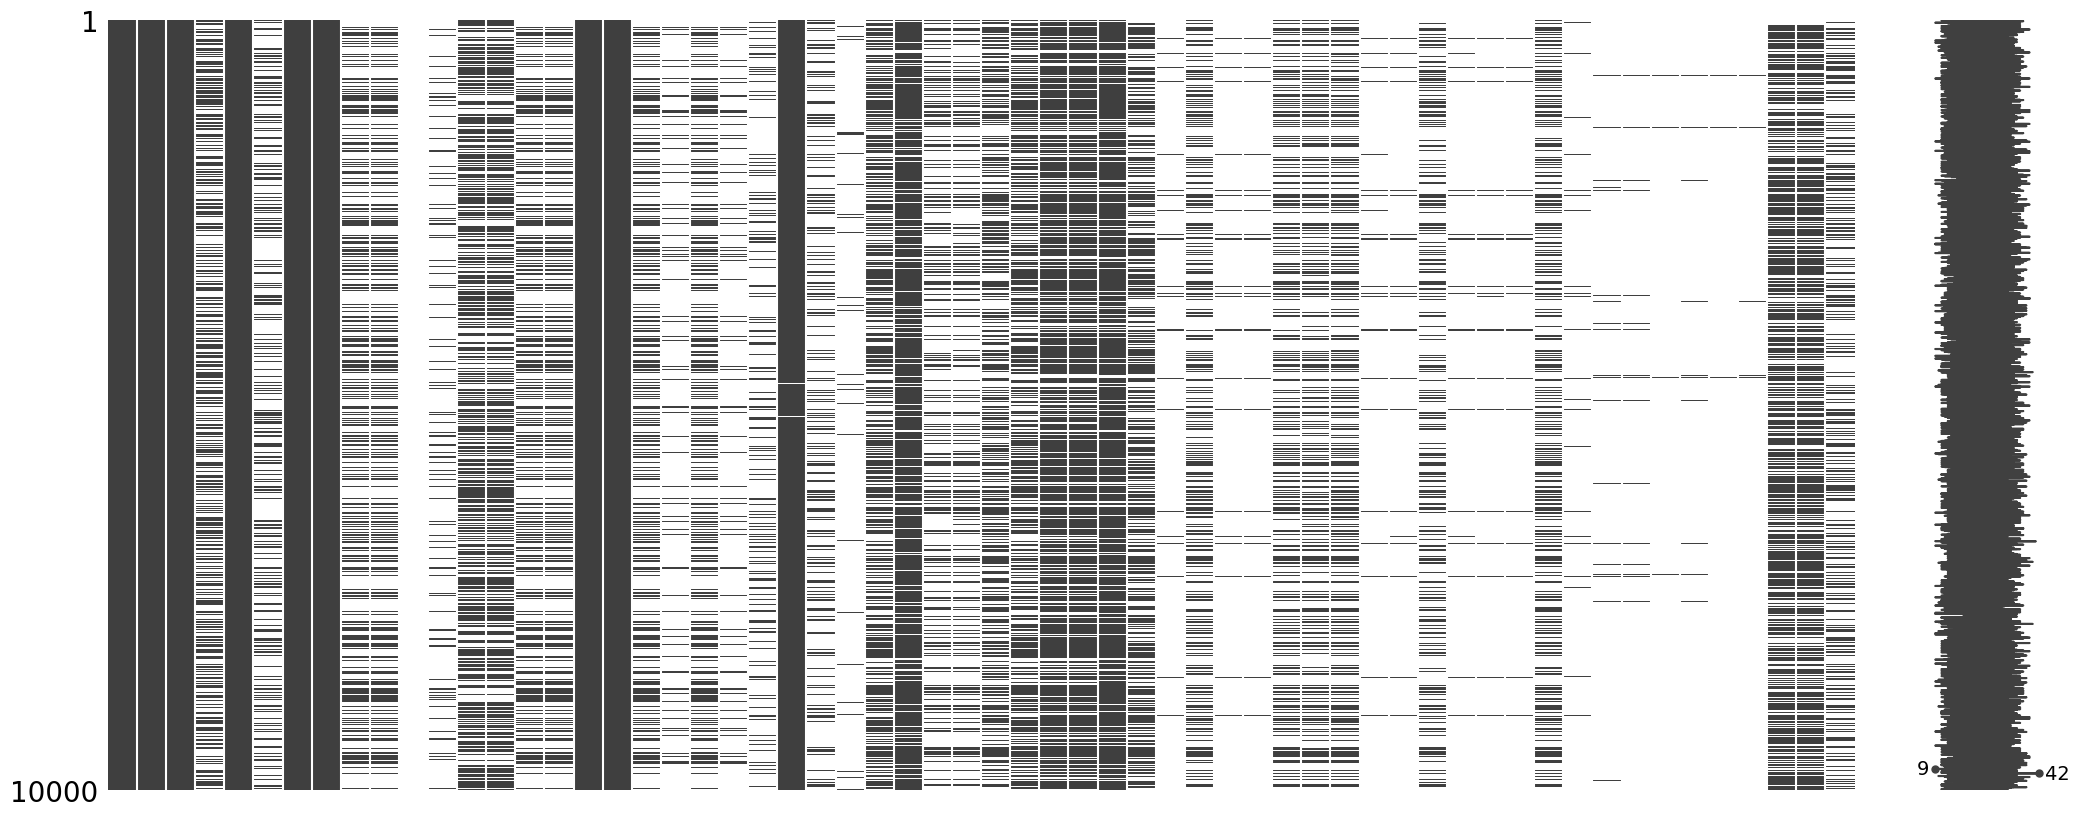

In [60]:
# یک نمونه تصادفی با اندازه معقول (مثلاً 5000 یا 10000 ردیف) انتخاب کنید
sample_size = min(10000, len(df_type_clean)) # برای جلوگیری از خطا اگر داده کمتر از 10000 بود
df_sample = df_clean_content.sample(sample_size, random_state=42)

print(f"--- نمایش ماتریس گمشدگی بر روی نمونه‌ای با اندازه {sample_size} ---")
msno.matrix(df_sample)
plt.show()

In [71]:
def missing_by_group(dfc, group_col):
    result = {}
    for group_name, group_df in dfc.groupby(group_col ,observed=True):
        result[group_name] = group_df.isna().mean()*100
    return pd.DataFrame(result)
    
missing_by_cat2 = missing_by_group(df_clean_content, 'cat2_slug')
missing_by_cat2 = missing_by_cat2.sort_values(by='commercial-rent', ascending=False)
missing_by_cat2.round(1)

,commercial-rent,commercial-sell,real-estate-services,residential-rent,residential-sell,temporary-rent
has_balcony,100.0,100.0,100.0,31.3,43.1,100.0
is_rebuilt,100.0,100.0,100.0,23.1,43.0,100.0
has_warm_water_provider,100.0,100.0,100.0,45.5,58.8,100.0
has_electricity,100.0,100.0,100.0,98.1,95.7,85.4
has_gas,100.0,100.0,100.0,98.1,95.7,85.5
has_heating_system,100.0,100.0,100.0,47.3,59.8,100.0
unit_per_floor,100.0,100.0,100.0,57.6,66.7,100.0
total_floors_count,100.0,100.0,100.0,57.6,66.3,100.0
has_cooling_system,100.0,100.0,100.0,49.5,62.0,100.0
has_restroom,100.0,100.0,100.0,42.1,55.6,100.0


In [73]:
# تعیین آستانه حذف
threshold = 70.0

# 1. محاسبه درصد مقادیر گمشده به تفکیک هر مقدار در 'cat2_slug'
# --- اعمال اصلاحات برای حذف هشدارها ---
missing_pivot = df_clean_content.groupby('cat2_slug', observed=True).apply(
    lambda x: (x.isnull().sum() / len(x)) * 100,
    include_groups=False # خود cat2_slug رو پاک میکنه
)


print("--- درصد مقادیر گمشده به تفکیک نوع معامله (Pivot Table) ---")
display(
    missing_pivot.style.background_gradient(cmap='Reds', axis=None, low=0, high=100)
                      .format("{:.2f}%")
                      .set_properties(**{'width': '100px'})
)

# ------------------------------------------------------------------
# بخش دوم کد برای پیدا کردن ستون‌های مشترک 
#--------------------

# 2. بررسی اینکه کدام ستون‌ها در "تمام" سطرها بالاتر از آستانه هستند
all_above_threshold = (missing_pivot > threshold).all(axis=0)

# 3. استخراج نام ستون‌هایی که شرط بالا را ارضا می‌کنند
common_useless_cols = all_above_threshold[all_above_threshold].index.tolist()

print(f"\n--- ستون‌های کاندیدای حذف (مقدار گمشده > {threshold}% در *تمام* انواع معامله) ---")
if common_useless_cols:
    print("لیست ستون‌های مشترک برای حذف:")
    for col in common_useless_cols:
        print(f"- {col}")
else:
    print("هیچ ستونی یافت نشد که در تمام دسته‌ها بالای آستانه باشد.")

--- درصد مقادیر گمشده به تفکیک نوع معامله (Pivot Table) ---


,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
cat2_slug,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
commercial-rent,0.00%,0.00%,51.56%,0.00%,76.30%,0.00%,0.00%,0.05%,0.64%,100.00%,76.52%,99.96%,99.96%,0.05%,0.63%,0.00%,0.00%,0.63%,88.08%,0.65%,88.08%,100.00%,0.04%,100.00%,100.00%,72.10%,0.52%,100.00%,100.00%,100.00%,72.08%,72.08%,72.08%,0.65%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,33.39%,33.39%,72.14%
commercial-sell,0.00%,0.00%,61.27%,0.00%,81.28%,0.00%,0.00%,99.99%,99.99%,100.00%,99.99%,14.42%,17.26%,99.99%,99.99%,0.00%,0.00%,100.00%,100.00%,100.00%,100.00%,100.00%,0.04%,100.00%,10.74%,86.72%,1.48%,100.00%,100.00%,100.00%,86.71%,86.71%,86.71%,1.70%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,34.19%,34.19%,74.88%
real-estate-services,0.00%,0.00%,53.57%,0.00%,4.98%,0.00%,0.00%,99.83%,99.83%,100.00%,99.83%,0.17%,0.17%,99.83%,99.83%,0.00%,0.00%,100.00%,100.00%,100.00%,100.00%,100.00%,99.50%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,38.21%,38.21%,16.36%
residential-rent,0.00%,0.00%,48.88%,0.00%,68.74%,0.00%,0.01%,0.00%,0.44%,99.99%,68.87%,100.00%,100.00%,0.00%,0.17%,0.00%,0.00%,0.17%,77.11%,0.46%,77.11%,76.62%,0.00%,100.00%,100.00%,23.47%,0.00%,57.61%,57.59%,31.30%,23.39%,0.00%,0.00%,0.00%,23.08%,98.05%,45.46%,98.05%,98.05%,47.27%,49.48%,42.07%,98.18%,98.15%,57.00%,98.20%,98.20%,98.21%,42.22%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,33.39%,33.39%,64.90%
residential-sell,0.00%,0.00%,59.50%,0.00%,69.95%,0.00%,0.00%,100.00%,100.00%,100.00%,100.00%,3.27%,3.97%,100.00%,100.00%,0.00%,0.00%,100.00%,100.00%,100.00%,100.00%,78.09%,0.00%,54.36%,100.00%,45.46%,23.48%,66.32%,66.72%,43.07%,45.39%,23.48%,23.48%,23.48%,43.00%,95.73%,58.82%,95.73%,95.73%,59.81%,62.01%,55.57%,96.01%,96.07%,63.07%,96.36%,96.46%,96.49%,55.66%,95.92%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,34.34%,34.34%,63.63%
temporary-rent,0.00%,0.00%,67.15%,0.00%,89.33%,0.00%,0.02%,99.99%,99.99%,100.00%,99.99%,99.98%,99.98%,99.99%,99.99%,0.00%,0.00%,100.00%,100.00%,100.00%,100.00%,100.00%,0.02%,100.00%,100.00%,100.00%,0.02%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,85.43%,100.00%,85.42%,85.45%,100.00%,100.00%,100.00%,86.27%,85.70%,100.00%,85.99%,86.30%,86.47%,100.00%,85.30%,0.09%,19.62%,65.59%,39.38%,64.81%,54.50%,34.46%,34.46%,79.15%



--- ستون‌های کاندیدای حذف (مقدار گمشده > 70.0% در *تمام* انواع معامله) ---
لیست ستون‌های مشترک برای حذف:
- rent_to_single
- transformed_credit
- transformed_rent
- land_size
- has_water
- has_electricity
- has_gas
- has_security_guard
- has_barbecue
- has_pool
- has_jacuzzi
- has_sauna
- property_type


In [77]:
#تعریف تابع تحلیل همبستگی درصد مقادیر گمشده 

def calculate_missing_correlation(group_df, threshold=0.7):
    """
    این تابع یک دیتافریم (یک گروه) را گرفته و همبستگی گمشدگی 
    داده‌ها را برای ستون‌های آن محاسبه می‌کند.
    """
    # 1. دیتافریم بولی برای مقادیر گمشده
    missing_df = group_df.isnull()

    # 2. محاسبه ماتریس همبستگی
    missing_corr = missing_df.corr()

    # 3. تبدیل ماتریس به لیست و فیلتر کردن
    corr_unstacked = missing_corr.unstack()
    corr_filtered = corr_unstacked[corr_unstacked.abs() > threshold]
    corr_filtered = corr_filtered[corr_filtered != 1.0]
    
    return corr_filtered



In [79]:
# گرفتن لیست دسته‌های منحصر به فرد
transaction_types = df_clean_content['cat2_slug'].unique()
print("انواع معامله موجود در دیتاست:")
print(transaction_types)

انواع معامله موجود در دیتاست:
['residential-sell', 'temporary-rent', 'commercial-rent', 'commercial-sell', 'residential-rent', 'real-estate-services']
Categories (6, object): ['commercial-rent', 'commercial-sell', 'real-estate-services', 'residential-rent', 'residential-sell', 'temporary-rent']


In [81]:
# 1. تعریف نوع معامله مورد نظر
slug_to_analyze = 'temporary-rent'

# 2. فیلتر کردن دیتافریم فقط برای این نوع معامله
df_subset = df_clean_content[df_clean_content['cat2_slug'] == slug_to_analyze].copy()

# 3. محاسبه همبستگی گمشدگی برای این زیرمجموعه
missing_corr = calculate_missing_correlation(df_subset, threshold=0.7)

# 4. نمایش نتایج
print(f"--- زوج ستون‌ها با همبستگی بالای گمشدگی برای '{slug_to_analyze}' (آستانه > 0.7) ---")
if not missing_corr.empty:
    # استفاده از to_string() برای نمایش کامل خروجی در صورت طولانی بودن
    print(missing_corr.sort_values(ascending=False).to_string())
else:
    print("هیچ زوج ستونی با همبستگی گمشدگی بالای 0.7 یافت نشد.")

--- زوج ستون‌ها با همبستگی بالای گمشدگی برای 'temporary-rent' (آستانه > 0.7) ---
has_electricity             has_water                     0.998916
has_water                   has_electricity               0.998916
has_gas                     has_electricity               0.998374
has_electricity             has_gas                       0.998374
has_gas                     has_water                     0.997831
has_water                   has_gas                       0.997831
has_jacuzzi                 has_sauna                     0.991706
has_sauna                   has_jacuzzi                   0.991706
has_electricity             has_barbecue                  0.988052
has_barbecue                has_electricity               0.988052
                            has_water                     0.988042
has_water                   has_barbecue                  0.988042
has_barbecue                has_gas                       0.987753
has_gas                     has_barbecue        

In [83]:
# پر کردن ستون های امکانات با مقدار پیش فرض

# لیست ستون‌های امکانات که باید با False پر شوند
amenity_cols = [
    'has_water', 'has_electricity', 'has_gas', 'has_security_guard',
    'has_barbecue', 'has_pool', 'has_jacuzzi', 'has_sauna'
]

# ستون دسته‌بندی که باید با یک مقدار جدید پر شود
categorical_col = 'property_type'
new_category_for_prop = 'not_specified'

# تعریف گروه هدف
target_group_slug = 'temporary-rent'
condition = df_clean_content['cat2_slug'] == target_group_slug

# --- گام ۲: اجرای جایگزینی برای ستون‌های امکانات ---

df_fill_amenity = df_clean_content


print(f"شروع پردازش برای گروه '{target_group_slug}'...")
df_fill_amenity.loc[condition, amenity_cols] = df_fill_amenity.loc[condition, amenity_cols].fillna(False)
print(f"جایگزینی مقادیر گمشده در {len(amenity_cols)} ستون امکانات با 'False' انجام شد.")

# --- گام ۳: اجرای جایگزینی برای ستون دسته‌بندی ---

if new_category_for_prop not in df_fill_amenity[categorical_col].cat.categories:
    df_fill_amenity[categorical_col] = df_fill_amenity[categorical_col].cat.add_categories([new_category_for_prop])
    print(f"دسته جدید '{new_category_for_prop}' به ستون '{categorical_col}' اضافه شد.")


df_fill_amenity.loc[condition, categorical_col] = df_fill_amenity.loc[condition, categorical_col].fillna(new_category_for_prop)
print(f"جایگزینی مقادیر گمشده در ستون '{categorical_col}' با '{new_category_for_prop}' انجام شد.")


# --- گام ۴: اعتبارسنجی نهایی ---

print("\n--- نتایج اعتبارسنجی ---")
# فیلتر کردن دیتافریم برای گروه هدف جهت نمایش نتایج
target_group_df = df_fill_amenity[condition]

# بررسی مقادیر گمشده در ستون‌های امکانات
missing_amenities = target_group_df[amenity_cols].isnull().sum().sum()
print(f"تعداد کل مقادیر گمشده باقی‌مانده در ستون‌های امکانات: {missing_amenities}")

# بررسی مقادیر گمشده در ستون دسته‌بندی
missing_categorical = target_group_df[categorical_col].isnull().sum()
print(f"تعداد کل مقادیر گمشده باقی‌مانده در ستون '{categorical_col}': {missing_categorical}")

print(f"\nتوزیع مقادیر در ستون '{categorical_col}' پس از پاکسازی:")
print(target_group_df[categorical_col].value_counts(dropna=False))


شروع پردازش برای گروه 'temporary-rent'...
جایگزینی مقادیر گمشده در 8 ستون امکانات با 'False' انجام شد.
دسته جدید 'not_specified' به ستون 'property_type' اضافه شد.
جایگزینی مقادیر گمشده در ستون 'property_type' با 'not_specified' انجام شد.

--- نتایج اعتبارسنجی ---
تعداد کل مقادیر گمشده باقی‌مانده در ستون‌های امکانات: 0
تعداد کل مقادیر گمشده باقی‌مانده در ستون 'property_type': 0

توزیع مقادیر در ستون 'property_type' پس از پاکسازی:
property_type
not_specified      25286
jungle              1548
beach               1262
other                881
jungle-mountain      594
mountain              72
Name: count, dtype: int64


In [85]:
# تعیین آستانه حذف
threshold = 70.0

# 1. محاسبه درصد مقادیر گمشده به تفکیک هر مقدار در 'cat2_slug'
# --- اعمال اصلاحات برای حذف هشدارها ---
missing_pivot = df_fill_amenity.groupby('cat2_slug', observed=True).apply(
    lambda x: (x.isnull().sum() / len(x)) * 100,
    include_groups=False # خود cat2_slug رو پاک میکنه
)


print("--- درصد مقادیر گمشده به تفکیک نوع معامله (Pivot Table) ---")
display(
    missing_pivot.style.background_gradient(cmap='Reds', axis=None, low=0, high=100)
                      .format("{:.2f}%")
                      .set_properties(**{'width': '100px'})
)

# ------------------------------------------------------------------
# بخش دوم کد برای پیدا کردن ستون‌های مشترک 
#--------------------

# 2. بررسی اینکه کدام ستون‌ها در "تمام" سطرها بالاتر از آستانه هستند
all_above_threshold = (missing_pivot > threshold).all(axis=0)

# 3. استخراج نام ستون‌هایی که شرط بالا را ارضا می‌کنند
common_useless_cols = all_above_threshold[all_above_threshold].index.tolist()

print(f"\n--- ستون‌های کاندیدای حذف (مقدار گمشده > {threshold}% در *تمام* انواع معامله) ---")
if common_useless_cols:
    print("لیست ستون‌های مشترک برای حذف:")
    for col in common_useless_cols:
        print(f"- {col}")
else:
    print("هیچ ستونی یافت نشد که در تمام دسته‌ها بالای آستانه باشد.")

--- درصد مقادیر گمشده به تفکیک نوع معامله (Pivot Table) ---


,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
cat2_slug,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
commercial-rent,0.00%,0.00%,51.56%,0.00%,76.30%,0.00%,0.00%,0.05%,0.64%,100.00%,76.52%,99.96%,99.96%,0.05%,0.63%,0.00%,0.00%,0.63%,88.08%,0.65%,88.08%,100.00%,0.04%,100.00%,100.00%,72.10%,0.52%,100.00%,100.00%,100.00%,72.08%,72.08%,72.08%,0.65%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,33.39%,33.39%,72.14%
commercial-sell,0.00%,0.00%,61.27%,0.00%,81.28%,0.00%,0.00%,99.99%,99.99%,100.00%,99.99%,14.42%,17.26%,99.99%,99.99%,0.00%,0.00%,100.00%,100.00%,100.00%,100.00%,100.00%,0.04%,100.00%,10.74%,86.72%,1.48%,100.00%,100.00%,100.00%,86.71%,86.71%,86.71%,1.70%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,34.19%,34.19%,74.88%
real-estate-services,0.00%,0.00%,53.57%,0.00%,4.98%,0.00%,0.00%,99.83%,99.83%,100.00%,99.83%,0.17%,0.17%,99.83%,99.83%,0.00%,0.00%,100.00%,100.00%,100.00%,100.00%,100.00%,99.50%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,38.21%,38.21%,16.36%
residential-rent,0.00%,0.00%,48.88%,0.00%,68.74%,0.00%,0.01%,0.00%,0.44%,99.99%,68.87%,100.00%,100.00%,0.00%,0.17%,0.00%,0.00%,0.17%,77.11%,0.46%,77.11%,76.62%,0.00%,100.00%,100.00%,23.47%,0.00%,57.61%,57.59%,31.30%,23.39%,0.00%,0.00%,0.00%,23.08%,98.05%,45.46%,98.05%,98.05%,47.27%,49.48%,42.07%,98.18%,98.15%,57.00%,98.20%,98.20%,98.21%,42.22%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,33.39%,33.39%,64.90%
residential-sell,0.00%,0.00%,59.50%,0.00%,69.95%,0.00%,0.00%,100.00%,100.00%,100.00%,100.00%,3.27%,3.97%,100.00%,100.00%,0.00%,0.00%,100.00%,100.00%,100.00%,100.00%,78.09%,0.00%,54.36%,100.00%,45.46%,23.48%,66.32%,66.72%,43.07%,45.39%,23.48%,23.48%,23.48%,43.00%,95.73%,58.82%,95.73%,95.73%,59.81%,62.01%,55.57%,96.01%,96.07%,63.07%,96.36%,96.46%,96.49%,55.66%,95.92%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,34.34%,34.34%,63.63%
temporary-rent,0.00%,0.00%,67.15%,0.00%,89.33%,0.00%,0.02%,99.99%,99.99%,100.00%,99.99%,99.98%,99.98%,99.99%,99.99%,0.00%,0.00%,100.00%,100.00%,100.00%,100.00%,100.00%,0.02%,100.00%,100.00%,100.00%,0.02%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,0.00%,100.00%,0.00%,0.00%,100.00%,100.00%,100.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,100.00%,0.00%,0.09%,19.62%,65.59%,39.38%,64.81%,54.50%,34.46%,34.46%,79.15%



--- ستون‌های کاندیدای حذف (مقدار گمشده > 70.0% در *تمام* انواع معامله) ---
لیست ستون‌های مشترک برای حذف:
- rent_to_single
- transformed_credit
- transformed_rent
- land_size


In [87]:
# تحلیل ستون‌های کاندیدای حذف

candidate_cols_for_removal = [
    'rent_to_single',
    'transformed_credit',
    'transformed_rent',
    'land_size'
]



print("--- شروع تحلیل ستون‌های کاندیدای حذف ---\n")

for col in candidate_cols_for_removal:
    print(f"===================== تحلیل ستون: {col} =====================")
    
    # تعداد کل مقادیر غیر گمشده
    non_missing_count = df_fill_amenity[col].notna().sum()
    total_count = len(df)
    missing_percentage = (1 - non_missing_count / total_count) * 100
    
    print(f"درصد کلی گمشدگی: {missing_percentage:.2f}%")
    print(f"تعداد مقادیر موجود (غیر NaN): {non_missing_count}")
    
    if non_missing_count > 0:
        # بررسی توزیع این مقادیر در انواع معاملات (cat2_slug)
        print("\n--- توزیع مقادیر موجود بر اساس نوع معامله (cat2_slug):")
        # .value_counts() روی ردیف‌هایی که مقدار دارند، اجرا می‌شود
        print(df_fill_amenity[df_fill_amenity[col].notna()]['cat2_slug'].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))

        # بررسی ویژه برای land_size بر اساس نوع ملک
        if col == 'land_size':
            print("\n--- توزیع مقادیر موجود بر اساس نوع ملک (cat3_slug):")
            print(df_fill_amenity[df_fill_amenity[col].notna()]['cat3_slug'].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))
            
            # سوال کلیدی: درصد گمشدگی در بین ویلاها چقدر است؟
            villas_df = df_fill_amenity[df_fill_amenity['cat3_slug'] == 'villa']
            if not villas_df.empty:
                missing_in_villas = villas_df[col].isnull().mean() * 100
                print(f"\n>>>>> درصد گمشدگی '{col}' فقط برای ویلاها: {missing_in_villas:.2f}% <<<<<")
    else:
        print("این ستون هیچ مقدار غیر گمشده‌ای ندارد.")
        
    print("\n")


--- شروع تحلیل ستون‌های کاندیدای حذف ---

===================== تحلیل ستون: rent_to_single =====================
درصد کلی گمشدگی: 100.00%
تعداد مقادیر موجود (غیر NaN): 19

--- توزیع مقادیر موجود بر اساس نوع معامله (cat2_slug):
cat2_slug
residential-rent        100.0%
commercial-rent           0.0%
commercial-sell           0.0%
real-estate-services      0.0%
residential-sell          0.0%
temporary-rent            0.0%
Name: proportion, dtype: object


===================== تحلیل ستون: transformed_credit =====================
درصد کلی گمشدگی: 92.77%
تعداد مقادیر موجود (غیر NaN): 72347

--- توزیع مقادیر موجود بر اساس نوع معامله (cat2_slug):
cat2_slug
residential-rent        87.4%
commercial-rent         12.6%
commercial-sell          0.0%
real-estate-services     0.0%
residential-sell         0.0%
temporary-rent           0.0%
Name: proportion, dtype: object


===================== تحلیل ستون: transformed_rent =====================
درصد کلی گمشدگی: 92.77%
تعداد مقادیر موجود (غیر NaN): 7

تعداد کل ردیف‌ها در دسته 'residential-rent': 276267

ستون‌های موجود برای تحلیل همبستگی: ['transformed_credit', 'transformed_rent', 'transformable_credit', 'transformable_rent', 'rent_credit_transform']

--- درصد مقادیر گمشده برای ستون‌های انتخابی (فقط در residential-rent):
transformed_credit       77.11%
transformed_rent         77.11%
transformable_credit      0.17%
transformable_rent        0.46%
rent_credit_transform     0.00%
dtype: object


--- ماتریس همبستگی:
                       transformed_credit  transformed_rent  \
transformed_credit               1.000000          0.283180   
transformed_rent                 0.283180          1.000000   
transformable_credit             0.606796          0.798451   
transformable_rent               0.687050          0.226994   
rent_credit_transform                 NaN               NaN   

                       transformable_credit  transformable_rent  \
transformed_credit                 0.606796            0.687050   
transformed_rent 

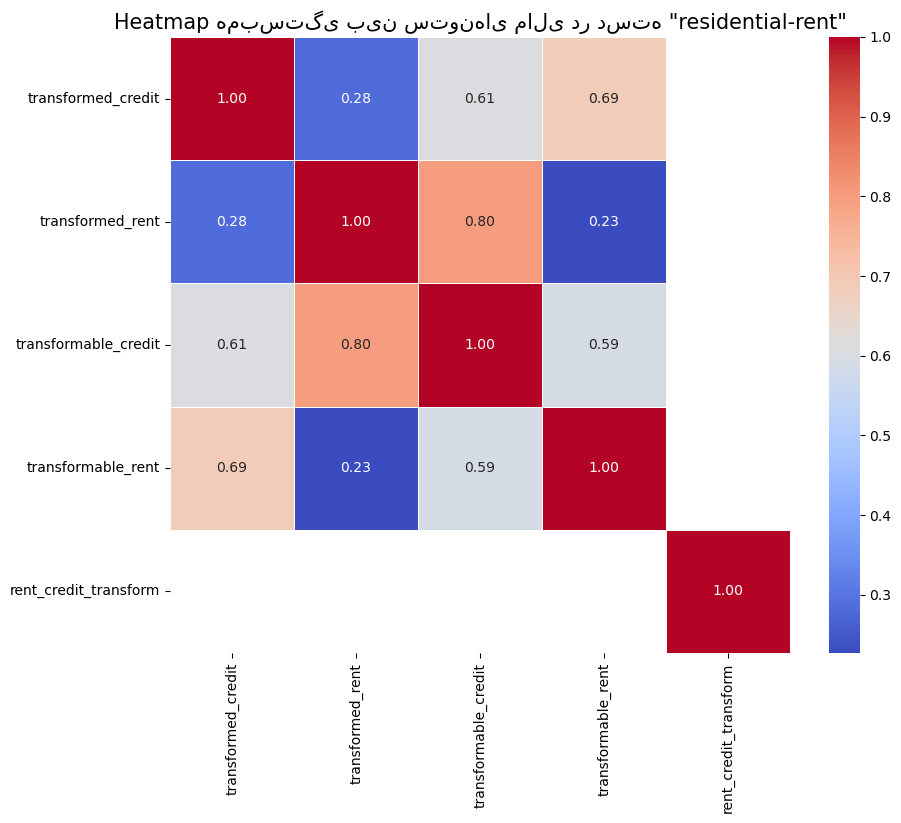

In [93]:
df_rent_subset = df_fill_amenity[df_fill_amenity['cat2_slug'] == 'residential-rent'].copy()

print(f"تعداد کل ردیف‌ها در دسته 'residential-rent': {len(df_rent_subset)}\n")


# --- مرحله 1: انتخاب ستون‌ها و بررسی اولیه ---
# لیست ستون‌هایی که می‌خواهیم همبستگی آن‌ها را بررسی کنیم
correlation_cols = [
    'transformed_credit',
    'transformed_rent',
    'transformable_credit',
    'transformable_rent',
    'rent_credit_transform'
]

# برای اینکه مطمئن شویم این ستون‌ها در دیتافریم ما وجود دارند
# (ممکن است در مرحله قبل برخی را حذف کرده باشیم)
existing_cols = [col for col in correlation_cols if col in df_rent_subset.columns]
print(f"ستون‌های موجود برای تحلیل همبستگی: {existing_cols}\n")

# یک دیتافریم کوچکتر فقط با این ستون‌ها می‌سازیم
df_corr_analysis = df_rent_subset[existing_cols]

# بررسی درصد مقادیر گمشده در این زیرمجموعه
print("--- درصد مقادیر گمشده برای ستون‌های انتخابی (فقط در residential-rent):")
missing_percentage = (df_corr_analysis.isnull().sum() / len(df_corr_analysis)) * 100
print(missing_percentage.apply(lambda x: f"{x:.2f}%"))
print("\n")


# --- مرحله 2: محاسبه و نمایش همبستگی ---
print("--- ماتریس همبستگی:")
# محاسبه ماتریس همبستگی
# .corr() به طور خودکار مقادیر NaN را نادیده می‌گیرد
correlation_matrix = df_corr_analysis.corr()
print(correlation_matrix)

# نمایش نقشه حرارتی (Heatmap) برای درک بهتر
plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,          # نمایش مقادیر عددی روی هر سلول
    cmap='coolwarm',     # انتخاب پالت رنگی (آبی برای منفی، قرمز برای مثبت)
    fmt='.2f',           # فرمت نمایش اعداد تا دو رقم اعشار
    linewidths=.5
)
plt.title('Heatmap همبستگی بین ستون‌های مالی در دسته "residential-rent"', fontsize=15)
plt.show()

In [97]:
# تعریف هر شرط به صورت جداگانه
cond_category = df_fill_amenity['cat2_slug'] == 'residential-rent'
cond_both_values = df_fill_amenity['transformed_credit'].notna() & df_fill_amenity['transformed_rent'].notna()
cond_not_transformable = df_fill_amenity['rent_credit_transform'] == False

# ترکیب شرط‌ها با استفاده از اپراتورهای & (AND) و | (OR)
# حتما از پرانتز برای حفظ اولویت عملیات استفاده کنید
#اصلا آگهی ای وجود نداشت که ترنسفورمد داشته باشه و تبدیل رهن و اجاره اش فالس باشه
combined_filter = cond_category & (cond_both_values | cond_not_transformable)

# اعمال فیلتر
filtered_df_alt = df_fill_amenity[combined_filter]


cols_to_display = [
    'cat2_slug' ,  'credit_value',
        'transformable_credit',
        'rent_value',
        'transformable_rent',
        'transformed_credit',
        'transformed_rent'
]
# --- نمایش نتایج برای بررسی ---
print(f"✅ (روش دوم) تعداد {len(filtered_df_alt)} آگهی  یافت شد.")
display(filtered_df_alt[cols_to_display].head())

✅ (روش دوم) تعداد 63252 آگهی  یافت شد.


,cat2_slug,credit_value,transformable_credit,rent_value,transformable_rent,transformed_credit,transformed_rent
517398,residential-rent,1.300000e+09,1.300000e+09,100000.0,100000.0,1.000000e+09,9000000.0
371631,residential-rent,6.000000e+08,6.000000e+08,6600000.0,6600000.0,8.200000e+08,0.0
572449,residential-rent,2.250000e+09,2.250000e+09,0.0,0.0,1.250000e+09,30000000.0
462657,residential-rent,5.000000e+09,5.000000e+09,300000000.0,300000000.0,1.500000e+10,0.0
385432,residential-rent,5.000000e+08,5.000000e+08,60000000.0,60000000.0,1.000000e+08,75000000.0


In [99]:


print("در حال جستجو برای رکوردهایی که مقادیر عددی  ولیو  و ترنسفورمیبل  آن‌ها متفاوت است...")

# --- مرحله ۱: تعریف شرط‌ها ---

# شرط ۱: ستون‌های transformed باید پر باشند (یعنی آگهی "رهن کامل" یا "رهن و اجاره" است)
cond_transformed_notna = (
    df_fill_amenity['transformed_credit'].notna() & 
    df_fill_amenity['transformed_rent'].notna()
)

# شرط ۲: آیا تفاوت عددی بین نسخه خام و پاکسازی شده وجود دارد؟
# از np.isclose برای مقایسه امن اعداد اعشاری استفاده می‌کنیم.
# علامت ~ به معنی "not" یا نقیض است.
cond_credit_differs = (df_fill_amenity['credit_value']- df_fill_amenity['transformable_credit'])!= 0

cond_rent_differs = (df_fill_amenity['rent_value']- df_fill_amenity['transformable_rent'])!= 0


# ترکیب شرط دوم: حداقل یکی از مقایسه های رهن یا اجاره باید تفاوت را نشان دهد
cond_any_difference = (cond_credit_differs | cond_rent_differs)


# --- مرحله ۲: ترکیب نهایی شرط‌ها و فیلتر کردن ---
final_mask = cond_transformed_notna & cond_any_difference

interesting_samples = df_fill_amenity.loc[final_mask]


# --- مرحله ۳: نمایش نتایج ---
if not interesting_samples.empty:
    print(f"\n✅ {len(interesting_samples)} نمونه یافت شد که در آن‌ها مقادیر عددی خام و پاک‌شده متفاوت هستند.")
    print("این تفاوت‌ها به احتمال زیاد ناشی از استانداردسازی واحد (مثلاً تبدیل میلیون تومان به تومان) است.")
    print("نمایش ۵ نمونه اول برای بررسی دقیق:\n")
    
    cols_to_display = [
        'credit_value',
        'transformable_credit',
        'rent_value',
        'transformable_rent',
        'transformed_credit',
        'transformed_rent'
    ]
    
    # برای نمایش بهتر اعداد بزرگ، فرمت نمایش pandas را تغییر می‌دهیم
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(interesting_samples[cols_to_display].head())
    
else:
    print("\n❌ هیچ نمونه‌ای با شرایط مشخص شده یافت نشد.")
    print("این یعنی در تمام رکوردهای بررسی شده، مقادیر عددی ولیو و تبدیل شده کاملاً یکسان بوده‌اند.")


در حال جستجو برای رکوردهایی که مقادیر عددی  ولیو  و ترنسفورمیبل  آن‌ها متفاوت است...

❌ هیچ نمونه‌ای با شرایط مشخص شده یافت نشد.
این یعنی در تمام رکوردهای بررسی شده، مقادیر عددی ولیو و تبدیل شده کاملاً یکسان بوده‌اند.


In [101]:
# حذف ستون های ترنسفورمیبل ها بخاطر اینکه دقیقا با ولیو ها یکسان هستند:
# همچنین حذف ستون rent to single

columns_to_delete = [
    'transformable_credit',
    'transformable_rent',
    'rent_to_single'
]

# 2. پیدا کردن ستون‌هایی از لیست بالا که واقعاً در دیتافریم شما وجود دارند
# این کار از بروز خطا در صورت اجرای مجدد کد جلوگیری می‌کند
cols_that_exist = [col for col in columns_to_delete if col in df_fill_amenity.columns]

# 3. حذف ستون‌های موجود و به‌روزرسانی دیتافریم
if cols_that_exist:
    print(f"ستون‌های زیر در حال حذف شدن هستند: {cols_that_exist}")
    df_drop_dup_col = df_fill_amenity.drop(columns=cols_that_exist, axis=1)
    print("ستون‌ها با موفقیت حذف شدند.")
    print(f"تعداد ستون‌های باقی‌مانده: {df_drop_dup_col.shape[1]}")
else:
    print("هیچ‌کدام از ستون‌های مشخص شده برای حذف، یافت نشدند.")







ستون‌های زیر در حال حذف شدن هستند: ['transformable_credit', 'transformable_rent', 'rent_to_single']
ستون‌ها با موفقیت حذف شدند.
تعداد ستون‌های باقی‌مانده: 57


In [103]:

print("--- تحلیل کامل ارتباط بین rent_credit_transform و ستون‌های transformed_ (همراه با شمارش کل) ---")

# گروه بندی بر اساس ستون پرچم
grouped_analysis = df_drop_dup_col.groupby('rent_credit_transform')

# استفاده از روش مدرن و خواناتر agg با نام‌گذاری ستون‌ها
# ('column_to_aggregate_on', 'function')
result_df = grouped_analysis.agg(
    total_count=('rent_credit_transform', 'size'),  # <-- این خط جدید است: شمارش کل اعضای هر گروه
    credit_filled_count=('transformed_credit', 'count'),
    credit_missing_count=('transformed_credit', lambda x: x.isna().sum()),
    rent_filled_count=('transformed_rent', 'count'),
    rent_missing_count=('transformed_rent', lambda x: x.isna().sum())
)

# تغییر نام ستون‌ها به فارسی برای خوانایی بیشتر
result_df.columns = [
    'تعداد کل',
    'credit_تعداد_پر_شده', 'credit_تعداد_خالی',
    'rent_تعداد_پر_شده', 'rent_تعداد_خالی'
]

# نمایش نتیجه نهایی
display(result_df)

--- تحلیل کامل ارتباط بین rent_credit_transform و ستون‌های transformed_ (همراه با شمارش کل) ---


,تعداد کل,credit_تعداد_پر_شده,credit_تعداد_خالی,rent_تعداد_پر_شده,rent_تعداد_خالی
rent_credit_transform,,,,,
False,624089,0,624089,0,624089
True,352588,72347,280241,72347,280241


In [105]:
print("--- تحلیل جامع توزیع داده‌ها بر اساس پرچم تبدیل و نوع آگهی ---")

# گروه بندی بر اساس هر دو ستون
# این کار یک MultiIndex (شاخص چند سطحی) ایجاد می‌کند
grouped_analysis_detailed = df_drop_dup_col.groupby(['rent_credit_transform', 'cat2_slug'], observed=True)

# اجرای همان agregasi قبلی
result_df_detailed = grouped_analysis_detailed.agg(
    total_count=('rent_credit_transform', 'size'),
    credit_filled_count=('transformed_credit', 'count'),
    credit_missing_count=('transformed_credit', lambda x: x.isna().sum()),
    rent_filled_count=('transformed_rent', 'count'),
    rent_missing_count=('transformed_rent', lambda x: x.isna().sum()),
    rentValue_filled_count=('rent_value', 'count'),
    rentValue_missing_count=('rent_value', lambda x: x.isna().sum()),
    creditVal_filled_count=('credit_value', 'count'),
    creditVal_missing_count=('credit_value', lambda x: x.isna().sum())
)

# تغییر نام ستون‌ها به فارسی
result_df_detailed.columns = [
    'تعداد کل',
    'creditVal_تعداد_پر_شده', 'creditVal_تعداد_خالی',
    'rentVal_تعداد_پر_شده', 'rentVal_تعداد_خالی',
    'credit_تعداد_پر_شده', 'credit_تعداد_خالی',
    'rent_تعداد_پر_شده', 'rent_تعداد_خالی'
]

# نمایش نتیجه کامل
# با استفاده از display، خروجی در نوت‌بوک‌های Jupyter زیباتر نمایش داده می‌شود
display(result_df_detailed)

--- تحلیل جامع توزیع داده‌ها بر اساس پرچم تبدیل و نوع آگهی ---


تعداد کل  creditVal_تعداد_پر_شده  \
rent_credit_transform cat2_slug                                                
False                 commercial-rent             35                       0   
                      commercial-sell          38737                       0   
                      real-estate-services      1204                       0   
                      residential-rent             6                       0   
                      residential-sell        554464                       0   
                      temporary-rent           29643                       0   
True                  commercial-rent          76327                    9101   
                      residential-rent        276261                   63246   

                                            creditVal_تعداد_خالی  \
rent_credit_transform cat2_slug                                    
False                 commercial-rent                         35   
                      commercial-sell                      38737   
                      real-estate-services                  1204   
                      residential-rent                         6   
                      residential-sell                    554464   
                      temporary-rent                       29643   
True                  commercial-rent                      67226   
                      residential-rent                    213015   

                                            rentVal_تعداد_پر_شده  \
rent_credit_transform cat2_slug                                    
False                 commercial-rent                          0   
                      commercial-sell                          0   
                      real-estate-services                     0   
                      residential-rent                         0   
                      residential-sell                         0   
                      temporary-rent                           0   
True                  commercial-rent                       9101   
                      residential-rent                     63246   

                                            rentVal_تعداد_خالی  \
rent_credit_transform cat2_slug                                  
False                 commercial-rent                       35   
                      commercial-sell                    38737   
                      real-estate-services                1204   
                      residential-rent                       6   
                      residential-sell                  554464   
                      temporary-rent                     29643   
True                  commercial-rent                    67226   
                      residential-rent                  213015   

                                            credit_تعداد_پر_شده  \
rent_credit_transform cat2_slug                                   
False                 commercial-rent                         0   
                      commercial-sell                         3   
                      real-estate-services                    2   
                      residential-rent                        0   
                      residential-sell                        3   
                      temporary-rent                          3   
True                  commercial-rent                     75870   
                      residential-rent                   275047   

                                            credit_تعداد_خالی  \
rent_credit_transform cat2_slug                                 
False                 commercial-rent                      35   
                      commercial-sell                   38734   
                      real-estate-services               1202   
                      residential-rent                      6   
                      residential-sell                 554461   
                      temporary-rent                    29640   
True                  commerc

In [107]:
# فیلتر برای رکوردهایی که واجد شرایط تبدیل هستند (True)
# و حداقل یکی از ستون‌های منبع خالی است
# و حداقل یکی از ستون‌های مقصد پر شده است
unexpected_success_df = df_drop_dup_col[
    (df_clean_content['rent_credit_transform'] == True) &
    (df_clean_content['credit_value'].isna() | df_clean_content['rent_value'].isna()) &
    (df_clean_content['transformed_credit'].notna() | df_clean_content['transformed_rent'].notna())
]

print(f"تعداد رکوردهای با موفقیت غیرمنتظره: {len(unexpected_success_df)}")

# نمایش چند نمونه برای بررسی الگو
if not unexpected_success_df.empty:
    print("\nنمونه‌هایی از رکوردهای با موفقیت غیرمنتظره:")
    display(unexpected_success_df[[
        'credit_value', 'rent_value',
        'transformed_credit', 'transformed_rent', 'cat2_slug'
    ]].head())

تعداد رکوردهای با موفقیت غیرمنتظره: 0


In [109]:
# فیلتر برای رکوردهایی که واجد شرایط تبدیل هستند (True)
# و حداقل یکی از ستون‌های منبع پر است
# و هر دو ستون مقصد خالی هستند
unexpected_failure_df = df_drop_dup_col[
    (df_drop_dup_col['rent_credit_transform'] == True) &
    (df_drop_dup_col['credit_value'].notna() | df_drop_dup_col['rent_value'].notna()) &
    (df_drop_dup_col['transformed_credit'].isna() & df_drop_dup_col['transformed_rent'].isna())
]

print(f"تعداد رکوردهای با شکست غیرمنتظره: {len(unexpected_failure_df)}")

# حالا بیایید دلیل را پیدا کنیم: مقادیر غیرعددی در ستون‌های منبع
if not unexpected_failure_df.empty:
    print("\nنمونه‌هایی از رکوردهای با شکست غیرمنتظره:")
    display(unexpected_failure_df[[
        'credit_value', 'rent_value',
        'transformed_credit', 'transformed_rent', 'cat2_slug'
    ]].head())

    print("\n--- بررسی مقادیر منحصر به فرد (غیرعددی) در ستون credit_value برای این رکوردها ---")
    # پیدا کردن مقادیری که عدد نیستند
    non_numeric_credits = pd.to_numeric(unexpected_failure_df['credit_value'], errors='coerce').isna()
    print(unexpected_failure_df.loc[non_numeric_credits, 'credit_value'].value_counts())

    print("\n--- بررسی مقادیر منحصر به فرد (غیرعددی) در ستون rent_value برای این رکوردها ---")
    non_numeric_rents = pd.to_numeric(unexpected_failure_df['rent_value'], errors='coerce').isna()
    print(unexpected_failure_df.loc[non_numeric_rents, 'rent_value'].value_counts())

تعداد رکوردهای با شکست غیرمنتظره: 279473

نمونه‌هایی از رکوردهای با شکست غیرمنتظره:


,credit_value,rent_value,transformed_credit,transformed_rent,cat2_slug
936228,5.000000e+08,75000000.0,NaN,NaN,residential-rent
799358,5.000000e+08,30000000.0,NaN,NaN,commercial-rent
43719,4.000000e+08,45000000.0,NaN,NaN,residential-rent
944286,1.000000e+09,70000000.0,NaN,NaN,residential-rent
568246,4.500000e+08,0.0,NaN,NaN,residential-rent



--- بررسی مقادیر منحصر به فرد (غیرعددی) در ستون credit_value برای این رکوردها ---
Series([], Name: count, dtype: int64)

--- بررسی مقادیر منحصر به فرد (غیرعددی) در ستون rent_value برای این رکوردها ---
Series([], Name: count, dtype: int64)


In [111]:
print("--- بررسی وجود مقادیر صفر در رکوردهای ناموفق ---")

# از همان دیتافریم unexpected_failure_df استفاده می‌کنیم
zero_value_failures = unexpected_failure_df[
    (unexpected_failure_df['credit_value'] == 0) | (unexpected_failure_df['rent_value'] == 0)
]

num_total_failures = len(unexpected_failure_df)
num_zero_failures = len(zero_value_failures)
percentage = (num_zero_failures / num_total_failures) * 100 if num_total_failures > 0 else 0

print(f"تعداد کل شکست‌های غیرمنتظره: {num_total_failures}")
print(f"تعداد شکست‌هایی که حداقل یک ورودی صفر دارند: {num_zero_failures}")
print(f"درصد شکست‌ها به دلیل مقدار صفر: {percentage:.2f}%")

--- بررسی وجود مقادیر صفر در رکوردهای ناموفق ---
تعداد کل شکست‌های غیرمنتظره: 279473
تعداد شکست‌هایی که حداقل یک ورودی صفر دارند: 46208
درصد شکست‌ها به دلیل مقدار صفر: 16.53%


In [113]:
# --- مرحله ۱: آماده‌سازی گروه‌ها ---

# گروه ۱: رکوردهای ناموفق (که از قبل داریم)
failures_df = unexpected_failure_df

# گروه ۲: رکوردهای موفق
# یعنی rent_credit_transform = True و خروجی transformed پر شده است
success_df = df_clean_content[
    (df_clean_content['rent_credit_transform'] == True) &
    (df_clean_content['transformed_credit'].notna())
]

print(f"تعداد رکوردهای تبدیل موفق: {len(success_df)}")
print(f"تعداد رکوردهای تبدیل ناموفق (با وجود داشتن مقادیر ورودی): {len(failures_df)}")
print("-" * 50)


# --- مرحله ۲: مقایسه توزیع مقادیر در ستون‌های کلیدی ---

print("\n--- تحلیل ستون 'rent_type' ---")
print("\nتوزیع 'rent_type' در رکوردهای موفق:")
print(success_df['rent_type'].value_counts(dropna=False))
print("\nتوزیع 'rent_type' در رکوردهای ناموفق:")
print(failures_df['rent_type'].value_counts(dropna=False))
print("-" * 50)


print("\n--- تحلیل ستون 'credit_mode' ---")
print("\nتوزیع 'credit_mode' در رکوردهای موفق:")
print(success_df['credit_mode'].value_counts(dropna=False))
print("\nتوزیع 'credit_mode' در رکوردهای ناموفق:")
print(failures_df['credit_mode'].value_counts(dropna=False))
print("-" * 50)


print("\n--- تحلیل ستون 'rent_mode' ---")
print("\nتوزیع 'rent_mode' در رکوردهای موفق:")
print(success_df['rent_mode'].value_counts(dropna=False))
print("\nتوزیع 'rent_mode' در رکوردهای ناموفق:")
print(failures_df['rent_mode'].value_counts(dropna=False))
print("-" * 50)

تعداد رکوردهای تبدیل موفق: 72347
تعداد رکوردهای تبدیل ناموفق (با وجود داشتن مقادیر ورودی): 279473
--------------------------------------------------

--- تحلیل ستون 'rent_type' ---

توزیع 'rent_type' در رکوردهای موفق:
rent_type
NaN            46707
rent_credit    25640
full_credit        0
Name: count, dtype: int64

توزیع 'rent_type' در رکوردهای ناموفق:
rent_type
NaN            201930
rent_credit     77396
full_credit       147
Name: count, dtype: int64
--------------------------------------------------

--- تحلیل ستون 'credit_mode' ---

توزیع 'credit_mode' در رکوردهای موفق:
credit_mode
fixed         72290
free             57
negotiable        0
Name: count, dtype: int64

توزیع 'credit_mode' در رکوردهای ناموفق:
credit_mode
fixed         276546
free            2798
negotiable       129
Name: count, dtype: int64
--------------------------------------------------

--- تحلیل ستون 'rent_mode' ---

توزیع 'rent_mode' در رکوردهای موفق:
rent_mode
fixed         56579
free          15768
negotiab

In [115]:
print("--- بررسی نهایی: شمارش مقادیر صفر در رکوردهای ناموفق ---")

# ما از دیتافریم unexpected_failure_df که شامل رکوردهای ناموفق است استفاده می‌کنیم
failures_df = unexpected_failure_df

# شمارش رکوردهایی که حداقل یکی از مقادیر ورودی‌شان صفر است
zero_value_failures_count = failures_df[
    (failures_df['credit_value'] == 0) | (failures_df['rent_value'] == 0)
].shape[0]

num_total_failures = len(failures_df)
percentage = (zero_value_failures_count / num_total_failures) * 100 if num_total_failures > 0 else 0

print(f"تعداد کل شکست‌های غیرمنتظره (با ورودی عددی): {num_total_failures}")
print(f"تعداد شکست‌هایی که حداقل یک ورودی صفر دارند: {zero_value_failures_count}")
print(f"درصد شکست‌ها که می‌توان با مقدار صفر توضیح داد: {percentage:.2f}%")

print("\n--- نمایش چند نمونه از رکوردهای ناموفق با مقدار صفر ---")
relevant_columns = [
    'credit_value',
    'rent_value',
    'transformed_credit',
    'transformed_rent',
    'rent_credit_transform',
    'rent_type',
    'credit_mode',
    'rent_mode'
]

print("\n--- نمایش چند نمونه از رکوردهای ناموفق با مقدار صفر (فقط ستون‌های مرتبط) ---")

# از همان دیتافریم unexpected_failure_df استفاده می‌کنیم
failures_df = unexpected_failure_df

# فیلتر کردن رکوردهایی که حداقل یک ورودی صفر دارند و نمایش ستون‌های مرتبط
zero_value_failures_sample = failures_df[
    (failures_df['credit_value'] == 0) | (failures_df['rent_value'] == 0)
]

display(zero_value_failures_sample[relevant_columns].head())

--- بررسی نهایی: شمارش مقادیر صفر در رکوردهای ناموفق ---
تعداد کل شکست‌های غیرمنتظره (با ورودی عددی): 279473
تعداد شکست‌هایی که حداقل یک ورودی صفر دارند: 46208
درصد شکست‌ها که می‌توان با مقدار صفر توضیح داد: 16.53%

--- نمایش چند نمونه از رکوردهای ناموفق با مقدار صفر ---

--- نمایش چند نمونه از رکوردهای ناموفق با مقدار صفر (فقط ستون‌های مرتبط) ---


,credit_value,rent_value,transformed_credit,transformed_rent,rent_credit_transform,rent_type,credit_mode,rent_mode
568246,4.500000e+08,0.0,NaN,NaN,True,rent_credit,fixed,free
596179,1.250000e+09,0.0,NaN,NaN,True,NaN,fixed,free
656819,6.500000e+08,0.0,NaN,NaN,True,rent_credit,fixed,free
465594,1.250000e+09,0.0,NaN,NaN,True,rent_credit,fixed,free
600792,8.000000e+08,0.0,NaN,NaN,True,NaN,fixed,free


<div style="
    background-color: var(--jp-layout-color1);
    border: 2px solid #FF9800;
    box-shadow: 0 0 10px rgba(255,152,0,0.2);
    padding: 20px;
    margin: 25px 0;
    border-radius: 8px;
    color: var(--jp-content-font-color1);
">
    <h3 style="margin-top: 0; color: var(--jp-content-font-color0);">توضیح عملیات پیش رو: حذف ستونهای تکراری</h3>
    <p>
        ستونهای
        transformed_credit - transformed_rent - rent_credit_transform
        حذف می شوند
این ستون ها مقدار نال درشون خیلی زیاد هست و هیچ ارتباط عددی با کردیت ولیو یا رنت ولیو ندارند. همچنین از نوع اجاره یا توافقی یا رایگان بودن رهن و اجاره هم دیتای نمی گیرند
بنابراین با فرض اینکه بعضی از کاربران مقدار این ستونه ها را وارد کردند و بعضی را وارد نکردند، حذف می شود.
</p>
</div>




In [117]:

columns_to_delete = [
    'transformed_credit',
    'transformed_rent',
    'rent_credit_transform'
]

# 2. پیدا کردن ستون‌هایی از لیست بالا که واقعاً در دیتافریم شما وجود دارند
cols_that_exist = [col for col in columns_to_delete if col in df_drop_dup_col.columns]

# 3. حذف ستون‌های موجود و به‌روزرسانی دیتافریم
if cols_that_exist:
    print(f"ستون‌های زیر در حال حذف شدن هستند: {cols_that_exist}")
    df_drop_nois_col = df_drop_dup_col.drop(columns=cols_that_exist, axis=1)
    print("ستون‌ها با موفقیت حذف شدند.")
    print(f"تعداد ستون‌های باقی‌مانده در دیتافریم: {df_drop_nois_col.shape[1]}")
else:
    print("هیچ‌کدام از ستون‌های مشخص شده برای حذف، یافت نشدند (احتمالاً قبلاً حذف شده‌اند).")


ستون‌های زیر در حال حذف شدن هستند: ['transformed_credit', 'transformed_rent', 'rent_credit_transform']
ستون‌ها با موفقیت حذف شدند.
تعداد ستون‌های باقی‌مانده در دیتافریم: 54


<div style="
    background-color: var(--jp-layout-color1);
    border: 2px solid #FF9800;
    box-shadow: 0 0 10px rgba(255,152,0,0.2);
    padding: 20px;
    margin: 25px 0;
    border-radius: 8px;
    color: var(--jp-content-font-color1);
">
    <h3 style="margin-top: 0; color: var(--jp-content-font-color0);">توضیح عملیات پیش رو: حذف ستون لیندسایز </h3>
    <p>
       ستون land_size برای حذف یا مقدار اشتباه بررسی می شود
</p>
</div>




In [119]:
print("--- تحلیل ستون land_size برای املاک نوع خانه و ویلا ---")

# بخش ۱: فیلتر کردن داده‌ها برای محدود شدن به املاک خانه‌ای و ویلایی
house_villa_mask = df_drop_nois_col['cat3_slug'].isin(['house-villa-sell', 'house-villa-rent'])
df_house_villa = df_drop_nois_col[house_villa_mask].copy()
# اطمینان از اینکه دیتافریم فیلتر شده خالی نیست
if df_house_villa.empty:
    print("هیچ ملکی از نوع خانه یا ویلا یافت نشد.")
else:
    # بخش ۲: بررسی درصد وجود و عدم وجود land_size در املاک خانه‌/ویلا (بدون تغییر)
    print("\n[تحلیل ۱: درصد وجود land_size در املاک خانه‌/ویلا]")
    
    total_house_villa = len(df_house_villa)
    land_size_present_count = df_house_villa['land_size'].notna().sum()
    land_size_missing_count = df_house_villa['land_size'].isna().sum()

    present_percentage = (land_size_present_count / total_house_villa) * 100
    missing_percentage = (land_size_missing_count / total_house_villa) * 100

    print(f"تعداد کل املاک خانه‌/ویلا: {total_house_villa}")
    print(f"تعداد مواردی که 'land_size' مقدار دارد: {land_size_present_count} ({present_percentage:.2f}%)")
    print(f"تعداد مواردی که 'land_size' خالی است: {land_size_missing_count} ({missing_percentage:.2f}%)")
    
    print("-" * 40)

    # بخش ۳: (تغییر یافته) بررسی وضعیت 'area' در مواقعی که 'land_size' خالی است
    print("\n[تحلیل ۲: وضعیت 'building_size' (متراژ بنا) در مواقعی که 'land_size' خالی است]")
    
    # ابتدا دیتافریم را به مواردی محدود می‌کنیم که land_size خالی است
    df_missing_land_size = df_house_villa[df_house_villa['land_size'].isna()]
    
    total_missing_land_size = len(df_missing_land_size)

    if total_missing_land_size > 0:
        area_present_in_subset = df_missing_land_size['building_size'].notna().sum()
        area_missing_in_subset = df_missing_land_size['building_size'].isna().sum()
        
        area_present_percentage = (area_present_in_subset / total_missing_land_size) * 100
        
        print(f"از میان {total_missing_land_size} ملک خانه‌/ویلا که 'land_size' ندارند:")
        print(f"  - تعداد {area_present_in_subset} مورد ({area_present_percentage:.2f}%) متراژ بنا ('building_size') را دارند.")
        print(f"  - تعداد {area_missing_in_subset} مورد ({(100-area_present_percentage):.2f}%) متراژ بنا ('building_size') را نیز ندارند.")
    else:
        print("هیچ ملک خانه‌/ویلایی با 'land_size' خالی برای تحلیل یافت نشد.")

--- تحلیل ستون land_size برای املاک نوع خانه و ویلا ---

[تحلیل ۱: درصد وجود land_size در املاک خانه‌/ویلا]
تعداد کل املاک خانه‌/ویلا: 186107
تعداد مواردی که 'land_size' مقدار دارد: 186085 (99.99%)
تعداد مواردی که 'land_size' خالی است: 22 (0.01%)
----------------------------------------

[تحلیل ۲: وضعیت 'building_size' (متراژ بنا) در مواقعی که 'land_size' خالی است]
از میان 22 ملک خانه‌/ویلا که 'land_size' ندارند:
  - تعداد 10 مورد (45.45%) متراژ بنا ('building_size') را دارند.
  - تعداد 12 مورد (54.55%) متراژ بنا ('building_size') را نیز ندارند.


--- ۱. تحلیل ضریب همبستگی ---
ضریب همبستگی بین land_size و building_size برابر است با: 0.37

نتیجه: همبستگی مثبت ضعیفی وجود دارد یا همبستگی معنادار نیست.

--- ۲. ترسیم نمودار پراکندگی (Scatter Plot) ---


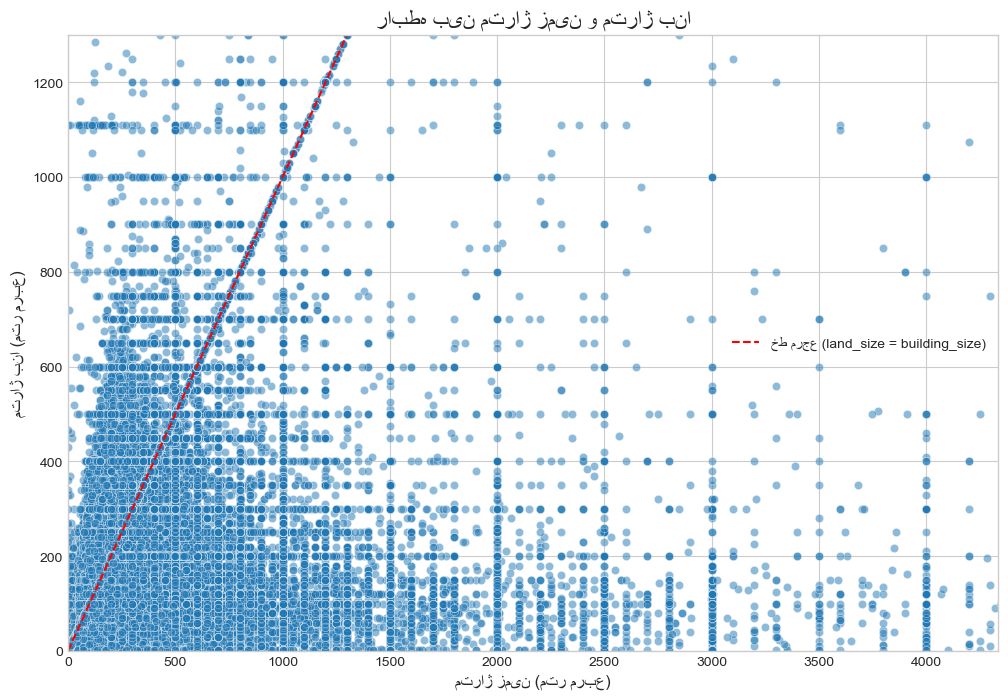

نمودار بالا رابطه بصری را نشان می‌دهد. تراکم نقاط و داده‌های پرت به خوبی مشخص است.

--- ۳. یافتن داده‌های متناقض (جایی که بنا از زمین بزرگتر است) ---
تعداد 27462 رکورد متناقض پیدا شد که در آن‌ها `building_size > land_size` است.
این موارد به احتمال زیاد خطای ورود داده هستند.
نمونه‌ای از این داده‌های متناقض:


,land_size,building_size,cat3_slug,cat2_slug,city_slug
364695,200.0,250.0,house-villa-sell,residential-sell,talesh
381477,80.0,150.0,house-villa-sell,residential-sell,rasht
975168,330.0,375.0,house-villa-sell,residential-sell,ramsar
198327,85.0,160.0,house-villa-sell,residential-sell,tabriz
872474,80.0,150.0,house-villa-sell,residential-sell,urmia
467275,200.0,280.0,house-villa-sell,residential-sell,tabriz
438199,350.0,380.0,house-villa-sell,residential-sell,nur
470335,300.0,450.0,house-villa-sell,residential-sell,isfahan
723215,545.0,650.0,house-villa-sell,residential-sell,hamedan
840460,90.0,250.0,house-villa-sell,residential-sell,urmia


In [121]:
corr_df = df_drop_nois_col[['land_size', 'building_size']].dropna()

# محاسبه ضریب همبستگی پیرسون
correlation = corr_df['land_size'].corr(corr_df['building_size'])

print("--- ۱. تحلیل ضریب همبستگی ---")
print(f"ضریب همبستگی بین land_size و building_size برابر است با: {correlation:.2f}\n")
if correlation > 0.7:
    print("نتیجه: همبستگی مثبت و قوی وجود دارد. همانطور که انتظار می‌رفت، با افزایش متراژ زمین، متراژ بنا نیز افزایش می‌یابد.")
elif correlation > 0.4:
    print("نتیجه: همبستگی مثبت و متوسطی وجود دارد.")
else:
    print("نتیجه: همبستگی مثبت ضعیفی وجود دارد یا همبستگی معنادار نیست.")

# --- مرحله ۲: تحلیل بصری با نمودار پراکندگی ---
print("\n--- ۲. ترسیم نمودار پراکندگی (Scatter Plot) ---")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

# از Seaborn برای رسم نمودار استفاده می‌کنیم که امکانات بیشتری دارد
sns.scatterplot(
    data=corr_df, 
    x='land_size', 
    y='building_size', 
    alpha=0.5,  # شفافیت نقاط برای دیدن تراکم
    ax=ax
)

# اضافه کردن خط y=x برای مقایسه بهتر
# تمام نقاط باید زیر این خط باشند (building_size <= land_size)
max_val = max(corr_df['land_size'].max(), corr_df['building_size'].max())
ax.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='خط مرجع (land_size = building_size)')

ax.set_title('رابطه بین متراژ زمین و متراژ بنا', fontsize=16)
ax.set_xlabel('متراژ زمین (متر مربع)', fontsize=12)
ax.set_ylabel('متراژ بنا (متر مربع)', fontsize=12)
ax.legend()
ax.set_xlim(0, corr_df['land_size'].quantile(0.99)) # محدود کردن محور برای دید بهتر و حذف اوت‌لایرهای شدید
ax.set_ylim(0, corr_df['building_size'].quantile(0.99)) # محدود کردن محور برای دید بهتر

plt.show()
print("نمودار بالا رابطه بصری را نشان می‌دهد. تراکم نقاط و داده‌های پرت به خوبی مشخص است.")


# --- مرحله ۳: بررسی منطقی و یافتن داده‌های متناقض ---
print("\n--- ۳. یافتن داده‌های متناقض (جایی که بنا از زمین بزرگتر است) ---")

# .query() یک روش خوانا برای فیلتر کردن دیتافریم است
inconsistent_data = df_clean_content.query('building_size > land_size')

if not inconsistent_data.empty:
    print(f"تعداد {len(inconsistent_data)} رکورد متناقض پیدا شد که در آن‌ها `building_size > land_size` است.")
    print("این موارد به احتمال زیاد خطای ورود داده هستند.")
    print("نمونه‌ای از این داده‌های متناقض:")
    # نمایش ۵ نمونه اول به همراه ستون‌های کلیدی برای بررسی
    display(inconsistent_data[['land_size', 'building_size', 'cat3_slug', 'cat2_slug', 'city_slug']].head(10))
else:
    print("✅ خبر خوب! هیچ رکوردی که در آن متراژ بنا از متراژ زمین بزرگتر باشد، یافت نشد.")

In [123]:
#حذف ردیف هایی که اصلا اندازه خانه ندارند.

# ابتدا ماسک برای املاک خانه و ویلا ایجاد می‌کنیم
house_villa_mask = df_drop_nois_col['cat3_slug'].isin(['house-villa-sell', 'house-villa-rent'])

# ماسک برای ردیف‌هایی که هر دو ستون خالی هستند
both_sizes_missing_mask = df_drop_nois_col['land_size'].isna() & df_drop_nois_col['building_size'].isna()

# ترکیب ماسک‌ها برای یافتن ردیف‌های ویلایی که هر دو اندازه را ندارند
rows_to_drop_mask = house_villa_mask & both_sizes_missing_mask

# شمارش تعداد ردیف‌هایی که حذف خواهند شد
num_rows_to_drop = rows_to_drop_mask.sum()
print(f"تعداد {num_rows_to_drop} ردیف از نوع خانه/ویلا که هر دو ستون land_size و building_size را ندارند، شناسایی و حذف خواهند شد.")

# حذف ردیف‌ها و به‌روزرسانی دیتافریم
df_clean_land_size = df_drop_nois_col[~rows_to_drop_mask]

print("ردیف‌های مورد نظر با موفقیت حذف شدند.")

تعداد 12 ردیف از نوع خانه/ویلا که هر دو ستون land_size و building_size را ندارند، شناسایی و حذف خواهند شد.
ردیف‌های مورد نظر با موفقیت حذف شدند.


<div style="
    background-color: var(--jp-layout-color1);
    border: 2px solid #FF9800;
    box-shadow: 0 0 10px rgba(255,152,0,0.2);
    padding: 20px;
    margin: 25px 0;
    border-radius: 8px;
    color: var(--jp-content-font-color1);
">

<p>
         جابجایی مقدارهای متراژ بنا و متراژ زمین برای مواردی که متناقض هستند، ینی زمین از بنا کوچکتر است
بنابراین با فرض اینکه بعضی از کاربران مقدار این ستونه ها را وارد کردند و بعضی را وارد نکردند، حذف می شود.
</p>
</div>




In [125]:
# ماسک برای شناسایی رکوردهای متناقض در کل دیتافریم
contradictory_mask = df_clean_land_size['building_size'] > df_clean_land_size['land_size']

# شمارش تعداد موارد متناقض
num_contradictory = contradictory_mask.sum()
print(f"تعداد {num_contradictory} رکورد متناقض که در آنها building_size > land_size است، شناسایی شد.")

# برای جابجایی، از یک متغیر موقت استفاده می‌کنیم یا به صورت پایتونیک عمل می‌کنیم
# df_clean_content.loc[contradictory_mask, ['land_size', 'building_size']] = \
#     df_clean_content.loc[contradictory_mask, ['building_size', 'land_size']].values

if num_contradictory > 0:
    df_clean_land_size.loc[contradictory_mask, ['land_size', 'building_size']] = \
        df_clean_land_size.loc[contradictory_mask, ['building_size', 'land_size']].values

    print(f"مقادیر {num_contradictory} رکورد متناقض با موفقیت جابجا شدند.")

    # تأیید نهایی: بررسی می‌کنیم که آیا هنوز ردیف متناقضی وجود دارد یا خیر
    remaining_contradictions = (df_clean_land_size['building_size'] > df_clean_land_size['land_size']).sum()
    print(f"تعداد رکوردهای متناقض باقی‌مانده پس از جابجایی: {remaining_contradictions}")

else:
    print("هیچ رکورد متناقضی برای جابجایی یافت نشد.")

تعداد 27462 رکورد متناقض که در آنها building_size > land_size است، شناسایی شد.
مقادیر 27462 رکورد متناقض با موفقیت جابجا شدند.
تعداد رکوردهای متناقض باقی‌مانده پس از جابجایی: 0


In [223]:
df_clean_land_size.shape

(976665, 54)

In [127]:
df_drop_cols =df_clean_land_size

<div style="
    background-color: var(--jp-layout-color1);
    border: 2px solid #FF9800;
    box-shadow: 0 0 10px rgba(255,152,0,0.2);
    padding: 20px;
    margin: 25px 0;
    border-radius: 8px;
    color: var(--jp-content-font-color1);
">
تا اینجا حدود 24 هزارتا رکورد بخاطر بی کیفیت بودن (یکی از فیچرهای عددی مقدار نداشته) ، تکراری بودن، مقدار لندسایز نداشتن حذف شدند.
همچنین 6 رکورد زیر نیز حذف شدند:



    'transformed_credit',
    'transformed_rent',
    'rent_credit_transform'
    'transformable_credit',
    'transformable_rent',
    'rent_to_single'
    

In [129]:
# تعیین آستانه حذف
threshold = 70.0

# 1. محاسبه درصد مقادیر گمشده به تفکیک هر مقدار در 'cat2_slug'
# --- اعمال اصلاحات برای حذف هشدارها ---
missing_pivot = df_drop_cols.groupby('cat2_slug', observed=True).apply(
    lambda x: (x.isnull().sum() / len(x)) * 100,
    include_groups=False # خود cat2_slug رو پاک میکنه
)


print("--- درصد مقادیر گمشده به تفکیک نوع معامله (Pivot Table) ---")
display(
    missing_pivot.style.background_gradient(cmap='Reds', axis=None, low=0, high=100)
                      .format("{:.2f}%")
                      .set_properties(**{'width': '100px'})
)

# ------------------------------------------------------------------
# بخش دوم کد برای پیدا کردن ستون‌های مشترک 
#--------------------

# 2. بررسی اینکه کدام ستون‌ها در "تمام" سطرها بالاتر از آستانه هستند
all_above_threshold = (missing_pivot > threshold).all(axis=0)

# 3. استخراج نام ستون‌هایی که شرط بالا را ارضا می‌کنند
common_useless_cols = all_above_threshold[all_above_threshold].index.tolist()

print(f"\n--- ستون‌های کاندیدای حذف (مقدار گمشده > {threshold}% در *تمام* انواع معامله) ---")
if common_useless_cols:
    print("لیست ستون‌های مشترک برای حذف:")
    for col in common_useless_cols:
        print(f"- {col}")
else:
    print("هیچ ستونی یافت نشد که در تمام دسته‌ها بالای آستانه باشد.")

--- درصد مقادیر گمشده به تفکیک نوع معامله (Pivot Table) ---


,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_type,price_mode,price_value,credit_mode,credit_value,transformable_price,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
cat2_slug,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
commercial-rent,0.00%,0.00%,51.56%,0.00%,76.30%,0.00%,0.00%,0.05%,0.64%,76.52%,99.96%,99.96%,0.05%,0.63%,0.00%,100.00%,0.04%,100.00%,100.00%,72.10%,0.52%,100.00%,100.00%,100.00%,72.08%,72.08%,72.08%,0.65%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,33.39%,33.39%,72.14%
commercial-sell,0.00%,0.00%,61.27%,0.00%,81.28%,0.00%,0.00%,99.99%,99.99%,99.99%,14.42%,17.26%,99.99%,99.99%,0.00%,100.00%,0.04%,100.00%,10.74%,86.72%,1.48%,100.00%,100.00%,100.00%,86.71%,86.71%,86.71%,1.70%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,34.19%,34.19%,74.88%
real-estate-services,0.00%,0.00%,53.57%,0.00%,4.98%,0.00%,0.00%,99.83%,99.83%,99.83%,0.17%,0.17%,99.83%,99.83%,0.00%,100.00%,99.50%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,38.21%,38.21%,16.36%
residential-rent,0.00%,0.00%,48.88%,0.00%,68.74%,0.00%,0.01%,0.00%,0.44%,68.87%,100.00%,100.00%,0.00%,0.16%,0.00%,76.62%,0.00%,100.00%,100.00%,23.47%,0.00%,57.60%,57.59%,31.29%,23.39%,0.00%,0.00%,0.00%,23.08%,98.05%,45.45%,98.05%,98.05%,47.27%,49.48%,42.07%,98.18%,98.15%,57.00%,98.20%,98.20%,98.21%,42.22%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,33.39%,33.39%,64.90%
residential-sell,0.00%,0.00%,59.50%,0.00%,69.95%,0.00%,0.00%,100.00%,100.00%,100.00%,3.27%,3.97%,100.00%,100.00%,0.00%,78.09%,0.00%,54.36%,100.00%,45.46%,23.47%,66.32%,66.72%,43.06%,45.39%,23.47%,23.47%,23.47%,43.00%,95.73%,58.82%,95.73%,95.73%,59.81%,62.01%,55.57%,96.01%,96.07%,63.07%,96.36%,96.46%,96.49%,55.66%,95.92%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,34.34%,34.34%,63.63%
temporary-rent,0.00%,0.00%,67.15%,0.00%,89.33%,0.00%,0.02%,99.99%,99.99%,99.99%,99.98%,99.98%,99.99%,99.99%,0.00%,100.00%,0.02%,100.00%,100.00%,100.00%,0.02%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,0.00%,100.00%,0.00%,0.00%,100.00%,100.00%,100.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,100.00%,0.00%,0.09%,19.62%,65.59%,39.38%,64.81%,54.50%,34.46%,34.46%,79.15%



--- ستون‌های کاندیدای حذف (مقدار گمشده > 70.0% در *تمام* انواع معامله) ---
لیست ستون‌های مشترک برای حذف:
- land_size


<div style="
    background-color: var(--jp-layout-color1);
    border: 2px solid #FF9800;
    box-shadow: 0 0 10px rgba(255,152,0,0.2);
    padding: 20px;
    margin: 25px 0;
    border-radius: 8px;
    color: var(--jp-content-font-color1);
">
    
**فیچر land_size بخاطر اهمیتش تو دسته آگهی های خانه و ویلا حذف نشد**

In [272]:
df_drop_cols.shape

(976665, 54)

In [131]:
df_drop_rows= df_drop_cols

<div style="
    background-color: var(--jp-layout-color1);
    border: 2px solid #FF9800;
    box-shadow: 0 0 10px rgba(255,152,0,0.2);
    padding: 20px;
    margin: 25px 0;
    border-radius: 8px;
    color: var(--jp-content-font-color1);
">
    
**حذف  اون رکوردهایی از نوع آگهی temporary-rent که rent_price_on_regular_days پر نشده**

In [133]:

# 1. ساخت ماسک (فیلتر) برای شناسایی ردیف‌هایی که باید حذف شوند
# شرط اول: نوع آگهی 'temporary-rent' باشد

print("--- وضعیت اولیه دیتافریم ---")
initial_rows = len(df_drop_rows)
print(f"تعداد کل ردیف‌ها: {initial_rows}")
print("-" * 30)

condition1 = df_drop_rows['cat2_slug'] == 'temporary-rent'

# شرط دوم: قیمت اجاره در روزهای عادی خالی (NaN) باشد
condition2 = df_drop_rows['rent_price_on_regular_days'].isna()

# ترکیب دو شرط: ردیف‌هایی که هر دو شرط را دارند
rows_to_drop_mask = condition1 & condition2


# شمارش تعداد ردیف‌هایی که حذف خواهند شد
num_rows_to_drop = rows_to_drop_mask.sum()

# 2. اجرای عملیات حذف (در صورتی که ردیفی برای حذف وجود داشته باشد)
if num_rows_to_drop > 0:
    print(f"شناسایی شد: {num_rows_to_drop} ردیف از نوع 'temporary-rent' با قیمت خالی.")
    
    # برای حذف، ما ردیف‌هایی را نگه می‌داریم که در ماسک ما مقدار True ندارند.
    # علامت ~ (tilde) ماسک را معکوس می‌کند (True ها را False و False ها را True می‌کند)
    df_drop_rows = df_drop_rows[~rows_to_drop_mask]
    
    print("ردیف‌های مورد نظر با موفقیت حذف شدند.")
else:
    print("هیچ ردیفی با شرایط مشخص شده برای حذف یافت نشد.")


# --- نمایش وضعیت نهایی دیتافریم ---
print("\n--- وضعیت نهایی دیتافریم ---")
final_rows = len(df_drop_rows)
print(f"تعداد ردیف‌های باقی‌مانده: {final_rows}")
print(f"تعداد کل ردیف‌های حذف شده: {initial_rows - final_rows}")
print("-" * 30)

# بازنشانی ایندکس‌ها (اختیاری اما توصیه می‌شود)
df_drop_rows = df_drop_rows.reset_index(drop=True)
print("ایندکس‌های دیتافریم بازنشانی شد.")

--- وضعیت اولیه دیتافریم ---
تعداد کل ردیف‌ها: 976665
------------------------------
شناسایی شد: 11672 ردیف از نوع 'temporary-rent' با قیمت خالی.
ردیف‌های مورد نظر با موفقیت حذف شدند.

--- وضعیت نهایی دیتافریم ---
تعداد ردیف‌های باقی‌مانده: 964993
تعداد کل ردیف‌های حذف شده: 11672
------------------------------
ایندکس‌های دیتافریم بازنشانی شد.


In [260]:
df_drop_rows.shape

(964993, 54)

<div style="
    background-color: var(--jp-layout-color1);
    border: 2px solid #FF9800;
    box-shadow: 0 0 10px rgba(255,152,0,0.2);
    padding: 20px;
    margin: 25px 0;
    border-radius: 8px;
    color: var(--jp-content-font-color1);
">
    
**نوع آگهی 'commercial-rent' یا 'residential-rent' باشد**

In [135]:


print("--- وضعیت اولیه دیتافریم ---")
initial_rows = len(df_drop_rows)
print(f"تعداد کل ردیف‌ها: {initial_rows}")
print("-" * 30)


condition_category = df_drop_rows['cat2_slug'].isin(['commercial-rent', 'residential-rent'])

# شرط دوم: مقدار rent_value خالی باشد
condition_rent_null = df_drop_rows['rent_value'].isna()

# شرط سوم: مقدار df_drop_rows خالی باشد
condition_credit_null = df_drop_rows['credit_value'].isna()

# ترکیب شرایط: ردیف‌هایی که شرط اول را دارند (نوع آگهی درست است)
# و (AND) یکی از شروط دوم یا سوم را هم دارند (حداقل یکی از مقادیر قیمت خالی است)
# نکته مهم: حتماً از پرانتز برای جداسازی منطق OR و AND استفاده کنید.
rows_to_drop_mask = condition_category & (condition_rent_null | condition_credit_null)

# شمارش تعداد ردیف‌هایی که حذف خواهند شد
num_rows_to_drop = rows_to_drop_mask.sum()


# 2. اجرای عملیات حذف
if num_rows_to_drop > 0:
    print(f"شناسایی شد: {num_rows_to_drop} ردیف از نوع commercial/residential rent با مقادیر رهن/اجاره خالی.")
    
    # ردیف‌هایی را نگه می‌داریم که در ماسک حذف ما قرار ندارند (معکوس کردن ماسک با ~)
    df_drop_rows = df_drop_rows[~rows_to_drop_mask]
    
    print("ردیف‌های مورد نظر با موفقیت حذف شدند.")
else:
    print("هیچ ردیفی با شرایط مشخص شده برای حذف یافت نشد.")


# --- نمایش وضعیت نهایی دیتافریم ---
print("\n--- وضعیت نهایی دیتافریم ---")
final_rows = len(df_drop_rows)
print(f"تعداد ردیف‌های باقی‌مانده: {final_rows}")
print(f"تعداد کل ردیف‌های حذف شده در این مرحله: {initial_rows - final_rows}")
print("-" * 30)

# بازنشانی ایندکس‌ها (بسیار مهم پس از حذف ردیف‌ها)
df_drop_rows = df_drop_rows.reset_index(drop=True)
print("ایندکس‌های دیتافریم بازنشانی شد.")

--- وضعیت اولیه دیتافریم ---
تعداد کل ردیف‌ها: 964993
------------------------------
شناسایی شد: 1839 ردیف از نوع commercial/residential rent با مقادیر رهن/اجاره خالی.
ردیف‌های مورد نظر با موفقیت حذف شدند.

--- وضعیت نهایی دیتافریم ---
تعداد ردیف‌های باقی‌مانده: 963154
تعداد کل ردیف‌های حذف شده در این مرحله: 1839
------------------------------
ایندکس‌های دیتافریم بازنشانی شد.


<div style="
    background-color: var(--jp-layout-color1);
    border: 2px solid #FF9800;
    box-shadow: 0 0 10px rgba(255,152,0,0.2);
    padding: 20px;
    margin: 25px 0;
    border-radius: 8px;
    color: var(--jp-content-font-color1);
">
    
**نوع آگهی     'commercial-sell',
    'real-estate-services',
    'residential-sell'
 باشد**

In [137]:
print("--- وضعیت اولیه دیتافریم ---")
initial_rows = len(df_drop_rows)
print(f"تعداد کل ردیف‌ها: {initial_rows}")
print("-" * 30)


# 1. تعریف شرایط برای شناسایی ردیف‌هایی که باید حذف شوند

# شرط اول: نوع آگهی یکی از موارد فروش باشد
categories_to_check = [
    'commercial-sell',
    'real-estate-services',
    'residential-sell'
]
condition_category = df_drop_rows['cat2_slug'].isin(categories_to_check)

# شرط دوم: مقدار price_value خالی (NaN) باشد
condition_price_null = df_drop_rows['price_value'].isna()

# ترکیب دو شرط: ردیف‌هایی که در دسته‌بندی فروش هستند و (AND) قیمت ندارند
rows_to_drop_mask = condition_category & condition_price_null

# شمارش تعداد ردیف‌هایی که حذف خواهند شد
num_rows_to_drop = rows_to_drop_mask.sum()


# 2. اجرای عملیات حذف
if num_rows_to_drop > 0:
    print(f"شناسایی شد: {num_rows_to_drop} ردیف از نوع آگهی فروش که مقدار 'price_value' ندارند.")
    
    # ردیف‌هایی را نگه می‌داریم که در ماسک حذف قرار ندارند (با معکوس کردن ماسک ~)
    df_drop_rows = df_drop_rows[~rows_to_drop_mask]
    
    print("ردیف‌های مورد نظر با موفقیت حذف شدند.")
else:
    print("هیچ ردیفی با شرایط مشخص شده برای حذف یافت نشد.")


# --- نمایش وضعیت نهایی دیتافریم ---
print("\n--- وضعیت نهایی دیتافریم ---")
final_rows = len(df_drop_rows)
print(f"تعداد ردیف‌های باقی‌مانده: {final_rows}")
print(f"تعداد کل ردیف‌های حذف شده در این مرحله: {initial_rows - final_rows}")
print("-" * 30)

# بازنشانی ایندکس‌ها برای حفظ یکپارچگی دیتافریم
df_drop_rows = df_drop_rows.reset_index(drop=True)
print("ایندکس‌های دیتافریم بازنشانی شد.")

--- وضعیت اولیه دیتافریم ---
تعداد کل ردیف‌ها: 963154
------------------------------
شناسایی شد: 28703 ردیف از نوع آگهی فروش که مقدار 'price_value' ندارند.
ردیف‌های مورد نظر با موفقیت حذف شدند.

--- وضعیت نهایی دیتافریم ---
تعداد ردیف‌های باقی‌مانده: 934451
تعداد کل ردیف‌های حذف شده در این مرحله: 28703
------------------------------
ایندکس‌های دیتافریم بازنشانی شد.


In [139]:
# تعیین آستانه حذف
threshold = 70.0

# 1. محاسبه درصد مقادیر گمشده به تفکیک هر مقدار در 'cat2_slug'
# --- اعمال اصلاحات برای حذف هشدارها ---
missing_pivot = df_drop_rows.groupby('cat2_slug', observed=True).apply(
    lambda x: (x.isnull().sum() / len(x)) * 100,
    include_groups=False # خود cat2_slug رو پاک میکنه
)


print("--- درصد مقادیر گمشده به تفکیک نوع معامله (Pivot Table) ---")
display(
    missing_pivot.style.background_gradient(cmap='Reds', axis=None, low=0, high=100)
                      .format("{:.2f}%")
                      .set_properties(**{'width': '100px'})
)

# ------------------------------------------------------------------
# بخش دوم کد برای پیدا کردن ستون‌های مشترک 
#--------------------

# 2. بررسی اینکه کدام ستون‌ها در "تمام" سطرها بالاتر از آستانه هستند
all_above_threshold = (missing_pivot > threshold).all(axis=0)

# 3. استخراج نام ستون‌هایی که شرط بالا را ارضا می‌کنند
common_useless_cols = all_above_threshold[all_above_threshold].index.tolist()



--- درصد مقادیر گمشده به تفکیک نوع معامله (Pivot Table) ---


,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_type,price_mode,price_value,credit_mode,credit_value,transformable_price,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
cat2_slug,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
commercial-rent,0.00%,0.00%,51.60%,0.00%,76.82%,0.00%,0.00%,0.00%,0.00%,77.01%,100.00%,100.00%,0.00%,0.00%,0.00%,100.00%,0.00%,100.00%,100.00%,72.14%,0.39%,100.00%,100.00%,100.00%,72.13%,72.13%,72.13%,0.51%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,33.00%,33.00%,72.32%
commercial-sell,0.00%,0.00%,60.78%,0.00%,80.82%,0.00%,0.00%,100.00%,100.00%,100.00%,0.00%,0.00%,100.00%,100.00%,0.00%,100.00%,0.04%,100.00%,11.03%,86.06%,1.10%,100.00%,100.00%,100.00%,86.05%,86.05%,86.05%,1.30%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,33.63%,33.63%,74.60%
real-estate-services,0.00%,0.00%,53.49%,0.00%,4.99%,0.00%,0.00%,100.00%,100.00%,100.00%,0.00%,0.00%,100.00%,100.00%,0.00%,100.00%,99.50%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,38.19%,38.19%,16.39%
residential-rent,0.00%,0.00%,48.92%,0.00%,69.06%,0.00%,0.01%,0.00%,0.00%,69.18%,100.00%,100.00%,0.00%,0.00%,0.00%,76.60%,0.00%,100.00%,100.00%,23.49%,0.00%,57.57%,57.56%,31.25%,23.40%,0.00%,0.00%,0.00%,22.81%,98.04%,45.39%,98.04%,98.04%,47.19%,49.42%,42.00%,98.18%,98.15%,56.95%,98.19%,98.19%,98.20%,42.15%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,33.15%,33.15%,64.92%
residential-sell,0.00%,0.00%,58.57%,0.00%,69.43%,0.00%,0.00%,100.00%,100.00%,100.00%,0.00%,0.00%,100.00%,100.00%,0.00%,77.18%,0.00%,52.48%,100.00%,43.21%,20.31%,64.93%,65.35%,40.71%,43.13%,20.31%,20.31%,20.31%,40.64%,95.56%,57.11%,95.56%,95.56%,58.15%,60.44%,53.73%,95.84%,95.91%,61.54%,96.21%,96.31%,96.35%,53.82%,95.75%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,34.34%,34.34%,63.25%
temporary-rent,0.00%,0.00%,65.64%,0.00%,90.88%,0.00%,0.01%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,0.00%,100.00%,0.00%,100.00%,100.00%,100.00%,0.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,0.00%,100.00%,0.00%,0.00%,100.00%,100.00%,100.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,16.65%,45.95%,0.00%,42.59%,25.69%,31.03%,31.03%,80.81%


<div style="
    background-color: var(--jp-layout-color1);
    border: 2px solid #FF9800;
    box-shadow: 0 0 10px rgba(255,152,0,0.2);
    padding: 20px;
    margin: 25px 0;
    border-radius: 8px;
    color: var(--jp-content-font-color1);
">



تا به اینجا تمام رکوردهایی که مقدار اصلی آنها در دسته آگهی خودشان یعنی قیمت فرش/رهن/اجاره را نداشتند، حذف شدند.

<div style="
    background-color: var(--jp-layout-color1);
    border: 2px solid #FF9800;
    box-shadow: 0 0 10px rgba(255,152,0,0.2);
    padding: 20px;
    margin: 25px 0;
    border-radius: 8px;
    color: var(--jp-content-font-color1);
">
    <h3 style="margin-top: 0; color: var(--jp-content-font-color0);">پر کردن مقادیر خالی:</h3>

</div>





In [143]:
df_filled_nulls = df_drop_rows

In [145]:
# لیست ستون‌هایی که می‌خواهیم تغییر دهیم
boolean_cols_residential = [
    'has_barbecue',
    'has_security_guard',
    'has_balcony',
    'has_elevator',
    'has_warehouse',
    'has_parking'
]

# --- مرحله ۱: بررسی وضعیت فعلی (قبل از تغییر) ---
print("--- وضعیت قبل از تغییر ---")
# ایجاد شرط برای انتخاب فقط ردیف‌های مسکونی
residential_categories = ['residential-rent', 'residential-sell']
residential_mask = df_filled_nulls['cat2_slug'].isin(residential_categories)

# نمایش تعداد مقادیر گمشده در ستون‌های هدف، فقط برای آگهی‌های مسکونی
print("تعداد مقادیر گمشده در ستون‌های هدف (فقط برای آگهی‌های مسکونی):")
print(df_filled_nulls.loc[residential_mask, boolean_cols_residential].isnull().sum())
print("-" * 30)


# --- مرحله ۲: اجرای عملیات جایگزینی ---
# برای هر ستون در لیست، مقادیر NaN را در ردیف‌های مسکونی با False پر می‌کنیم
for col in boolean_cols_residential:
    # استفاده از .loc برای اطمینان از اینکه تغییرات در دیتافریم اصلی اعمال می‌شود
    df_filled_nulls.loc[residential_mask, col] = df_filled_nulls.loc[residential_mask, col].fillna(False)

print("\nعملیات جایگزینی با 'False' برای آگهی‌های مسکونی با موفقیت انجام شد.\n")


# --- مرحله ۳: تایید نتیجه (بعد از تغییر) ---
print("--- وضعیت بعد از تغییر ---")
print("تعداد مقادیر گمشده در ستون‌های هدف (فقط برای آگهی‌های مسکونی):")
# این بخش باید برای تمام ستون‌ها عدد صفر را نشان دهد
print(df_filled_nulls.loc[residential_mask, boolean_cols_residential].isnull().sum())
print("-" * 30)

# بررسی اینکه آیا مقادیر گمشده در آگهی‌های غیرمسکونی هنوز وجود دارند یا خیر
# این کار برای اطمینان از این است که فقط ردیف‌های مسکونی تحت تأثیر قرار گرفته‌اند
non_residential_mask = ~residential_mask
print("\nتعداد مقادیر گمشده در ستون‌های هدف (برای آگهی‌های غیرمسکونی):")
print(df_filled_nulls.loc[non_residential_mask, boolean_cols_residential].isnull().sum())

--- وضعیت قبل از تغییر ---
تعداد مقادیر گمشده در ستون‌های هدف (فقط برای آگهی‌های مسکونی):
has_barbecue          780549
has_security_guard    780269
has_balcony           302689
has_elevator          293980
has_warehouse         108145
has_parking           108145
dtype: int64
------------------------------

عملیات جایگزینی با 'False' برای آگهی‌های مسکونی با موفقیت انجام شد.

--- وضعیت بعد از تغییر ---
تعداد مقادیر گمشده در ستون‌های هدف (فقط برای آگهی‌های مسکونی):
has_barbecue          0
has_security_guard    0
has_balcony           0
has_elevator          0
has_warehouse         0
has_parking           0
dtype: int64
------------------------------

تعداد مقادیر گمشده در ستون‌های هدف (برای آگهی‌های غیرمسکونی):
has_barbecue          109049
has_security_guard    109049
has_balcony           127020
has_elevator          101420
has_warehouse         101420
has_parking           101420
dtype: int64


In [147]:
 #لیست ستون‌هایی که می‌خواهیم با دسته جدید پر کنیم
categorical_cols_to_fill = [
    'has_cooling_system',
    'has_heating_system',
    'has_warm_water_provider'
]
new_category = 'not_specified'

# --- ایجاد ماسک صحیح برای انتخاب ردیف‌های مسکونی ---
# استفاده از .isin برای انتخاب دقیق دسته‌های مورد نظر
residential_categories = ['residential-rent', 'residential-sell']
residential_mask = df_filled_nulls['cat2_slug'].isin(residential_categories)

print("--- وضعیت قبل از تغییر ---")
# نمایش نوع داده و توزیع مقادیر برای ستون‌های هدف
for col in categorical_cols_to_fill:
    print(f"\nستون: '{col}'")
    # بررسی اینکه آیا ستون از نوع Categorical است یا خیر
    if isinstance(df_filled_nulls[col].dtype, pd.CategoricalDtype):
        print(f"  نوع داده فعلی: Categorical")
        print(f"  دسته‌های موجود: {df_filled_nulls[col].cat.categories.tolist()}")
    else:
        print(f"  نوع داده فعلی: {df_filled_nulls[col].dtype}")
    
    print("  تعداد مقادیر گمشده (فقط برای آگهی‌های مسکونی):")
    print(f"    {df_filled_nulls.loc[residential_mask, col].isnull().sum()}")
print("-" * 50)


# --- مرحله ۱: اضافه کردن دسته جدید به ستون‌های Categorical ---
print("\n>>> شروع فرآیند اصلاح ستون‌ها...\n")
for col in categorical_cols_to_fill:
    # ابتدا بررسی می‌کنیم که ستون از نوع Categorical باشد
    if isinstance(df_filled_nulls[col].dtype, pd.CategoricalDtype):
        # بررسی می‌کنیم که آیا دسته جدید از قبل وجود دارد یا نه
        if new_category not in df_filled_nulls[col].cat.categories:
            print(f"اضافه کردن دسته '{new_category}' به ستون '{col}'...")
            # استفاده از add_categories برای اضافه کردن دسته جدید
            df_filled_nulls[col] = df_filled_nulls[col].cat.add_categories([new_category])
        else:
             print(f"دسته '{new_category}' از قبل در ستون '{col}' وجود دارد.")
    # اگر ستون از نوع Categorical نباشد، نیازی به این کار نیست و fillna به درستی کار خواهد کرد
    # اما برای اطمینان می‌توانیم آن را به Categorical تبدیل کنیم
    else:
        print(f"ستون '{col}' از نوع Categorical نیست. در صورت نیاز تبدیل خواهد شد.")


# --- مرحله ۲: اجرای عملیات جایگزینی (fillna) ---
# این بخش حالا بدون خطا اجرا خواهد شد
df_filled_nulls.loc[residential_mask, categorical_cols_to_fill] = \
    df_filled_nulls.loc[residential_mask, categorical_cols_to_fill].fillna(new_category)

print(f"\nعملیات جایگزینی با '{new_category}' با موفقیت انجام شد.\n")


# --- مرحله ۳: تایید نتیجه (بعد از تغییر) ---
print("--- وضعیت بعد از تغییر ---")
for col in categorical_cols_to_fill:
    print(f"\nستون: '{col}'")
    if isinstance(df_filled_nulls[col].dtype, pd.CategoricalDtype):
        print(f"  نوع داده: Categorical")
        print(f"  دسته‌های جدید: {df_filled_nulls[col].cat.categories.tolist()}")
    else:
         print(f"  نوع داده جدید: {df_filled_nulls[col].dtype}")

    print("  توزیع مقادیر (فقط برای آگهی‌های مسکونی):")
    # حالا باید دسته 'not specified' را به جای NaN ببینیم
    print(df_filled_nulls.loc[residential_mask, col].value_counts(dropna=False))
print("-" * 50)

--- وضعیت قبل از تغییر ---

ستون: 'has_cooling_system'
  نوع داده فعلی: Categorical
  دسته‌های موجود: ['air_conditioner', 'duct_split', 'fan_coil', 'split', 'unselect', 'water_cooler']
  تعداد مقادیر گمشده (فقط برای آگهی‌های مسکونی):
    457707

ستون: 'has_heating_system'
  نوع داده فعلی: Categorical
  دسته‌های موجود: ['duct_split', 'fan_coil', 'fireplace', 'floor_heating', 'heater', 'shoofaj', 'split', 'unselect']
  تعداد مقادیر گمشده (فقط برای آگهی‌های مسکونی):
    439386

ستون: 'has_warm_water_provider'
  نوع داده فعلی: Categorical
  دسته‌های موجود: ['package', 'powerhouse', 'unselect', 'water_heater']
  تعداد مقادیر گمشده (فقط برای آگهی‌های مسکونی):
    428909
--------------------------------------------------

>>> شروع فرآیند اصلاح ستون‌ها...

اضافه کردن دسته 'not_specified' به ستون 'has_cooling_system'...
اضافه کردن دسته 'not_specified' به ستون 'has_heating_system'...
اضافه کردن دسته 'not_specified' به ستون 'has_warm_water_provider'...

عملیات جایگزینی با 'not_specified' با موفقی

In [149]:
# پر کردن سال ساخت با چارک سوم 

q1_year = df_filled_nulls['construction_year'].quantile(0.25)
df_filled_nulls['construction_year'].fillna(q1_year, inplace=True)
print(f"مقادیر گمشده 'construction_year' با صدک ۲۵ ({int(q1_year)}) پر شدند.")

مقادیر گمشده 'construction_year' با صدک ۲۵ (1390) پر شدند.


In [106]:
# پر کردن تعداد اتاق و اندازه ساختمان

# ۱.۲: ستون‌هایی که قرار است به صورت هوشمند پر شوند را مشخص می‌کنیم
# تمام ستون‌های عددی که ممکن است با هم ارتباط داشته باشند
cols_to_impute = ['building_size', 'rooms_count']
df_to_impute = df_filled_nulls[cols_to_impute]

# ۱.۳: ساخت و اجرای IterativeImputer
# max_iter=10 یعنی الگوریتم ۱۰ دور کامل روی داده‌ها می‌چرخد تا مقادیر بهینه شوند
imputer = IterativeImputer(max_iter=10, random_state=42)

# اجرای الگوریتم (fit_transform)
imputed_data = imputer.fit_transform(df_to_impute)

# ۱.۴: جایگزینی داده‌های پر شده در دیتافریم اصلی
# خروجی imputer یک آرایه NumPy است، آن را به دیتافریم تبدیل می‌کنیم
df_imputed = pd.DataFrame(imputed_data, columns=cols_to_impute, index=df_filled_nulls.index)

df_imputed['rooms_count'] = df_imputed['rooms_count'].round().astype(int)

# مقادیر پر شده را در دیتافریم اصلی به‌روزرسانی می‌کنیم
df_filled_nulls.update(df_imputed)

print("مقادیر گمشده متراژ بنا و تعداد اتاق با استفاده از روش Iterative Imputer پر شدند.")



مقادیر گمشده متراژ بنا و تعداد اتاق با استفاده از روش Iterative Imputer پر شدند.


In [108]:
# تعیین آستانه حذف
threshold = 70.0

# 1. محاسبه درصد مقادیر گمشده به تفکیک هر مقدار در 'cat2_slug'
# --- اعمال اصلاحات برای حذف هشدارها ---
missing_pivot = df_filled_nulls.groupby('cat2_slug', observed=True).apply(
    lambda x: (x.isnull().sum() / len(x)) * 100,
    include_groups=False # خود cat2_slug رو پاک میکنه
)


print("--- درصد مقادیر گمشده به تفکیک نوع معامله (Pivot Table) ---")
display(
    missing_pivot.style.background_gradient(cmap='Reds', axis=None, low=0, high=100)
                      .format("{:.2f}%")
                      .set_properties(**{'width': '100px'})
)

# ------------------------------------------------------------------
# بخش دوم کد برای پیدا کردن ستون‌های مشترک 
#--------------------

# 2. بررسی اینکه کدام ستون‌ها در "تمام" سطرها بالاتر از آستانه هستند
all_above_threshold = (missing_pivot > threshold).all(axis=0)

# 3. استخراج نام ستون‌هایی که شرط بالا را ارضا می‌کنند
common_useless_cols = all_above_threshold[all_above_threshold].index.tolist()



--- درصد مقادیر گمشده به تفکیک نوع معامله (Pivot Table) ---


,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_type,price_mode,price_value,credit_mode,credit_value,transformable_price,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
cat2_slug,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
commercial-rent,0.00%,0.00%,51.60%,0.00%,76.82%,0.00%,0.00%,0.00%,0.00%,77.01%,100.00%,100.00%,0.00%,0.00%,0.00%,100.00%,0.00%,100.00%,100.00%,72.14%,0.00%,100.00%,100.00%,100.00%,72.13%,72.13%,72.13%,0.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,33.00%,33.00%,72.32%
commercial-sell,0.00%,0.00%,60.78%,0.00%,80.82%,0.00%,0.00%,100.00%,100.00%,100.00%,0.00%,0.00%,100.00%,100.00%,0.00%,100.00%,0.00%,100.00%,11.03%,86.06%,0.00%,100.00%,100.00%,100.00%,86.05%,86.05%,86.05%,0.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,33.63%,33.63%,74.60%
real-estate-services,0.00%,0.00%,53.49%,0.00%,4.99%,0.00%,0.00%,100.00%,100.00%,100.00%,0.00%,0.00%,100.00%,100.00%,0.00%,100.00%,0.00%,100.00%,100.00%,100.00%,0.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,0.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,38.19%,38.19%,16.39%
residential-rent,0.00%,0.00%,48.92%,0.00%,69.06%,0.00%,0.01%,0.00%,0.00%,69.18%,100.00%,100.00%,0.00%,0.00%,0.00%,76.60%,0.00%,100.00%,100.00%,23.49%,0.00%,57.57%,57.56%,0.00%,0.00%,0.00%,0.00%,0.00%,22.81%,98.04%,0.00%,98.04%,98.04%,0.00%,0.00%,42.00%,0.00%,0.00%,56.95%,98.19%,98.19%,98.20%,42.15%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,33.15%,33.15%,64.92%
residential-sell,0.00%,0.00%,58.57%,0.00%,69.43%,0.00%,0.00%,100.00%,100.00%,100.00%,0.00%,0.00%,100.00%,100.00%,0.00%,77.18%,0.00%,52.48%,100.00%,43.21%,0.00%,64.93%,65.35%,0.00%,0.00%,0.00%,0.00%,0.00%,40.64%,95.56%,0.00%,95.56%,95.56%,0.00%,0.00%,53.73%,0.00%,0.00%,61.54%,96.21%,96.31%,96.35%,53.82%,95.75%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,34.34%,34.34%,63.25%
temporary-rent,0.00%,0.00%,65.64%,0.00%,90.88%,0.00%,0.01%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,0.00%,100.00%,0.00%,100.00%,100.00%,100.00%,0.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,0.00%,100.00%,0.00%,100.00%,0.00%,0.00%,100.00%,100.00%,100.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,16.65%,45.95%,0.00%,42.59%,25.69%,31.03%,31.03%,80.81%


<hr style="border: 2px solid #FF9800; border-radius: 2px;">


▶️ **شروع: مدیریت مقادیر 
    پرت**
---

In [169]:
df_cleand_outliers = df_filled_nulls

In [159]:
df_cleand_outliers.describe().T

,count,mean,std,min,25%,50%,75%,max
rent_value,350788.0,41085249725.451683,3810431011122.503906,0.0,111111.0,5000000.0,12000000.0,999999999999999.0
price_value,565692.0,17416303170.222176,589226057368.363525,0.0,1400000000.0,2850000000.0,5900000000.0,99999999999999.0
credit_value,350788.0,48897398127.831627,4349424918943.007324,0.0,100000000.0,250000000.0,500000000.0,999999999999999.0
land_size,185824.0,6149.102613,154395.38626,1.0,120.0,200.0,300.0,10000000.0
building_size,933232.0,2584.345843,101727.419233,1.0,75.0,100.0,153.0,10000000.0
floor,538380.0,2.70086,2.205545,-1.0,1.0,2.0,4.0,30.0
rooms_count,824455.0,1.880909,1.036202,0.0,1.0,2.0,2.0,6.0
total_floors_count,303424.0,4.845889,2.844792,2.0,4.0,4.0,5.0,31.0
unit_per_floor,301229.0,2.270326,1.440637,1.0,1.0,2.0,3.0,9.0
construction_year,934451.0,1393.275277,7.833519,1369.0,1390.0,1394.0,1400.0,1403.0


In [171]:

# تعریف آستانه‌های منطقی 
thresholds = {
    'price_value': 200_000_000_000,
    'rent_value': 200_000_000,
    'credit_value': 5_000_000_000,
    'cost_per_extra_person': 1_000_000,
    'rent_price_on_regular_days': 50_000_000,
    'rent_price_at_weekends': 70_000_000,
    'building_size': 2000,
    'land_size': 10_000
}

print(f"تعداد رکوردها قبل از پاکسازی: {len(df_cleand_outliers)}")

# 2. ایجاد حلقه برای اعمال فیلترها
# این حلقه به ازای هر آیتم در دیکشنری یک بار اجرا می‌شود
for column, upper_bound in thresholds.items():
    # تعداد رکوردهای قبل از فیلتر این ستون
    rows_before = len(df_cleand_outliers)
    
    # اعمال فیلتر: فقط سطرهایی را نگه دار که مقدارشان در این ستون کمتر از آستانه است
    df_cleand_outliers = df_cleand_outliers[df_cleand_outliers[column] < upper_bound]
    
    # تعداد رکوردهای حذف شده توسط این فیلتر
    rows_removed = rows_before - len(df_cleand_outliers)
    if rows_removed > 0:
        print(f"فیلتر ستون '{column}': {rows_removed} سطر پرت حذف شد.")

print(f"\nتعداد رکوردها بعد از پاکسازی نهایی: {len(df_cleand_outliers)}")

# نمایش دیتافریم پاکسازی شده
print("\nدیتافریم پس از حذف مقادیر پرت:")
display(df_cleand_outliers)


تعداد رکوردها قبل از پاکسازی: 934451
فیلتر ستون 'price_value': 370698 سطر پرت حذف شد.
فیلتر ستون 'rent_value': 563753 سطر پرت حذف شد.

تعداد رکوردها بعد از پاکسازی نهایی: 0

دیتافریم پس از حذف مقادیر پرت:


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius


In [ ]:
file_path = 'cleaned_real_estate_data.pkl'

# خواندن آبجکت از فایل Pickle
df_loaded = pd.read_pickle(file_path)

print("دیتافریم با موفقیت بارگذاری شد!")
print("\nاطلاعات دیتافریم بارگذاری شده:")

In [11]:
df_cleand_outliers = df_loaded 

In [25]:

df_to_analyze = df_cleand_outliers.copy()

# ایجاد جدول تقاطعی برای مشاهده توزیع داده‌ها
# fill_na=0 باعث می‌شود ترکیباتی که وجود ندارند با عدد صفر پر شوند
crosstab_result = pd.crosstab(
    index=df_to_analyze['cat3_slug'],      # مقادیر این ستون، سطرهای جدول را تشکیل می‌دهند
    columns=df_to_analyze['cat2_slug'],  # مقادیر این ستون، ستون‌های جدول را تشکیل می‌دهند
    margins=True,                         # یک سطر و ستون "All" برای نمایش مجموع اضافه می‌کند
    margins_name="Total Count",           # نام سطر/ستون مجموع
    dropna=False                          # دسته‌هایی که NaN هستند را هم نمایش می‌دهد
)

print("--- جدول توزیع انواع ملک بر اساس نوع معامله ---")
print(crosstab_result)


--- جدول توزیع انواع ملک بر اساس نوع معامله ---
cat2_slug                           commercial-rent  commercial-sell  \
cat3_slug                                                              
apartment-rent                                    0                0   
apartment-sell                                    0                0   
house-villa-rent                                  0                0   
house-villa-sell                                  0                0   
industry-agriculture-business-rent             9001                0   
industry-agriculture-business-sell                0             9063   
office-rent                                   21128                0   
office-sell                                       0             4471   
partnership                                       0                0   
plot-old                                          0                0   
presell                                           0                0   
shop-rent       

In [31]:

df = df_cleand_outliers.copy()
print(f"تعداد کل رکوردها در شروع: {len(df)}\n")

# --- گام ۱: تعریف دسته‌بندی‌ها بر اساس تحلیل Crosstab ---

# دسته‌بندی نوع معامله
sell_categories = ['commercial-sell', 'residential-sell']
rent_categories = ['commercial-rent', 'residential-rent', 'temporary-rent']

# دسته‌بندی نوع ملک (بر اساس cat3_slug)
APARTMENT_CATEGORIES = ['apartment-rent', 'apartment-sell', 'suite-apartment']
VILLA_CATEGORIES = ['house-villa-rent', 'house-villa-sell', 'villa']
LAND_CATEGORIES = ['plot-old']
COMMERCIAL_CATEGORIES = [
    'industry-agriculture-business-rent', 'industry-agriculture-business-sell',
    'office-rent', 'office-sell', 'shop-rent', 'shop-sell', 'workspace'
]

# --- گام ۲: تفکیک اولیه دیتافریم بر اساس نوع معامله ---
df_rent = df[df['cat2_slug'].isin(rent_categories)].copy()
df_sell = df[df['cat2_slug'].isin(sell_categories)].copy()
df_other = df[~df['cat2_slug'].isin(rent_categories) & ~df['cat2_slug'].isin(sell_categories)].copy()



# تابع پاکسازی 
  #  با استفاده از تبدیل لگاریتمی و روش IQR، سطرهای پرت را حذف می‌کند.
  #  این روش برای داده‌های چوله (Skewed) بسیار مناسب است.
   
def remove_outliers_log_iqr(dataframe, columns, k=1.5):
    df_cleaned = dataframe.copy()
    if df_cleaned.empty:
        return df_cleaned
    for col in columns:
        if col not in df_cleaned.columns or not pd.api.types.is_numeric_dtype(df_cleaned[col]) or df_cleaned[col].isnull().all():
            continue
        rows_before = len(df_cleaned)
        log_transformed_col = np.log1p(df_cleaned[col].fillna(0))
        Q1_log = log_transformed_col.quantile(0.25)
        Q3_log = log_transformed_col.quantile(0.75)
        IQR_log = Q3_log - Q1_log
        if IQR_log == 0: continue
        lower_bound_log = Q1_log - k * IQR_log
        upper_bound_log = Q3_log + k * IQR_log
        lower_bound = np.expm1(lower_bound_log)
        upper_bound = np.expm1(upper_bound_log)
        lower_bound = max(0, lower_bound)
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
        rows_removed = rows_before - len(df_cleaned)
        if rows_removed > 0:
            print(f"  - ستون '{col}': {rows_removed} سطر پرت حذف شد (مرز بالا: {upper_bound:,.0f}).")
    return df_cleaned

# --- گام ۳: تفکیک ثانویه و پاکسازی هدفمند ---

# ضریب حساسیت را می‌توانیم به مقدار استاندارد 1.5 برگردانیم
K_FACTOR = 1.5
cleaned_dfs_list = []

# --- الف) پردازش داده‌های فروش (SELL) ---
print("--- شروع پاکسازی هدفمند داده‌های فروش ---")
# 1. آپارتمان‌های فروشی
df_sell_apt = df_sell[df_sell['cat3_slug'].isin(APARTMENT_CATEGORIES)].copy()
print(f"\n1. پاکسازی آپارتمان‌های فروشی ({len(df_sell_apt)} رکورد):")
cleaned_dfs_list.append(remove_outliers_log_iqr(df_sell_apt, columns=['price_value', 'building_size'], k=K_FACTOR))

# 2. ویلاهای فروشی
df_sell_villa = df_sell[df_sell['cat3_slug'].isin(VILLA_CATEGORIES)].copy()
print(f"\n2. پاکسازی ویلاهای فروشی ({len(df_sell_villa)} رکورد):")
cleaned_dfs_list.append(remove_outliers_log_iqr(df_sell_villa, columns=['price_value', 'building_size', 'land_size'], k=K_FACTOR))

# 3. زمین‌های فروشی
df_sell_land = df_sell[df_sell['cat3_slug'].isin(LAND_CATEGORIES)].copy()
print(f"\n3. پاکسازی زمین‌های فروشی ({len(df_sell_land)} رکورد):")
cleaned_dfs_list.append(remove_outliers_log_iqr(df_sell_land, columns=['price_value', 'land_size'], k=K_FACTOR))

# 4. املاک تجاری فروشی
df_sell_comm = df_sell[df_sell['cat3_slug'].isin(COMMERCIAL_CATEGORIES)].copy()
print(f"\n4. پاکسازی املاک تجاری فروشی ({len(df_sell_comm)} رکورد):")
cleaned_dfs_list.append(remove_outliers_log_iqr(df_sell_comm, columns=['price_value', 'building_size'], k=K_FACTOR))
print("-" * 55 + "\n")

# --- ب) پردازش داده‌های اجاره (RENT) ---
print("--- شروع پاکسازی هدفمند داده‌های اجاره ---")
# 1. آپارتمان‌های اجاره‌ای
df_rent_apt = df_rent[df_rent['cat3_slug'].isin(APARTMENT_CATEGORIES)].copy()
print(f"\n1. پاکسازی آپارتمان‌های اجاره‌ای ({len(df_rent_apt)} رکورد):")
cleaned_dfs_list.append(remove_outliers_log_iqr(df_rent_apt, columns=['rent_value', 'credit_value', 'building_size'], k=K_FACTOR))

# 2. ویلاهای اجاره‌ای
df_rent_villa = df_rent[df_rent['cat3_slug'].isin(VILLA_CATEGORIES)].copy()
print(f"\n2. پاکسازی ویلاهای اجاره‌ای ({len(df_rent_villa)} رکورد):")
cleaned_dfs_list.append(remove_outliers_log_iqr(df_rent_villa, columns=['rent_value', 'credit_value', 'building_size', 'land_size'], k=K_FACTOR))

# 3. املاک تجاری اجاره‌ای
df_rent_comm = df_rent[df_rent['cat3_slug'].isin(COMMERCIAL_CATEGORIES)].copy()
print(f"\n3. پاکسازی املاک تجاری اجاره‌ای ({len(df_rent_comm)} رکورد):")
cleaned_dfs_list.append(remove_outliers_log_iqr(df_rent_comm, columns=['rent_value', 'credit_value', 'building_size'], k=K_FACTOR))
print("-" * 55 + "\n")

# --- ج) اضافه کردن داده‌های دسته‌بندی نشده ---
# داده‌های 'other' (مانند presell) را بدون پاکسازی اضافه می‌کنیم
cleaned_dfs_list.append(df_other)

# --- گام ۴: ترکیب نهایی ---
final_df_surgical = pd.concat([df for df in cleaned_dfs_list if not df.empty], ignore_index=True)


# --- نمایش نتایج نهایی ---
print("--- نتایج نهایی پاکسازی با روش هدفمند (Surgical Log-IQR) ---")
total_rows_before = len(df)
total_rows_after = len(final_df_surgical)
total_removed = total_rows_before - total_rows_after

print(f"تعداد کل رکوردها قبل از پاکسازی: {total_rows_before:,}")
print(f"تعداد کل رکوردها بعد از پاکسازی: {total_rows_after:,}")
print(f"مجموع سطرهای پرت حذف شده: {total_removed:,} ({total_removed/total_rows_before:.2%})")

تعداد کل رکوردها در شروع: 934451

--- شروع پاکسازی هدفمند داده‌های فروش ---

1. پاکسازی آپارتمان‌های فروشی (302807 رکورد):
  - ستون 'price_value': 13287 سطر پرت حذف شد (مرز بالا: 38,957,310,216).
  - ستون 'building_size': 2433 سطر پرت حذف شد (مرز بالا: 263).

2. پاکسازی ویلاهای فروشی (121491 رکورد):
  - ستون 'price_value': 10058 سطر پرت حذف شد (مرز بالا: 42,826,705,789).
  - ستون 'building_size': 3944 سطر پرت حذف شد (مرز بالا: 544).
  - ستون 'land_size': 5416 سطر پرت حذف شد (مرز بالا: 933).

3. پاکسازی زمین‌های فروشی (108142 رکورد):
  - ستون 'price_value': 3980 سطر پرت حذف شد (مرز بالا: 56,660,112,670).

4. پاکسازی املاک تجاری فروشی (32050 رکورد):
  - ستون 'price_value': 2661 سطر پرت حذف شد (مرز بالا: 173,876,645,769).
  - ستون 'building_size': 1227 سطر پرت حذف شد (مرز بالا: 11,855).
-------------------------------------------------------

--- شروع پاکسازی هدفمند داده‌های اجاره ---

1. پاکسازی آپارتمان‌های اجاره‌ای (220457 رکورد):
  - ستون 'rent_value': 9808 سطر پرت حذف شد (مرز بالا: 3

In [37]:
df_before = df_cleand_outliers.copy()
df_after = final_df_surgical.copy()

# ستون‌های کلیدی که پاکسازی شده‌اند
key_columns = ['price_value', 'rent_value', 'credit_value', 'building_size', 'land_size']

# اطمینان از اینکه ستون‌ها در هر دو دیتافریم وجود دارند
columns_to_describe = [col for col in key_columns if col in df_before.columns and col in df_after.columns]

print("--- آمار توصیفی داده‌ها قبل از پاکسازی هدفمند ---")
# استفاده از applymap برای اعمال فرمت بر روی هر سلول به صورت جداگانه
# ما از یک f-string استفاده می‌کنیم که خواناتر است
df_before_desc = df_before[columns_to_describe].describe()
print(df_before_desc.applymap(lambda x: f"{x:,.2f}"))

print("\n" + "="*70 + "\n")

print("--- آمار توصیفی داده‌ها بعد از پاکسازی هدفمند ---")
df_after_desc = df_after[columns_to_describe].describe()
print(df_after_desc.applymap(lambda x: f"{x:,.2f}"))

--- آمار توصیفی داده‌ها قبل از پاکسازی هدفمند ---


C:\Users\hadis2016\AppData\Local\Temp\ipykernel_13660\1233253348.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df_before_desc.applymap(lambda x: f"{x:,.2f}"))
C:\Users\hadis2016\AppData\Local\Temp\ipykernel_13660\1233253348.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df_after_desc.applymap(lambda x: f"{x:,.2f}"))


                 price_value              rent_value            credit_value  \
count             565,692.00              350,788.00              350,788.00   
mean       17,416,303,170.22       41,085,249,725.45       48,897,398,127.83   
std       589,226,057,368.36    3,810,431,011,122.50    4,349,424,918,943.01   
min                     0.00                    0.00                    0.00   
25%         1,400,000,000.00              111,111.00          100,000,000.00   
50%         2,850,000,000.00            5,000,000.00          250,000,000.00   
75%         5,900,000,000.00           12,000,000.00          500,000,000.00   
max    99,999,999,999,999.00  999,999,999,999,999.00  999,999,999,999,999.00   

       building_size      land_size  
count     933,232.00     185,824.00  
mean        2,584.35       6,149.10  
std       101,727.42     154,395.39  
min             1.00           1.00  
25%            75.00         120.00  
50%           100.00         200.00  
75%          

In [41]:
df_after[df_after['building_size'] == 900000][['cat2_slug', 'cat3_slug', 'building_size']]


,cat2_slug,cat3_slug,building_size
390945,residential-sell,plot-old,900000.0


In [45]:

# --- گام ۰: بارگذاری دیتافریم اصلی ---
# فرض می‌کنیم دیتافریم اولیه شما df_cleand_outliers است
df_initial = df_cleand_outliers.copy()
print(f"تعداد رکوردها قبل از هرگونه پاکسازی: {len(df_initial):,}")

# --- مرحله ۱: پاکسازی با قوانین قطعی (Hard-Coded Rule Filtering) ---
print("\n--- مرحله ۱: شروع حذف مقادیر پرت واضح (Placeholders) ---")

# تعریف مقادیر پرت واضح
# ما مقادیر بسیار بالا را هدف قرار می‌دهیم. یک حد بالا و منطقی تعیین می‌کنیم
# مثلاً هیچ ملکی نباید قیمت یا اجاره بالای ۱۰۰۰ میلیارد تومان داشته باشد
# یا متراژ بالای ۵۰,۰۰۰ متر (برای یک ساختمان)
MAX_PRICE_ALLOWED = 1_000_000_000_000  # ۱۰۰۰ میلیارد تومان
MAX_RENT_ALLOWED = 10_000_000_000     # ۱۰ میلیارد تومان اجاره ماهانه
MAX_CREDIT_ALLOWED = 100_000_000_000  # ۱۰۰ میلیارد تومان ودیعه
MAX_BUILDING_SIZE_ALLOWED = 50000      # ۵۰ هزار متر مربع زیربنا
MAX_LAND_SIZE_ALLOWED = 100000         # ۱۰۰ هزار متر مربع زمین (۱۰ هکتار)

rows_before = len(df_initial)

# اعمال فیلترها
df_hard_cleaned = df_initial[
    (df_initial['price_value'].fillna(0) < MAX_PRICE_ALLOWED) &
    (df_initial['rent_value'].fillna(0) < MAX_RENT_ALLOWED) &
    (df_initial['credit_value'].fillna(0) < MAX_CREDIT_ALLOWED) &
    (df_initial['building_size'].fillna(0) < MAX_BUILDING_SIZE_ALLOWED) &
    (df_initial['land_size'].fillna(0) < MAX_LAND_SIZE_ALLOWED)
]

rows_after = len(df_hard_cleaned)
print(f"تعداد رکوردهای حذف شده توسط قوانین قطعی: {rows_before - rows_after:,}")
print(f"تعداد رکوردهای باقیمانده: {rows_after:,}\n")


# --- مرحله ۲: پاکسازی آماری هدفمند (Surgical Log-IQR) ---
# حالا کد قبلی را بر روی دیتافریم تمیزتر شده اجرا می‌کنیم
df = df_hard_cleaned.copy()

# تعریف دسته‌بندی‌ها (بدون تغییر)
sell_categories = ['commercial-sell', 'residential-sell']
rent_categories = ['commercial-rent', 'residential-rent', 'temporary-rent']
APARTMENT_CATEGORIES = ['apartment-rent', 'apartment-sell', 'suite-apartment']
VILLA_CATEGORIES = ['house-villa-rent', 'house-villa-sell', 'villa']
LAND_CATEGORIES = ['plot-old']
COMMERCIAL_CATEGORIES = [
    'industry-agriculture-business-rent', 'industry-agriculture-business-sell',
    'office-rent', 'office-sell', 'shop-rent', 'shop-sell', 'workspace'
]

# تفکیک اولیه دیتافریم
df_rent = df[df['cat2_slug'].isin(rent_categories)].copy()
df_sell = df[df['cat2_slug'].isin(sell_categories)].copy()
df_other = df[~df['cat2_slug'].isin(rent_categories) & ~df['cat2_slug'].isin(sell_categories)].copy()

# تابع پاکسازی (بدون تغییر)
def remove_outliers_log_iqr(dataframe, columns, k=1.5):
    
    df_cleaned = dataframe.copy()
    if df_cleaned.empty:
        return df_cleaned
    for col in columns:
        if col not in df_cleaned.columns or not pd.api.types.is_numeric_dtype(df_cleaned[col]) or df_cleaned[col].isnull().all():
            continue
        rows_before = len(df_cleaned)
        log_transformed_col = np.log1p(df_cleaned[col].fillna(0))
        Q1_log = log_transformed_col.quantile(0.25)
        Q3_log = log_transformed_col.quantile(0.75)
        IQR_log = Q3_log - Q1_log
        if IQR_log == 0: continue
        lower_bound_log = Q1_log - k * IQR_log
        upper_bound_log = Q3_log + k * IQR_log
        lower_bound = np.expm1(lower_bound_log)
        upper_bound = np.expm1(upper_bound_log)
        lower_bound = max(0, lower_bound)
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
        rows_removed = rows_before - len(df_cleaned)
        if rows_removed > 0:
            print(f"  - ستون '{col}': {rows_removed} سطر پرت حذف شد (مرز بالا: {upper_bound:,.0f}).")
    return df_cleaned


# اجرای پاکسازی هدفمند 
print("--- مرحله ۲: شروع پاکسازی آماری هدفمند (Surgical Log-IQR) ---")
K_FACTOR = 1.5
cleaned_dfs_list = []


# --- الف) پردازش داده‌های فروش (SELL) ---
print("--- شروع پاکسازی هدفمند داده‌های فروش ---")
# 1. آپارتمان‌های فروشی
df_sell_apt = df_sell[df_sell['cat3_slug'].isin(APARTMENT_CATEGORIES)].copy()
print(f"\n1. پاکسازی آپارتمان‌های فروشی ({len(df_sell_apt)} رکورد):")
cleaned_dfs_list.append(remove_outliers_log_iqr(df_sell_apt, columns=['price_value', 'building_size'], k=K_FACTOR))

# 2. ویلاهای فروشی
df_sell_villa = df_sell[df_sell['cat3_slug'].isin(VILLA_CATEGORIES)].copy()
print(f"\n2. پاکسازی ویلاهای فروشی ({len(df_sell_villa)} رکورد):")
cleaned_dfs_list.append(remove_outliers_log_iqr(df_sell_villa, columns=['price_value', 'building_size', 'land_size'], k=K_FACTOR))

# 3. زمین‌های فروشی
df_sell_land = df_sell[df_sell['cat3_slug'].isin(LAND_CATEGORIES)].copy()
print(f"\n3. پاکسازی زمین‌های فروشی ({len(df_sell_land)} رکورد):")
cleaned_dfs_list.append(remove_outliers_log_iqr(df_sell_land, columns=['price_value', 'land_size'], k=K_FACTOR))

# 4. املاک تجاری فروشی
df_sell_comm = df_sell[df_sell['cat3_slug'].isin(COMMERCIAL_CATEGORIES)].copy()
print(f"\n4. پاکسازی املاک تجاری فروشی ({len(df_sell_comm)} رکورد):")
cleaned_dfs_list.append(remove_outliers_log_iqr(df_sell_comm, columns=['price_value', 'building_size'], k=K_FACTOR))
print("-" * 55 + "\n")

# --- ب) پردازش داده‌های اجاره (RENT) ---
print("--- شروع پاکسازی هدفمند داده‌های اجاره ---")
# 1. آپارتمان‌های اجاره‌ای
df_rent_apt = df_rent[df_rent['cat3_slug'].isin(APARTMENT_CATEGORIES)].copy()
print(f"\n1. پاکسازی آپارتمان‌های اجاره‌ای ({len(df_rent_apt)} رکورد):")
cleaned_dfs_list.append(remove_outliers_log_iqr(df_rent_apt, columns=['rent_value', 'credit_value', 'building_size'], k=K_FACTOR))

# 2. ویلاهای اجاره‌ای
df_rent_villa = df_rent[df_rent['cat3_slug'].isin(VILLA_CATEGORIES)].copy()
print(f"\n2. پاکسازی ویلاهای اجاره‌ای ({len(df_rent_villa)} رکورد):")
cleaned_dfs_list.append(remove_outliers_log_iqr(df_rent_villa, columns=['rent_value', 'credit_value', 'building_size', 'land_size'], k=K_FACTOR))

# 3. املاک تجاری اجاره‌ای
df_rent_comm = df_rent[df_rent['cat3_slug'].isin(COMMERCIAL_CATEGORIES)].copy()
print(f"\n3. پاکسازی املاک تجاری اجاره‌ای ({len(df_rent_comm)} رکورد):")
cleaned_dfs_list.append(remove_outliers_log_iqr(df_rent_comm, columns=['rent_value', 'credit_value', 'building_size'], k=K_FACTOR))
print("-" * 55 + "\n")

# --- ج) اضافه کردن داده‌های دسته‌بندی نشده ---
# داده‌های 'other' (مانند presell) را بدون پاکسازی اضافه می‌کنیم
cleaned_dfs_list.append(df_other)

# --- گام ۴: ترکیب نهایی ---
final_df_surgical = pd.concat([df for df in cleaned_dfs_list if not df.empty], ignore_index=True)


# --- نمایش نتایج نهایی ---
print("--- نتایج نهایی پاکسازی با روش هدفمند (Surgical Log-IQR) ---")
total_rows_before = len(df)
total_rows_after = len(final_df_surgical)
total_removed = total_rows_before - total_rows_after

print(f"تعداد کل رکوردها قبل از پاکسازی: {total_rows_before:,}")
print(f"تعداد کل رکوردها بعد از پاکسازی: {total_rows_after:,}")
print(f"مجموع سطرهای پرت حذف شده: {total_removed:,} ({total_removed/total_rows_before:.2%})")


تعداد رکوردها قبل از هرگونه پاکسازی: 934,451

--- مرحله ۱: شروع حذف مقادیر پرت واضح (Placeholders) ---
تعداد رکوردهای حذف شده توسط قوانین قطعی: 5,663
تعداد رکوردهای باقیمانده: 928,788

--- مرحله ۲: شروع پاکسازی آماری هدفمند (Surgical Log-IQR) ---
--- شروع پاکسازی هدفمند داده‌های فروش ---

1. پاکسازی آپارتمان‌های فروشی (302293 رکورد):
  - ستون 'price_value': 12906 سطر پرت حذف شد (مرز بالا: 38,957,310,216).
  - ستون 'building_size': 2300 سطر پرت حذف شد (مرز بالا: 263).

2. پاکسازی ویلاهای فروشی (120709 رکورد):
  - ستون 'price_value': 9802 سطر پرت حذف شد (مرز بالا: 42,826,705,789).
  - ستون 'building_size': 3831 سطر پرت حذف شد (مرز بالا: 522).
  - ستون 'land_size': 6023 سطر پرت حذف شد (مرز بالا: 918).

3. پاکسازی زمین‌های فروشی (107439 رکورد):
  - ستون 'price_value': 3775 سطر پرت حذف شد (مرز بالا: 52,908,978,348).

4. پاکسازی املاک تجاری فروشی (31314 رکورد):
  - ستون 'price_value': 2472 سطر پرت حذف شد (مرز بالا: 173,876,645,769).
  - ستون 'building_size': 1099 سطر پرت حذف شد (مرز بالا: 7,

In [47]:
df_before = df_cleand_outliers.copy()
df_after = final_df_surgical.copy()

# ستون‌های کلیدی که پاکسازی شده‌اند
key_columns = ['price_value', 'rent_value', 'credit_value', 'building_size', 'land_size']

# اطمینان از اینکه ستون‌ها در هر دو دیتافریم وجود دارند
columns_to_describe = [col for col in key_columns if col in df_before.columns and col in df_after.columns]

print("--- آمار توصیفی داده‌ها قبل از پاکسازی هدفمند ---")
# استفاده از applymap برای اعمال فرمت بر روی هر سلول به صورت جداگانه
# ما از یک f-string استفاده می‌کنیم که خواناتر است
df_before_desc = df_before[columns_to_describe].describe()
print(df_before_desc.applymap(lambda x: f"{x:,.2f}"))

print("\n" + "="*70 + "\n")

print("--- آمار توصیفی داده‌ها بعد از پاکسازی هدفمند ---")
df_after_desc = df_after[columns_to_describe].describe()
print(df_after_desc.applymap(lambda x: f"{x:,.2f}"))

--- آمار توصیفی داده‌ها قبل از پاکسازی هدفمند ---
                 price_value              rent_value            credit_value  \
count             565,692.00              350,788.00              350,788.00   
mean       17,416,303,170.22       41,085,249,725.45       48,897,398,127.83   
std       589,226,057,368.36    3,810,431,011,122.50    4,349,424,918,943.01   
min                     0.00                    0.00                    0.00   
25%         1,400,000,000.00              111,111.00          100,000,000.00   
50%         2,850,000,000.00            5,000,000.00          250,000,000.00   
75%         5,900,000,000.00           12,000,000.00          500,000,000.00   
max    99,999,999,999,999.00  999,999,999,999,999.00  999,999,999,999,999.00   

       building_size      land_size  
count     933,232.00     185,824.00  
mean        2,584.35       6,149.10  
std       101,727.42     154,395.39  
min             1.00           1.00  
25%            75.00         120.00  
5

C:\Users\hadis2016\AppData\Local\Temp\ipykernel_13660\1625094068.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df_before_desc.applymap(lambda x: f"{x:,.2f}"))
C:\Users\hadis2016\AppData\Local\Temp\ipykernel_13660\1625094068.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df_after_desc.applymap(lambda x: f"{x:,.2f}"))


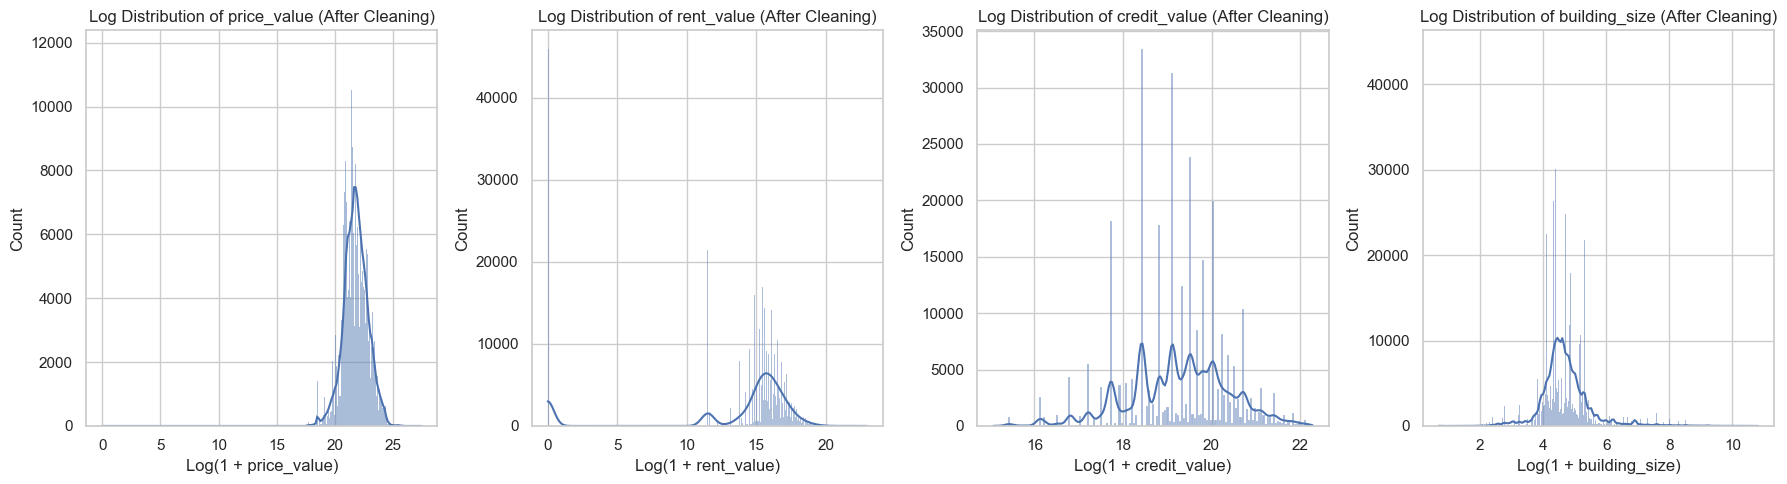

In [55]:

    columns_to_plot = ['price_value', 'rent_value', 'credit_value','building_size']

    plt.figure(figsize=(18, 5))
    for i, col in enumerate(columns_to_plot):
        if col in final_df_surgical.columns:
            plt.subplot(1, len(columns_to_plot), i + 1)
            # استفاده از داده‌های لاگ برای تجسم بهتر توزیع
            sns.histplot(np.log1p(final_df_surgical[col].dropna()), kde=True)
            plt.title(f'Log Distribution of {col} (After Cleaning)')
            plt.xlabel('Log(1 + ' + col + ')')
    plt.tight_layout()
    plt.show()

In [59]:
# نام فایل معمولاً با پسوند .pkl یا .pickle است
file_path = 'cleaned_real_estate_data.pkl'

print(f"ذخیره‌سازی دیتافریم در فایل: {file_path}")
final_df_surgical.to_pickle(file_path)

print("دیتافریم با موفقیت ذخیره شد!")

ذخیره‌سازی دیتافریم در فایل: cleaned_real_estate_data.pkl
دیتافریم با موفقیت ذخیره شد!


---

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
file_path = 'cleaned_real_estate_data.pkl'

# خواندن آبجکت از فایل Pickle
df_loaded = pd.read_pickle(file_path)

print("دیتافریم با موفقیت بارگذاری شد!")
print("\nاطلاعات دیتافریم بارگذاری شده:")
df_loaded.info()

دیتافریم با موفقیت بارگذاری شد!

اطلاعات دیتافریم بارگذاری شده:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833385 entries, 0 to 833384
Data columns (total 54 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   cat2_slug                   833385 non-null  category
 1   cat3_slug                   833385 non-null  category
 2   city_slug                   833385 non-null  category
 3   neighborhood_slug           374202 non-null  category
 4   created_at_month            833385 non-null  object  
 5   user_type                   255827 non-null  category
 6   description                 833385 non-null  object  
 7   title                       833346 non-null  object  
 8   rent_mode                   312636 non-null  category
 9   rent_value                  312636 non-null  float64 
 10  rent_type                   94146 non-null   category
 11  price_mode                  520749 non-null  category

In [7]:
df_loaded.shape

(833385, 54)

---
▶️ **مرحله ۱: انتخاب متغیرهای نهایی برای خوشه‌بندی**
---

*در این قطعه، ما ستون‌هایی را که قرار است مبنای خوشه‌بندی باشند، جدا کردیم و مطمئن شدیم که هیچ داده ناموجودی در آن‌ها باقی نمانده است*

In [7]:
df_for_modeling = df_loaded.copy()

# 1. انتخاب ستون‌های عددی و بولین برای خوشه‌بندی
numerical_features = [
    'price_value', 
    'rent_value', 
    'credit_value', 
    'building_size', 
    'land_size', 
    'floor', 
    'construction_year', 'rooms_count'
]
boolean_features = ['has_elevator', 'has_parking', 'has_warehouse']

features_for_clustering = numerical_features + boolean_features
df_model_features = df_for_modeling[features_for_clustering].copy()

print("--- پردازش ستون‌های بولین ---")
for col in boolean_features:
    # ابتدا مقادیر گمشده (<NA>) را با False پر می‌کنیم. این کار منطقی است.
    df_model_features[col].fillna(False, inplace=True)
    # سپس ستون که فقط شامل True/False است را به 1/0 تبدیل می‌کنیم.
    df_model_features[col] = df_model_features[col].astype(int)

print("نوع داده ستون‌های بولین پس از پردازش:")
print(df_model_features[boolean_features].dtypes)


# --- مرحله ۳ (تغییر کلیدی): پردازش ستون‌های عددی ---
# اکنون که ستون‌های بولین تمیز شده‌اند، مقادیر گمشده باقی‌مانده را که
# مربوط به ستون‌های عددی هستند، با صفر پر می‌کنیم.
print("\n--- پردازش ستون‌های عددی ---")
print("تعداد مقادیر گمشده قبل از پر کردن نهایی:")
print(df_model_features.isnull().sum())

df_model_features.fillna(0, inplace=True)


# --- مرحله ۴: نمایش وضعیت نهایی دیتافریم ---
print("\n--- دیتافریم نهایی آماده برای مقیاس‌بندی ---")
print(f"تعداد رکوردها: {len(df_model_features):,}")
print(f"تعداد ویژگی‌ها: {len(df_model_features.columns)}")

print("\nنمونه‌ای از داده‌ها:")
display(df_model_features.head())

print("\nبررسی نهایی مقادیر ناموجود (باید صفر باشد):")
# .sum() دوم مجموع کل NaNها را نشان می‌دهد که باید 0 باشد.
print(f"مجموع کل مقادیر گمشده: {df_model_features.isnull().sum().sum()}") 

print("\nبررسی نهایی نوع داده تمام ستون‌ها:")
print(df_model_features.dtypes)

--- پردازش ستون‌های بولین ---
نوع داده ستون‌های بولین پس از پردازش:
has_elevator     int32
has_parking      int32
has_warehouse    int32
dtype: object

--- پردازش ستون‌های عددی ---
تعداد مقادیر گمشده قبل از پر کردن نهایی:
price_value          312636
rent_value           520749
credit_value         520749
building_size          1202
land_size            681685
floor                325742
construction_year         0
rooms_count          105282
has_elevator              0
has_parking               0
has_warehouse             0
dtype: int64

--- دیتافریم نهایی آماده برای مقیاس‌بندی ---
تعداد رکوردها: 833,385
تعداد ویژگی‌ها: 11

نمونه‌ای از داده‌ها:


,price_value,rent_value,credit_value,building_size,land_size,floor,construction_year,rooms_count,has_elevator,has_parking,has_warehouse
0,2.750000e+10,0.0,0.0,125.0,0.0,1,1395,2,1,0,1
1,1.200000e+09,0.0,0.0,73.0,0.0,1,1398,2,0,1,1
2,9.000000e+09,0.0,0.0,86.0,0.0,3,1396,1,1,1,1
3,2.000000e+09,0.0,0.0,87.0,0.0,10,1401,2,1,1,1
4,4.700000e+09,0.0,0.0,160.0,0.0,7,1401,3,1,1,1



بررسی نهایی مقادیر ناموجود (باید صفر باشد):
مجموع کل مقادیر گمشده: 0

بررسی نهایی نوع داده تمام ستون‌ها:
price_value          float64
rent_value           float64
credit_value         float64
building_size        float64
land_size            float64
floor                  Int64
construction_year      Int64
rooms_count            Int64
has_elevator           int32
has_parking            int32
has_warehouse          int32
dtype: object


---
▶️ **مرحله 2: استانداردسازی و مقیاس بندی داده ها**
---

* تمام ویژگی‌ها باید “اهمیت” یکسانی در محاسبات فاصله داشته باشند بنابراین از StandardScaler استفاده می‌کنیم. این ابزار هر ستون را طوری تبدیل می‌کند که میانگین آن 
0
 و انحراف معیار آن 
1
شود

* وقتی همه ویژگی‌ها “وزن” یکسانی در محاسبه فاصله داشته باشند، الگوریتم کا-مینز می‌تواند الگوها را بر اساس ترکیبی منصفانه از تمام ویژگی‌ها پیدا کند

In [9]:


# 1. ایجاد یک نمونه از StandardScaler
scaler = StandardScaler()

# 2. اعمال مقیاس‌بندی بر روی داده‌ها
# مهم: ما scaler را روی کل دیتافریم (شامل ستون‌های 0/1) اعمال می‌کنیم.

X_scaled = scaler.fit_transform(df_model_features)

# 3. تبدیل نتیجه به یک دیتافریم پانداز برای مشاهده بهتر (اختیاری ولی مفید)
# نام ستون‌ها از دیتافریم اصلی گرفته می‌شود.
df_scaled = pd.DataFrame(X_scaled, columns=df_model_features.columns)

# نمایش نتایج مقیاس‌بندی
print("--- نتایج پس از مقیاس‌بندی با StandardScaler (شامل ویژگی‌های بولین) ---")
print(f"شکل داده‌های مقیاس‌بندی شده: {X_scaled.shape}")

print("\nنمونه‌ای از داده‌های مقیاس‌بندی شده:")
display(df_scaled.head())

print("\nبررسی میانگین و انحراف معیار ستون‌ها (باید نزدیک به ۰ و ۱ باشند):")
# به دلیل خطاهای محاسباتی ممیز شناور، مقادیر دقیقاً صفر و یک نخواهند بود.
# loc[['mean', 'std']] یک راه عالی برای نمایش فقط این دو ردیف است.
display(df_scaled.describe().loc[['mean', 'std']])


--- نتایج پس از مقیاس‌بندی با StandardScaler (شامل ویژگی‌های بولین) ---
شکل داده‌های مقیاس‌بندی شده: (833385, 11)

نمونه‌ای از داده‌های مقیاس‌بندی شده:


,price_value,rent_value,credit_value,building_size,land_size,floor,construction_year,rooms_count,has_elevator,has_parking,has_warehouse
0,4.136804,-0.092706,-0.412817,-0.087075,-0.387692,-0.298135,0.215652,0.333183,1.198490,-1.234043,0.753594
1,-0.319786,-0.092706,-0.412817,-0.142670,-0.387692,-0.298135,0.603119,0.333183,-0.834383,0.810344,0.753594
2,1.001940,-0.092706,-0.412817,-0.128771,-0.387692,0.635894,0.344808,-0.584443,1.198490,0.810344,0.753594
3,-0.184224,-0.092706,-0.412817,-0.127702,-0.387692,3.904995,0.990585,0.333183,1.198490,0.810344,0.753594
4,0.273296,-0.092706,-0.412817,-0.049655,-0.387692,2.503951,0.990585,1.250810,1.198490,0.810344,0.753594



بررسی میانگین و انحراف معیار ستون‌ها (باید نزدیک به ۰ و ۱ باشند):


,price_value,rent_value,credit_value,building_size,land_size,floor,construction_year,rooms_count,has_elevator,has_parking,has_warehouse
mean,6.438823e-17,-4.965533e-17,2.965678e-16,-2.455483e-18,-1.609706e-16,-3.055713e-17,1.284791e-14,-9.821934e-18,1.986213e-16,1.582423e-16,1.527856e-16
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00


---
▶️ **مرحله 3: پیدا کردن تعداد بهینه خوشه‌ها**
---
**با روش Ellbow**
---
* با توجه به نمودار به دنبال نقطه‌ای میگردیم که شیب نمودار به شدت تغییر می‌کند (مانند یک آرنج). این نقطه، بهترین توازن بین تعداد خوشه‌ها و فشردگی درون خوشه‌ها را نشان می‌دهد.

محاسبه اینرسی برای مقادیر مختلف K (روش Elbow)...
K = 1, Inertia = 9167235.00
K = 2, Inertia = 7318333.39
K = 3, Inertia = 6207221.74
K = 4, Inertia = 5722827.09
K = 5, Inertia = 5225425.05
K = 6, Inertia = 5073001.78
K = 7, Inertia = 4858700.02
K = 8, Inertia = 3784254.61
K = 9, Inertia = 3605880.23
K = 10, Inertia = 3412250.93


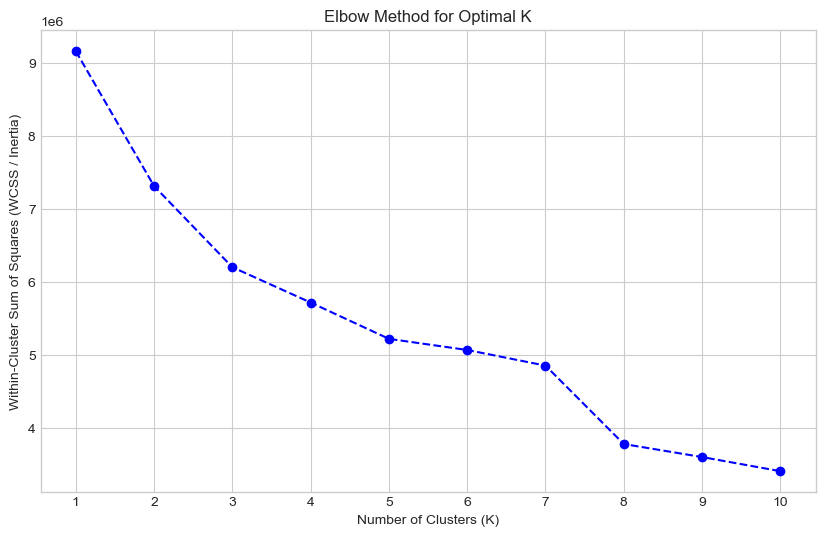

In [11]:

wcss = []  # لیست برای ذخیره مقادیر اینرسی (WCSS)
k_range = range(1, 11)  # تست K از 1 تا 10

print("محاسبه اینرسی برای مقادیر مختلف K (روش Elbow)...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_scaled)
    
    # 2. استخراج و ذخیره اینرسی
    wcss.append(kmeans.inertia_)
    print(f"K = {k}, Inertia = {kmeans.inertia_:.2f}")

# 3. ترسیم نمودار Elbow
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(k_range, wcss, marker='o', linestyle='--', color='b')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS / Inertia)')
ax.set_title('Elbow Method for Optimal K')
ax.set_xticks(k_range)
ax.grid(True)


plt.show()

---
▶️ **مرحله 4: تعریف تابع برای اجرای کلاسترینگ با تعداد خوشه های مدنظر**
---




    این تابع الگوریتم K-Means را برای یک K مشخص اجرا کرده و نتایج را تحلیل می‌کند.

    Args:
        k (int): تعداد خوشه‌ها.
        X_scaled_data (np.array): داده‌های عددی مقیاس‌بندی شده برای مدل‌سازی.
        df_original (pd.DataFrame): دیتافریم اصلی برای تحلیل ویژگی‌های دسته‌ای.
        df_features (pd.DataFrame): دیتافریم شامل ویژگی‌های عددی استفاده شده در مدل.


In [13]:
# تنظیمات نمایش بهتر برای دیتافریم پانداز
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

def run_and_analyze_kmeans(data_scaled, data_original, k):
    """
    مدل K-Means را با مقدار K مشخص اجرا کرده و نتایج را تحلیل می‌کند.

    Args:
        data_scaled (np.array): داده‌های مقیاس‌بندی شده برای آموزش مدل.
        data_original (pd.DataFrame): داده‌های اصلی (قبل از مقیاس‌بندی) برای تفسیر نتایج.
        k (int): تعداد خوشه‌ها.

    Returns:
        tuple: (خلاصه تحلیل خوشه‌ها (DataFrame), برچسب‌های هر داده (Series))
    """
    print(f"\n{'='*25} تحلیل برای K = {k} {'='*25}")
    
    # 1. ساخت و آموزش مدل
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = kmeans.fit_predict(data_scaled)
    
    # 2. افزودن برچسب خوشه‌ها به داده‌های اصلی برای تحلیل
    df_analysis = data_original.copy()
    df_analysis['cluster'] = labels
    
    # 3. محاسبه میانگین ویژگی‌ها در هر خوشه برای تفسیر
    # این به ما "پروفایل" یا "شخصیت" هر خوشه را می‌دهد.
    cluster_means = df_analysis.groupby('cluster').mean()
    
    # 4. محاسبه تعداد اعضا در هر خوشه
    cluster_size = df_analysis.groupby('cluster').size().to_frame('count')
    
    # 5. ترکیب نتایج در یک دیتافریم جامع و مرتب‌سازی بر اساس اندازه خوشه
    analysis_summary = pd.concat([cluster_size, cluster_means], axis=1)
    analysis_summary.sort_values(by='count', ascending=False, inplace=True)
    
    print(f"خلاصه خوشه‌ها (میانگین ویژگی‌ها در هر خوشه):")
    display(analysis_summary)
    
    return analysis_summary, pd.Series(labels, name=f'labels_k{k}')

# --- اجرای تحلیل مقایسه‌ای ---

# فرض می‌کنیم X_scaled (داده‌های مقیاس‌بندی شده) و 
# df_model_features (داده‌های اصلی قبل از مقیاس‌بندی) از مراحل قبل آماده هستند.

# اجرای تحلیل برای K=5
summary_k5, labels_k5 = run_and_analyze_kmeans(X_scaled, df_model_features, k=5)

# اجرای تحلیل برای K=6
summary_k6, labels_k6 = run_and_analyze_kmeans(X_scaled, df_model_features, k=6)

# اجرای تحلیل برای K=7
summary_k7, labels_k7 = run_and_analyze_kmeans(X_scaled, df_model_features, k=7)

# اجرای تحلیل برای K=8
summary_k8, labels_k8 = run_and_analyze_kmeans(X_scaled, df_model_features, k=8)

# --- مقایسه توزیع خوشه‌ها (ماتریس تقاطع) ---
# این ماتریس نشان می‌دهد که اعضای خوشه‌های K=5 چگونه در خوشه‌های K=6 توزیع شده‌اند.
# این بهترین راه برای دیدن این است که کدام خوشه "شکسته" شده است.
print(f"\n{'='*25} ماتریس تقاطع K=5 در مقابل K=6 {'='*25}")
print("ستون‌ها: خوشه‌های K=6 | ردیف‌ها: خوشه‌های K=5")

crosstab_matrix = pd.crosstab(labels_k5, labels_k6)
display(crosstab_matrix)

print(f"\n{'='*25} ماتریس تقاطع K=7 در مقابل K=8 {'='*25}")
print("ستون‌ها: خوشه‌های K=8 | ردیف‌ها: خوشه‌های K=7")

crosstab_matrix = pd.crosstab(labels_k7, labels_k8)
display(crosstab_matrix)


========================= تحلیل برای K = 5 =========================
خلاصه خوشه‌ها (میانگین ویژگی‌ها در هر خوشه):


,count,price_value,rent_value,credit_value,building_size,land_size,floor,construction_year,rooms_count,has_elevator,has_parking,has_warehouse
cluster,,,,,,,,,,,,
1,297697,"4,318,474,078.66","3,452,028.91","111,731,797.64",105.26,0.00,3.19,"1,397.02",2.10,1.00,0.90,0.87
4,227897,"2,613,892,358.88","5,293,098.75","60,475,723.29",455.88,7.83,0.26,"1,390.85",0.44,0.03,0.01,0.00
2,179657,"1,492,773,509.20","3,249,851.64","119,568,066.96",89.17,28.97,1.30,"1,388.90",1.69,0.02,0.62,0.88
0,91136,"4,644,971,682.29","2,103,632.90","56,791,938.38",166.50,285.29,0.00,"1,394.87",2.65,0.00,0.93,0.88
3,36998,0.00,"38,741,883.84","1,521,189,138.43",152.10,2.74,3.31,"1,396.63",2.56,0.92,0.96,0.90



========================= تحلیل برای K = 6 =========================
خلاصه خوشه‌ها (میانگین ویژگی‌ها در هر خوشه):


,count,price_value,rent_value,credit_value,building_size,land_size,floor,construction_year,rooms_count,has_elevator,has_parking,has_warehouse
cluster,,,,,,,,,,,,
1,290351,"4,398,058,821.50","3,413,567.44","110,692,745.42",105.94,0.00,3.20,"1,397.06",2.11,1.00,0.92,0.89
2,163412,"1,540,910,819.40","3,098,722.73","118,185,869.43",86.42,29.70,1.31,"1,388.68",1.66,0.02,0.58,0.98
4,153124,"3,601,170,947.09","2,580,170.98","25,074,455.24",625.79,3.51,0.06,"1,388.23",0.14,0.00,0.00,0.00
5,100881,"766,469,517.03","9,462,440.90","134,780,974.14",109.36,19.83,0.89,"1,395.43",1.27,0.14,0.22,0.00
0,88780,"4,677,566,424.16","2,087,073.14","56,282,752.56",165.86,288.32,0.00,"1,394.76",2.66,0.00,0.94,0.90
3,36837,0.00,"38,288,387.40","1,522,832,510.46",151.62,2.73,3.32,"1,396.63",2.57,0.93,0.96,0.91



========================= تحلیل برای K = 7 =========================
خلاصه خوشه‌ها (میانگین ویژگی‌ها در هر خوشه):


...

,count,price_value,rent_value,credit_value,building_size,land_size,floor,construction_year,rooms_count,has_elevator,has_parking,has_warehouse
cluster,,,,,,,,,,,,
1,286941,"3,421,572,306.08","3,652,592.71","118,911,608.87",103.03,0.00,3.18,"1,397.10",2.07,1.00,0.90,0.87
3,223298,"1,826,759,136.43","5,505,297.95","62,807,583.09",322.80,8.33,0.27,"1,390.88",0.45,0.03,0.02,0.00
2,176223,"1,454,736,335.92","3,317,360.55","119,951,390.42",88.88,28.23,1.32,"1,388.85",1.70,0.01,0.61,0.89
0,90460,"3,942,118,533.75","2,238,624.38","58,648,024.74",157.30,283.86,0.00,"1,395.14",2.60,0.00,0.94,0.88
5,35863,0.00,"28,932,272.37","1,544,250,048.78",152.64,2.79,3.33,"1,396.61",2.57,0.93,0.96,0.91
4,18898,"29,460,963,844.13",0.00,0.00,382.44,25.27,2.12,"1,392.28",2.33,0.64,0.72,0.71
6,1647,"8,129,918,000.29",0.00,0.00,"16,882.02",0.00,0.00,"1,390.00",0.00,0.00,0.00,0.00
7,55,0.00,"6,196,137,797.96","219,737,773.76",95.29,0.00,2.13,"1,393.62",1.87,0.38,0.71,0.73



========================= ماتریس تقاطع K=5 در مقابل K=6 =========================
ستون‌ها: خوشه‌های K=6 | ردیف‌ها: خوشه‌های K=5


labels_k6,0,1,2,3,4,5
labels_k5,,,,,,
0,88480,3,293,0,53,2307
1,0,290166,1118,26,12,6375
2,299,150,161698,26,647,16837
3,1,31,8,36785,0,173
4,0,1,295,0,152412,75189



========================= ماتریس تقاطع K=7 در مقابل K=8 =========================
ستون‌ها: خوشه‌های K=8 | ردیف‌ها: خوشه‌های K=7


labels_k8,0,1,2,3,4,5,6,7
labels_k7,,,,,,,,
0,80622,0,0,0,1684,4,0,0
1,3,224644,27,0,11936,0,0,0
2,7848,424,108025,4144,354,98,0,0
3,12,516,12,52,0,35233,0,55
4,1929,1014,67771,4730,267,41,0,0
5,8,60343,387,7993,156,487,0,0
6,38,0,1,206379,4501,0,1647,0


In [15]:

final_k = 8
kmeans_final = KMeans(n_clusters=final_k, n_init='auto', random_state=42)
final_labels_k8 = kmeans_final.fit_predict(X_scaled)

print(f"خوشه‌بندی با K={final_k} انجام شد.")




خوشه‌بندی با K=8 انجام شد.


PCA با موفقیت اجرا شد و داده‌ها به ۲ بعد کاهش یافتند.
شکل داده‌های پس از PCA: (833385, 2)
واریانس توضیح داده شده توسط مؤلفه اول: 28.05%
واریانس توضیح داده شده توسط مؤلفه دوم: 14.66%
مجموع واریانس توضیح داده شده توسط دو مؤلفه: 42.71%

دیتافریم نهایی برای مصورسازی:


,PCA_1,PCA_2,cluster
0,0.61,0.54,4
1,0.42,0.50,2
2,1.30,-0.43,1
3,2.97,-1.64,1
4,2.86,-0.75,1


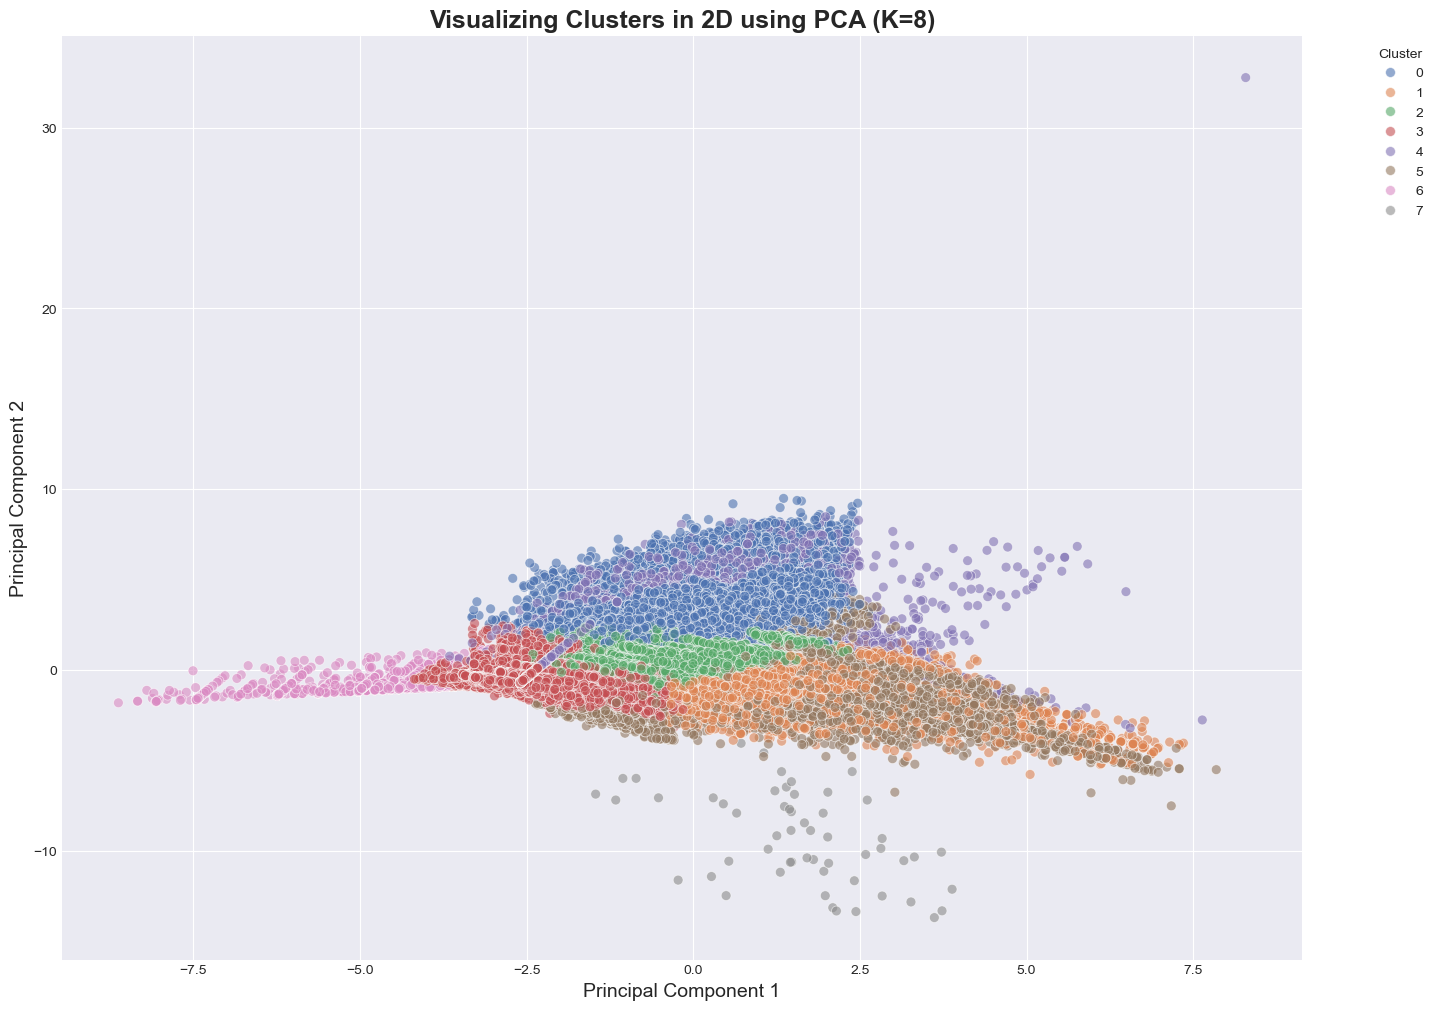

In [27]:
# -----------------------------------------------------------------------------
# مرحله ۲: اجرای PCA برای کاهش ابعاد به ۲ مؤلفه
# -----------------------------------------------------------------------------
# ما PCA را روی داده‌های مقیاس‌بندی شده اجرا می‌کنیم
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("PCA با موفقیت اجرا شد و داده‌ها به ۲ بعد کاهش یافتند.")
print(f"شکل داده‌های پس از PCA: {X_pca.shape}")

# توضیح واریانس توسط هر مؤلفه
explained_variance = pca.explained_variance_ratio_
print(f"واریانس توضیح داده شده توسط مؤلفه اول: {explained_variance[0]:.2%}")
print(f"واریانس توضیح داده شده توسط مؤلفه دوم: {explained_variance[1]:.2%}")
print(f"مجموع واریانس توضیح داده شده توسط دو مؤلفه: {np.sum(explained_variance):.2%}")

#-----------------------------------------------------------------------------
# مرحله ۳: ایجاد دیتافریم برای مصورسازی
# -----------------------------------------------------------------------------
df_pca = pd.DataFrame(data=X_pca, columns=['PCA_1', 'PCA_2'])
df_pca['cluster'] = final_labels_k8

print("\nدیتافریم نهایی برای مصورسازی:")
display(df_pca.head())

# -----------------------------------------------------------------------------
# مرحله ۴: مصورسازی خوشه‌ها در فضای PCA
# -----------------------------------------------------------------------------
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(16, 12))

# استفاده از یک پالت رنگی مناسب برای ۸ خوشه
palette = sns.color_palette("deep", n_colors=final_k)

# رسم نمودار پراکندگی
scatter = sns.scatterplot(
    x='PCA_1',
    y='PCA_2',
    hue='cluster',
    data=df_pca,
    palette=palette,
    alpha=0.6,
    s=50, # اندازه نقاط
    legend='full'
)

plt.title('Visualizing Clusters in 2D using PCA (K=8)', fontsize=18, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

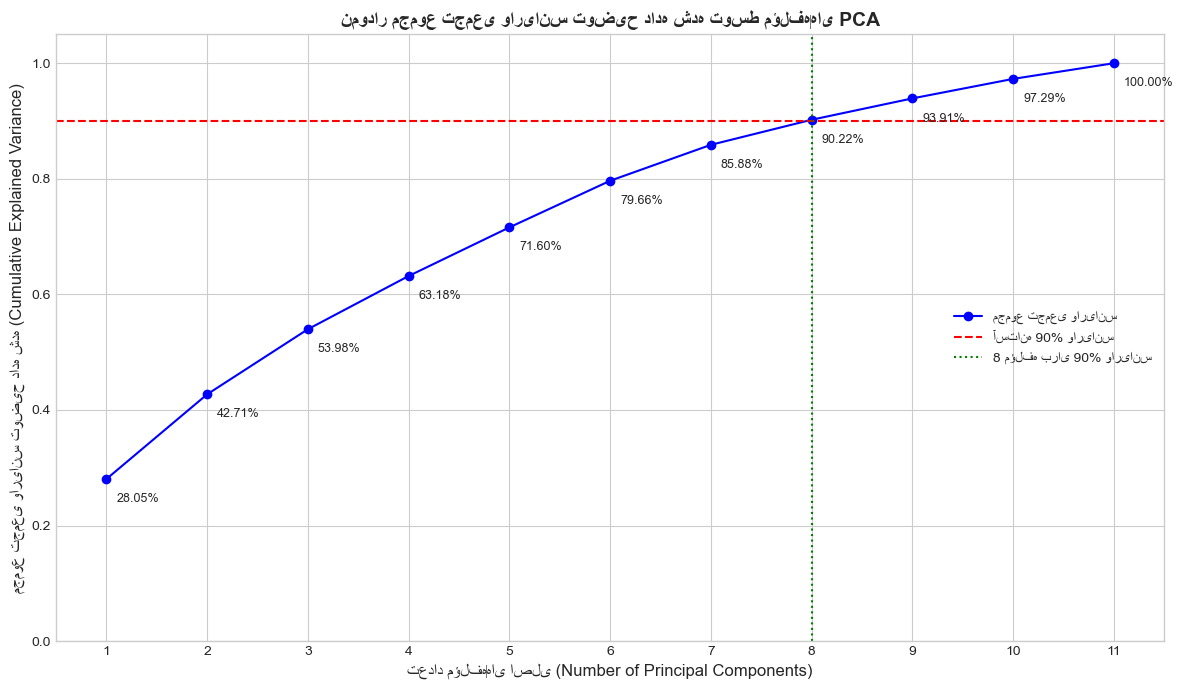

تعداد مؤلفه‌های مورد نیاز برای پوشش 90% از واریانس: 8 عدد


In [17]:
# مرحله ۱: اجرای PCA بدون محدودیت تعداد مؤلفه‌ها
# با تنظیم نکردن n_components، الگوریتم تمام مؤلفه‌های ممکن را محاسبه می‌کند.
# تعداد مؤلفه‌ها برابر با تعداد ویژگی‌ها خواهد بود (۱۱ در این پروژه).
# -----------------------------------------------------------------------------
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# -----------------------------------------------------------------------------
# مرحله ۲: محاسبه واریانس تجمعی
# pca_full.explained_variance_ratio_ آرایه‌ای حاوی درصد واریانس توضیح داده شده
# توسط هر مؤلفه است. np.cumsum آن را به صورت تجمعی محاسبه می‌کند.
# -----------------------------------------------------------------------------
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# -----------------------------------------------------------------------------
# مرحله ۳: ترسیم نمودار مجموع تجمعی واریانس
# -----------------------------------------------------------------------------
# ایجاد یک استایل زیباتر برای نمودار
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# ترسیم خط واریانس تجمعی
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='b', label='مجموع تجمعی واریانس')

# افزودن یک خط افقی به عنوان آستانه (مثلاً ۹۰٪) برای تصمیم‌گیری
# این خط به ما کمک می‌کند تا ببینیم برای رسیدن به ۹۰٪ واریانس به چند مؤلفه نیاز داریم
threshold = 0.90
ax.axhline(y=threshold, color='r', linestyle='--', label=f'آستانه {threshold:.0%} واریانس')

# پیدا کردن تعداد مؤلفه‌های لازم برای رسیدن به آستانه
# np.argmax(cumulative_variance >= threshold) اولین ایندکسی را که شرط برقرار است برمی‌گرداند
# به علاوه ۱ می‌کنیم چون ایندکس از صفر شروع می‌شود
n_components_for_threshold = np.argmax(cumulative_variance >= threshold) + 1
ax.axvline(x=n_components_for_threshold, color='g', linestyle=':', 
           label=f'{n_components_for_threshold} مؤلفه برای {threshold:.0%} واریانس')


# تنظیمات ظاهری نمودار
ax.set_xlabel('تعداد مؤلفه‌های اصلی (Number of Principal Components)', fontsize=12)
ax.set_ylabel('مجموع تجمعی واریانس توضیح داده شده (Cumulative Explained Variance)', fontsize=12)
ax.set_title('نمودار مجموع تجمعی واریانس توضیح داده شده توسط مؤلفه‌های PCA', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)  
ax.set_xticks(np.arange(1, len(cumulative_variance) + 1, 1)) # نمایش اعداد صحیح برای محور x

# افزودن لیبل مقادیر روی نقاط
for i, txt in enumerate(cumulative_variance):
    ax.annotate(f'{txt:.2%}', (i + 1.1, txt - 0.04), fontsize=9)

ax.legend(loc='center right')
plt.tight_layout()
plt.show()

print(f"تعداد مؤلفه‌های مورد نیاز برای پوشش {threshold:.0%} از واریانس: {n_components_for_threshold} عدد")

کاهش ابعاد با PCA به 8 مؤلفه انجام شد.
شکل داده‌های جدید (کاهش‌یافته): (833385, 8)
مجموع واریانس توضیح داده شده توسط 8 مؤلفه: 90.22%


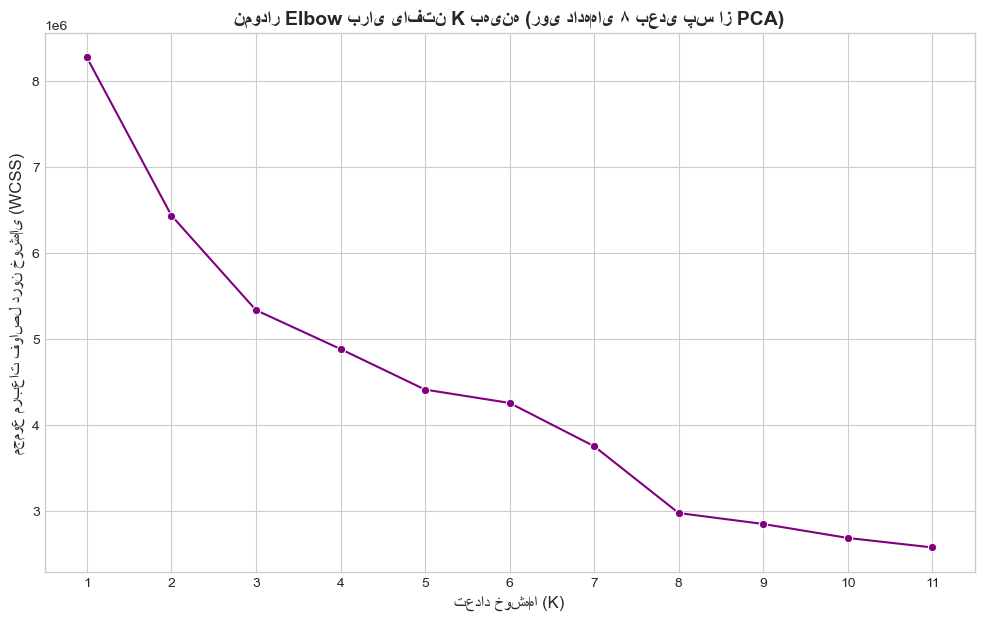

In [29]:
# بر اساس نمودار، ۸ مؤلفه بیش از ۹۰٪ واریانس را پوشش می‌دهند.
n_components_optimal = 8

# نمونه‌سازی و اجرای PCA با تعداد بهینه مؤلفه‌ها
pca_reduced = PCA(n_components=n_components_optimal, random_state=42)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

print(f"کاهش ابعاد با PCA به {n_components_optimal} مؤلفه انجام شد.")
print(f"شکل داده‌های جدید (کاهش‌یافته): {X_pca_reduced.shape}")
print(f"مجموع واریانس توضیح داده شده توسط {n_components_optimal} مؤلفه: {np.sum(pca_reduced.explained_variance_ratio_):.2%}")

# -----------------------------------------------------------------------------
# مرحله ۲: اجرای مجدد متد Elbow برای یافتن K بهینه روی داده‌های کاهش‌یافته
# -----------------------------------------------------------------------------
# هدف: بررسی اینکه آیا ساختار خوشه‌ها در فضای ۸ بعدی واضح‌تر است یا خیر.
wcss_pca = []
k_range = range(1, 12)  # بررسی K از ۱ تا ۱۱

for i in k_range:
    # الگوریتم K-Means روی داده‌های ۸ بعدی اجرا می‌شود
    kmeans_pca_elbow = KMeans(n_clusters=i, init='k-means++', n_init='auto', random_state=42)
    kmeans_pca_elbow.fit(X_pca_reduced)
    wcss_pca.append(kmeans_pca_elbow.inertia_)

# -----------------------------------------------------------------------------
# مرحله ۳: رسم نمودار Elbow برای داده‌های کاهش‌یافته با PCA
# -----------------------------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 7))
sns.lineplot(x=k_range, y=wcss_pca, marker='o', color='purple')
plt.title('نمودار Elbow برای یافتن K بهینه (روی داده‌های ۸ بعدی پس از PCA)', fontsize=14, fontweight='bold')
plt.xlabel('تعداد خوشه‌ها (K)', fontsize=12)
plt.ylabel('مجموع مربعات فواصل درون خوشه‌ای (WCSS)', fontsize=12)
plt.xticks(k_range)
plt.grid(True)
plt.show()

# -----------------------------------------------------------------------------
#

In [33]:
# مرحله ۴: تحلیل نمودار Elbow جدید و اجرای خوشه‌بندی نهایی
# -----------------------------------------------------------------------------
# ***  به نمودار بالا نگاه کرده و K بهینه جدید را انتخاب کردیم ***

optimal_k_pca = 8 

# اجرای K-Means نهایی روی داده‌های کاهش‌یافته با K بهینه جدید
kmeans_final_pca = KMeans(n_clusters=optimal_k_pca, init='k-means++', n_init='auto', random_state=42)
final_labels_pca = kmeans_final_pca.fit_predict(X_pca_reduced)

# -----------------------------------------------------------------------------
# مرحله ۵: افزودن نتایج به دیتافریم اصلی برای مقایسه
# -----------------------------------------------------------------------------
# ایجاد یک کپی از دیتافریم اصلی برای افزودن ستون‌های خوشه
df_analysis = df_model_features.copy()

# افزودن برچسب‌های خوشه‌بندی اصلی (روی داده‌های ۱۱ بعدی)
df_analysis['cluster_original_k8'] = final_labels_k8

# افزودن برچسب‌های خوشه‌بندی جدید (روی داده‌های ۸ بعدی)
df_analysis['cluster_pca_k' + str(optimal_k_pca)] = final_labels_pca

print(f"\nنتایج خوشه‌بندی به دیتافریم اضافه شد. پیش‌نمایش:")
print(df_analysis[['cluster_original_k8', 'cluster_pca_k' + str(optimal_k_pca)]].head())

# برای تحلیل مقایسه‌ای می‌توانید از ماتریس تقاطع استفاده کنید:
crosstab_pca_vs_original = pd.crosstab(df_analysis['cluster_original_k8'], df_analysis['cluster_pca_k' + str(optimal_k_pca)])
print("\nماتریس تقاطع بین خوشه‌بندی اصلی و خوشه‌بندی روی داده‌های PCA:")
print(crosstab_pca_vs_original)


نتایج خوشه‌بندی به دیتافریم اضافه شد. پیش‌نمایش:
   cluster_original_k8  cluster_pca_k8
0                    4               6
1                    2               2
2                    1               4
3                    1               4
4                    1               4

ماتریس تقاطع بین خوشه‌بندی اصلی و خوشه‌بندی روی داده‌های PCA:
cluster_pca_k8           0      1       2       3       4     5      6   7
cluster_original_k8                                                       
0                    87027      9    3303      19       0     0    102   0
1                        1   1316    8887     947  275335     0    455   0
2                     1769    225  167761     551    5877     0     40   0
3                       45     17    4079  219145       0     0     12   0
4                        4      0      12     141     212     1  18528   0
5                        4  35454      25      15     365     0      0   0
6                        0      0       0       0    

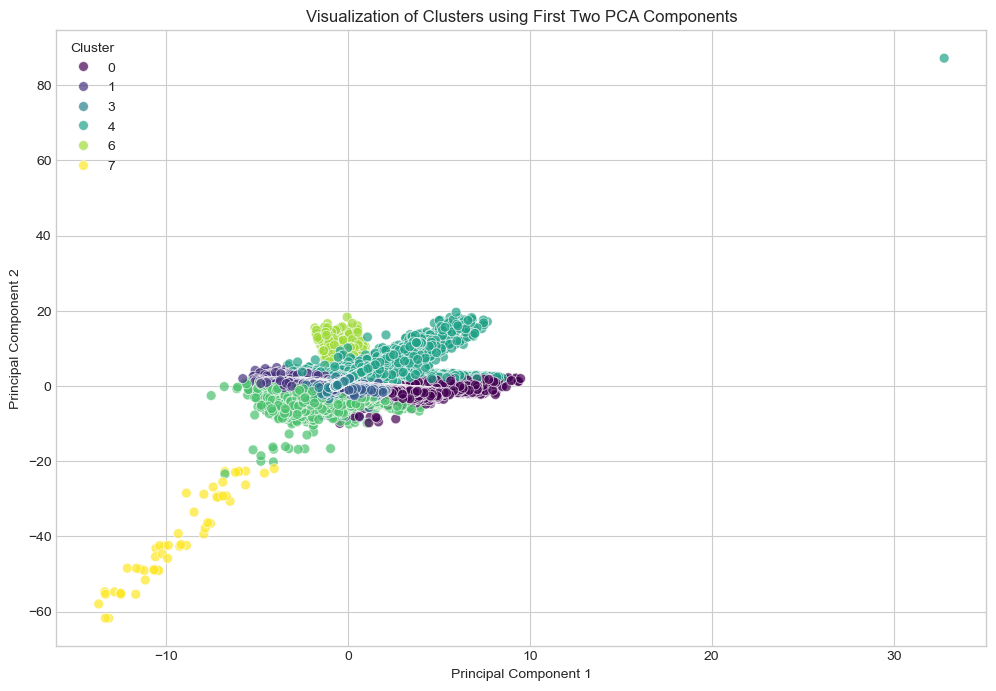

In [35]:
# استفاده از دو مولفه اصلی اول برای مصورسازی
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_pca_reduced[:,1],  # مولفه اول PCA
    y=X_pca_reduced[:, 2],  # مولفه دوم PCA
    hue=df_analysis['cluster_original_k8'], # رنگ بر اساس خوشه‌بندی روی داده‌های کامل
    palette='viridis',
    alpha=0.7,
    s=50
)
plt.title('Visualization of Clusters using First Two PCA Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

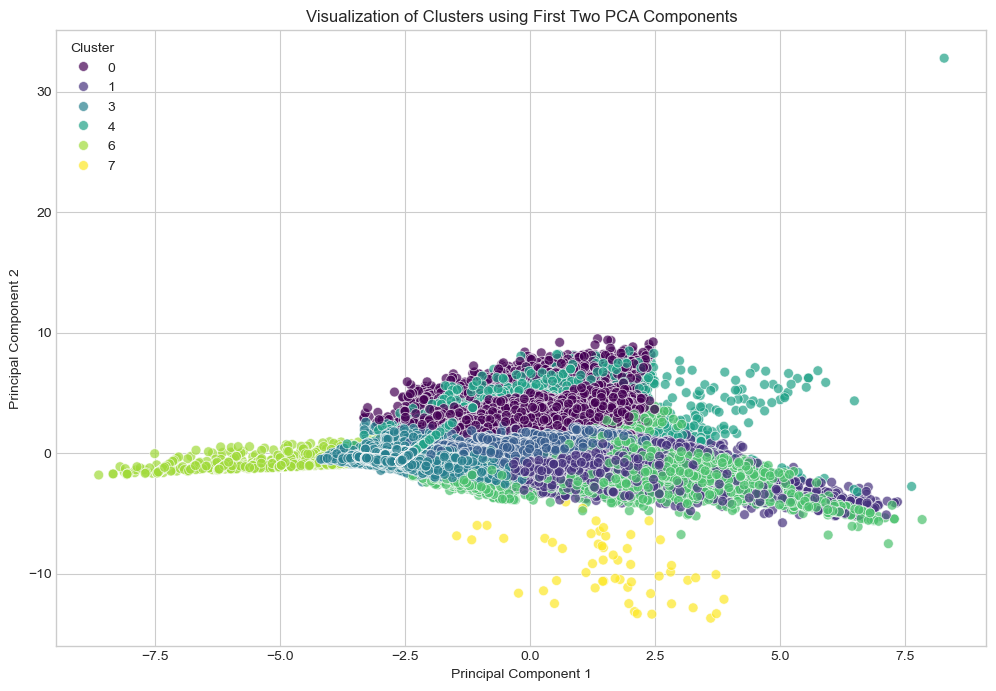

In [49]:
# استفاده از دو مولفه اصلی اول برای مصورسازی
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_pca_reduced[:,0],  # مولفه اول PCA
    y=X_pca_reduced[:,1],  # مولفه دوم PCA
    hue=df_analysis['cluster_original_k8'], # رنگ بر اساس خوشه‌بندی روی داده‌های کامل
    palette='viridis',
    alpha=0.7,
    s=50
)
plt.title('Visualization of Clusters using First Two PCA Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()